In [17]:
from lsst.daf.butler import Butler
from lsst.pipe.tasks.calibrate import CalibrateTask
from lsst.pipe.tasks.characterizeImage import CharacterizeImageTask
from lsst.ip.isr import IsrTask
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import inspect
import lsst.meas.algorithms
from lsst.pipe.tasks.calibrateImage import CalibrateImageTask, CalibrateImageConfig
from lsst.drp.tasks.single_frame_detect_and_measure import SingleFrameDetectAndMeasureTask, SingleFrameDetectAndMeasureConfig
from lsst.ap.association.utils import getRegion
from lsst.ip.isr import IsrTaskLSST

def source_detect(exposure, input_background, threshold = 5.0, release_id=0):
    cfg = SingleFrameDetectAndMeasureConfig()

    cfg.connections.exposure = "preliminary_visit_image"
    cfg.connections.input_background = "preliminary_visit_image_background"
    cfg.connections.sources = "single_visit_star_reprocessed_unstandardized"
    cfg.connections.sources_footprints = "single_visit_star_reprocessed_footprints"
    cfg.connections.background = "preliminary_visit_image_reprocessed_background"

    cfg.id_generator.release_id = release_id

    cfg.detection.thresholdValue = threshold
    cfg.detection.includeThresholdMultiplier = 1.0
    cfg.detection.reEstimateBackground = True
    cfg.detection.doTempLocalBackground = True

    cfg.deblend.maxFootprintArea = -1

    task = SingleFrameDetectAndMeasureTask(config=cfg)
    result = task.run(exposure=exposure, input_background=input_background)
    return result.sources_footprints

def one_ref_object_count(butler, ref, threshold):
    calexp = butler.get("preliminary_visit_image", dataId=ref.dataId)
    background = butler.get("preliminary_visit_image_background", dataId=ref.dataId)
    src = source_detect (calexp, background, threshold)
    return src

def footprints_to_label_mask(src_cat, dimensions, dtype=np.uint16):
    """
    Build integer label mask from source footprints.
    0 = background, (idx+1) = source idx in src_cat.
    """
    H, W = int(dimensions.y), int(dimensions.x)
    lab = np.zeros((H, W), dtype=dtype)

    for sid in range(len(src_cat)):
        fp = src_cat[sid].getFootprint()
        label = sid + 1  # 1..N

        # Fill footprint pixels using spans (fast, no per-pixel loops)
        for span in fp.spans:
            y = span.getY()
            if y < 0 or y >= H:
                continue
            x0 = max(span.getX0(), 0)
            x1 = min(span.getX1(), W - 1)
            if x0 <= x1:
                lab[y, x0:x1+1] = label  # overwrite is fine for ignore-mask use
    return lab

repo = "dp2_prep"
collections = "LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2"

butler = Butler(repo, collections=collections)

WHERE="instrument='LSSTCam' AND day_obs>=20250801 AND day_obs<=20250921 AND band in ('u','g','r','i','z','y') "

refs = list(set(
    butler.registry.queryDatasets(
        "preliminary_visit_image",
        instrument="LSSTCam",
        findFirst=True,
        where=WHERE
    )
))

cat5 = one_ref_object_count(butler, refs[0], 5.0)
cat4 = one_ref_object_count(butler, refs[0], 4.0)
cat3 = one_ref_object_count(butler, refs[0], 3.0)

In [20]:
dims = butler.get("preliminary_visit_image.dimensions", dataId=refs[0].dataId)
mask5 = footprints_to_label_mask(cat5, dims)
mask4 = footprints_to_label_mask(cat4, dims)
mask3 = footprints_to_label_mask(cat3, dims)

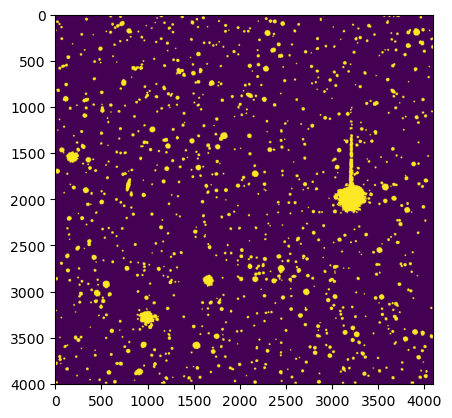

In [24]:
plt.imshow(mask5>0)

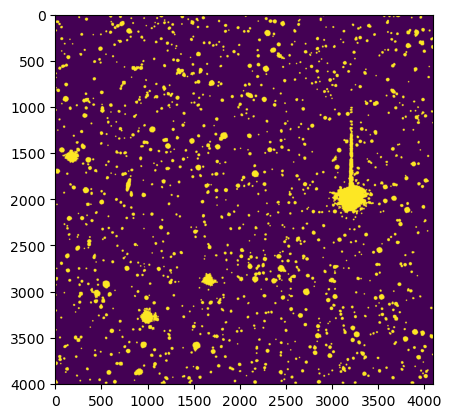

In [25]:
plt.imshow(mask4>0)

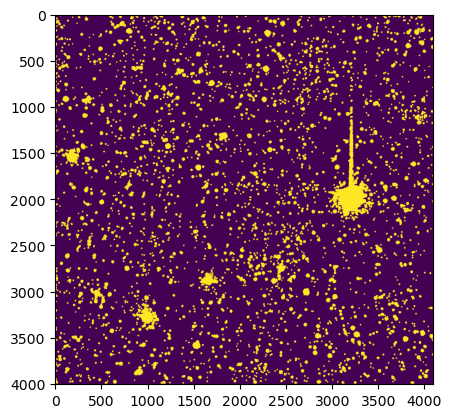

In [26]:
plt.imshow(mask3>0)

In [23]:
(mask5>0).sum(), (mask4>0).sum(), (mask3>0).sum()

(np.int64(997783), np.int64(1199387), np.int64(1878799))

Using 3 refs
{'ref_idx': 0, 'visit': 2025080600341, 'detector': 1, 'band': 'i', 'day_obs': 20250806}
{'ref_idx': 1, 'visit': 2025080600342, 'detector': 1, 'band': 'i', 'day_obs': 20250806}
{'ref_idx': 2, 'visit': 2025080600343, 'detector': 1, 'band': 'i', 'day_obs': 20250806}



=== Raw detection counts ===


,ref_idx,visit,detector,band,day_obs,config_tag,threshold,polarity,count,count_outside_bright_mask,area_pix,psf_sigma_pix,gaussian_pred_count
0,0,2025080600341,1,i,20250806,default,5.0,positive,1353,656,16288000,3.017185,1.058408
1,0,2025080600341,1,i,20250806,default,5.0,negative,147,147,16288000,3.017185,1.058408
2,0,2025080600341,1,i,20250806,default,4.0,positive,1890,1210,16288000,3.017185,76.219878
3,0,2025080600341,1,i,20250806,default,4.0,negative,977,974,16288000,3.017185,76.219878
4,0,2025080600341,1,i,20250806,default,3.0,positive,3434,2789,16288000,3.017185,1893.041792
5,0,2025080600341,1,i,20250806,default,3.0,negative,3093,3083,16288000,3.017185,1893.041792
6,0,2025080600341,1,i,20250806,noTempLocal,5.0,positive,1353,657,16288000,3.017185,1.058408
7,0,2025080600341,1,i,20250806,noTempLocal,5.0,negative,147,147,16288000,3.017185,1.058408
8,0,2025080600341,1,i,20250806,noTempLocal,4.0,positive,1890,1211,16288000,3.017185,76.219878
9,0,2025080600341,1,i,20250806,noTempLocal,4.0,negative,977,974,16288000,3.017185,76.219878



=== Errors ===


,status
0,no errors recorded


...

,config_tag,threshold,polarity,mean_count_over_gaussian,median_count_over_gaussian
4,default,5.0,negative,163.664182,173.575688
2,default,4.0,negative,13.717734,13.841629
0,default,3.0,negative,1.549219,1.534356
5,default,5.0,positive,1354.292035,1385.725206
3,default,4.0,positive,26.331800,26.487979
1,default,3.0,positive,1.773052,1.778559
10,neither,5.0,negative,163.664182,173.575688
8,neither,4.0,negative,13.717734,13.841629
6,neither,3.0,negative,1.549219,1.534356
11,neither,5.0,positive,1354.292035,1385.725206



=== PSF S/N summary ===


,threshold,isolated,n,median_psf_snr,p16_psf_snr,p84_psf_snr,frac_below_nominal



=== Example PSF S/N rows ===


,ref_idx,visit,detector,band,day_obs,threshold,x,y,psf_flux,psf_flux_err,psf_snr,isolated,below_nominal_threshold


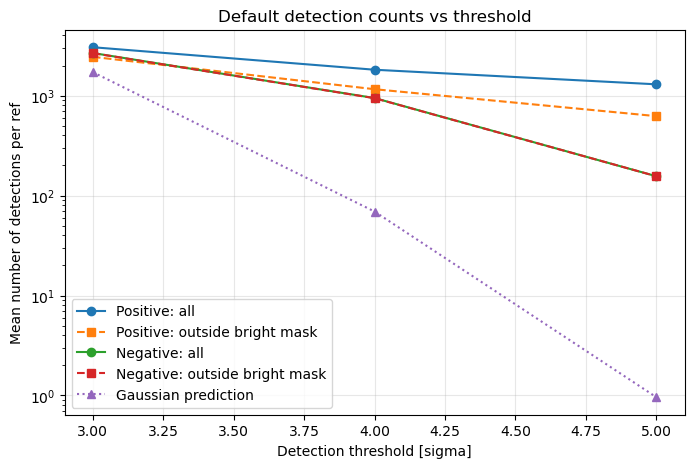

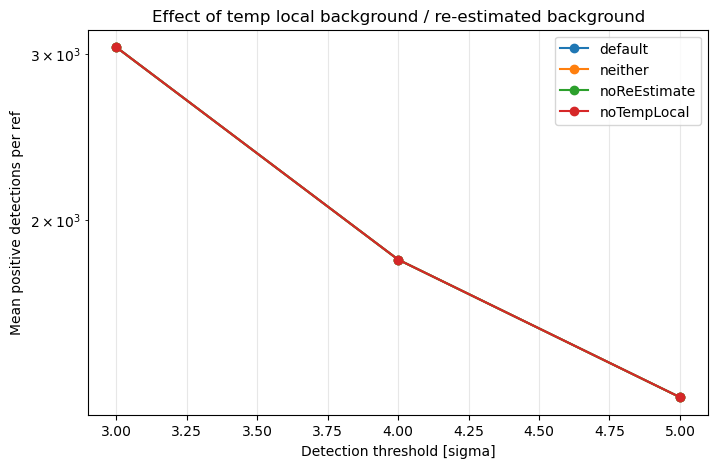

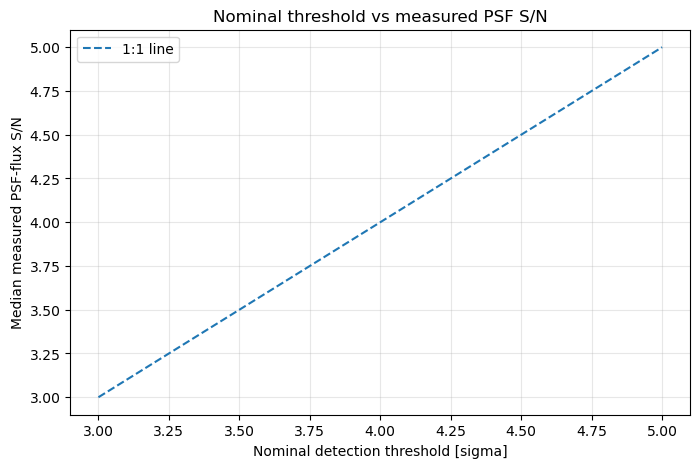


Done. Paste me the Detection summary, Count/Gaussian summary, PSF S/N summary, and any error rows.


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# --- LSST imports ---
from lsst.daf.butler import Butler
try:
    from lsst.meas.algorithms import SourceDetectionTask, SourceDetectionConfig
except Exception:
    from lsst.meas.algorithms.detection import SourceDetectionTask, SourceDetectionConfig

from lsst.drp.tasks.single_frame_detect_and_measure import (
    SingleFrameDetectAndMeasureTask,
    SingleFrameDetectAndMeasureConfig,
)
import lsst.geom as geom


# =============================================================================
# User settings
# =============================================================================
REPO = "dp2_prep"
COLLECTIONS = "LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2"
WHERE = "instrument='LSSTCam' AND day_obs>=20250801 AND day_obs<=20250921 AND band in ('u','g','r','i','z','y')"

MAX_REFS = 3                 # start small; increase after the first successful run
THRESHOLDS = [5.0, 4.0, 3.0]
BRIGHT_MASK_THRESHOLD = 10.0 # bright-source mask used for the "empty-sky / isolated" proxy
BRIGHT_MASK_RADIUS_PX = 15   # radius around bright peaks to exclude
MAKE_PLOTS = True


# =============================================================================
# Small utilities
# =============================================================================
def get_ref_meta(ref, idx=None):
    data_id = ref.dataId
    out = {
        "ref_idx": idx,
        "visit": data_id["visit"] if "visit" in data_id else None,
        "detector": data_id["detector"] if "detector" in data_id else None,
        "band": data_id["band"] if "band" in data_id else None,
        "day_obs": data_id["day_obs"] if "day_obs" in data_id else None,
    }
    return out


def get_schema_names(cat):
    try:
        return list(cat.schema.getNames())
    except Exception:
        try:
            return [item.field.getName() for item in cat.schema]
        except Exception:
            return []


def first_existing(names, candidates=None, contains=None):
    candidates = candidates or []
    for c in candidates:
        if c in names:
            return c
    if contains is not None:
        for n in names:
            if contains in n:
                return n
    return None


def record_get(rec, field, default=np.nan):
    if field is None:
        return default
    try:
        return rec[field]
    except Exception:
        try:
            return rec.get(field)
        except Exception:
            return default


def load_exposure_and_background(butler, ref):
    exp = butler.get("preliminary_visit_image", dataId=ref.dataId)
    bg = butler.get("preliminary_visit_image_background", dataId=ref.dataId)
    return exp, bg


def estimate_psf_sigma_pix(exposure):
    try:
        bbox = exposure.getBBox()
        x = bbox.getMinX() + 0.5 * (bbox.getWidth() - 1)
        y = bbox.getMinY() + 0.5 * (bbox.getHeight() - 1)
        shape = exposure.getPsf().computeShape(geom.Point2D(float(x), float(y)))
        try:
            return float(shape.getDeterminantRadius())
        except Exception:
            ixx = float(shape.getIxx())
            iyy = float(shape.getIyy())
            return float(np.sqrt(0.5 * (ixx + iyy)))
    except Exception:
        return np.nan


def gaussian_false_detections(area_pix, sigma_g_pix, nu):
    # DMTN-006 / Adler 1981-style Gaussian random field approximation
    if not np.isfinite(area_pix) or not np.isfinite(sigma_g_pix) or sigma_g_pix <= 0:
        return np.nan
    coeff = 1.0 / (2.0 ** 2.5 * np.pi ** 1.5)
    return (area_pix / sigma_g_pix ** 2) * coeff * nu * np.exp(-0.5 * nu ** 2)


# =============================================================================
# Detection-only experiment (fast): SourceDetectionTask
# =============================================================================
def make_detection_task(threshold, polarity="positive", do_temp_local_background=True, reestimate_background=True):
    cfg = SourceDetectionConfig()
    cfg.thresholdValue = float(threshold)
    cfg.thresholdPolarity = str(polarity)
    cfg.includeThresholdMultiplier = 1.0
    cfg.reEstimateBackground = bool(reestimate_background)
    cfg.doTempLocalBackground = bool(do_temp_local_background)
    return SourceDetectionTask(config=cfg)


def run_detection_only(butler, ref, threshold, polarity="positive",
                       do_temp_local_background=True, reestimate_background=True):
    exp, bg = load_exposure_and_background(butler, ref)
    task = make_detection_task(
        threshold=threshold,
        polarity=polarity,
        do_temp_local_background=do_temp_local_background,
        reestimate_background=reestimate_background,
    )
    results = task.detectFootprints(
        exposure=exp,
        doSmooth=True,
        sigma=None,
        clearMask=True,
        expId=None,
        background=bg,
    )
    return exp, results


def footprintset_to_list(fp_set):
    if fp_set is None:
        return []
    try:
        return list(fp_set.getFootprints())
    except Exception:
        try:
            return list(fp_set)
        except Exception:
            return []


def peak_xy(peak):
    x = None
    y = None
    for name in ("getIx", "getFx", "getX"):
        if hasattr(peak, name):
            x = getattr(peak, name)()
            break
    for name in ("getIy", "getFy", "getY"):
        if hasattr(peak, name):
            y = getattr(peak, name)()
            break
    if x is None or y is None:
        return None
    return int(round(float(x))), int(round(float(y)))


def best_peak_xy_from_footprint(fp):
    try:
        peaks = list(fp.getPeaks())
    except Exception:
        peaks = []
    if len(peaks) == 0:
        return None

    def _peak_value(p):
        for name in ("getPeakValue", "getValue"):
            if hasattr(p, name):
                try:
                    return float(getattr(p, name)())
                except Exception:
                    pass
        return 0.0

    best = max(peaks, key=_peak_value)
    return peak_xy(best)


def disk_offsets(radius):
    rr = int(radius)
    yy, xx = np.mgrid[-rr:rr + 1, -rr:rr + 1]
    keep = (xx * xx + yy * yy) <= rr * rr
    return yy[keep], xx[keep]


def build_peak_mask(image_shape, footprints, radius_px=15):
    mask = np.zeros(image_shape, dtype=bool)
    dy, dx = disk_offsets(radius_px)
    h, w = image_shape

    for fp in footprints:
        xy = best_peak_xy_from_footprint(fp)
        if xy is None:
            continue
        x0, y0 = xy
        xs = x0 + dx
        ys = y0 + dy
        keep = (xs >= 0) & (xs < w) & (ys >= 0) & (ys < h)
        mask[ys[keep], xs[keep]] = True

    return mask


def count_footprints_outside_mask(footprints, mask):
    h, w = mask.shape
    n = 0
    for fp in footprints:
        xy = best_peak_xy_from_footprint(fp)
        if xy is None:
            continue
        x, y = xy
        if 0 <= x < w and 0 <= y < h and not mask[y, x]:
            n += 1
    return n


# =============================================================================
# Detection + measurement experiment: SingleFrameDetectAndMeasureTask
# =============================================================================
def make_sfdm_task(threshold, polarity="positive", do_temp_local_background=True, reestimate_background=True, release_id=0):
    cfg = SingleFrameDetectAndMeasureConfig()

    cfg.connections.exposure = "preliminary_visit_image"
    cfg.connections.input_background = "preliminary_visit_image_background"
    cfg.connections.sources = "single_visit_star_reprocessed_unstandardized"
    cfg.connections.sources_footprints = "single_visit_star_reprocessed_footprints"
    cfg.connections.background = "preliminary_visit_image_reprocessed_background"

    cfg.id_generator.release_id = int(release_id)

    cfg.detection.thresholdValue = float(threshold)
    cfg.detection.thresholdPolarity = str(polarity)
    cfg.detection.includeThresholdMultiplier = 1.0
    cfg.detection.reEstimateBackground = bool(reestimate_background)
    cfg.detection.doTempLocalBackground = bool(do_temp_local_background)

    cfg.deblend.maxFootprintArea = -1

    return SingleFrameDetectAndMeasureTask(config=cfg)


def run_sfdm(butler, ref, threshold, polarity="positive",
             do_temp_local_background=True, reestimate_background=True, release_id=0):
    exp, bg = load_exposure_and_background(butler, ref)
    task = make_sfdm_task(
        threshold=threshold,
        polarity=polarity,
        do_temp_local_background=do_temp_local_background,
        reestimate_background=reestimate_background,
        release_id=release_id,
    )
    result = task.run(exposure=exp, input_background=bg)
    return exp, result


def extract_source_catalog(result):
    for attr in ("sources", "outputSources", "sourceCat", "sourceCatalog"):
        if hasattr(result, attr):
            cat = getattr(result, attr)
            if cat is not None:
                return cat
    return None


def measurement_rows_from_result(result, threshold, ref_meta, bright_mask=None):
    cat = extract_source_catalog(result)
    if cat is None:
        print("Could not find a measured source catalog in the SFDM result. Available attrs:")
        print([a for a in dir(result) if not a.startswith("_")][:100])
        return pd.DataFrame()

    names = get_schema_names(cat)

    x_field = first_existing(names, [
        "slot_Centroid_x",
        "base_SdssCentroid_x",
        "base_GaussianCentroid_x",
        "x",
    ])
    y_field = first_existing(names, [
        "slot_Centroid_y",
        "base_SdssCentroid_y",
        "base_GaussianCentroid_y",
        "y",
    ])

    flux_field = first_existing(names, [
        "base_PsfFlux_instFlux",
        "slot_PsfFlux_instFlux",
        "slot_PsfFlux_flux",
    ])
    fluxerr_field = first_existing(names, [
        "base_PsfFlux_instFluxErr",
        "slot_PsfFlux_instFluxErr",
        "slot_PsfFlux_fluxErr",
    ])

    rows = []
    h = None if bright_mask is None else bright_mask.shape[0]
    w = None if bright_mask is None else bright_mask.shape[1]

    for rec in cat:
        x = record_get(rec, x_field, np.nan)
        y = record_get(rec, y_field, np.nan)
        flux = record_get(rec, flux_field, np.nan)
        fluxerr = record_get(rec, fluxerr_field, np.nan)

        x = float(x) if np.isfinite(x) else np.nan
        y = float(y) if np.isfinite(y) else np.nan
        flux = float(flux) if np.isfinite(flux) else np.nan
        fluxerr = float(fluxerr) if np.isfinite(fluxerr) else np.nan

        psf_snr = np.nan
        if np.isfinite(flux) and np.isfinite(fluxerr) and fluxerr > 0:
            psf_snr = flux / fluxerr

        isolated = np.nan
        if bright_mask is not None and np.isfinite(x) and np.isfinite(y):
            xi = int(round(x))
            yi = int(round(y))
            if 0 <= xi < w and 0 <= yi < h:
                isolated = (not bright_mask[yi, xi])

        rows.append({
            **ref_meta,
            "threshold": float(threshold),
            "x": x,
            "y": y,
            "psf_flux": flux,
            "psf_flux_err": fluxerr,
            "psf_snr": psf_snr,
            "isolated": isolated,
            "below_nominal_threshold": bool(np.isfinite(psf_snr) and psf_snr < float(threshold)),
        })

    out = pd.DataFrame(rows)
    return out


# =============================================================================
# Main run
# =============================================================================
butler = Butler(REPO, collections=COLLECTIONS)

refs = list(
    butler.registry.queryDatasets(
        "preliminary_visit_image",
        instrument="LSSTCam",
        findFirst=True,
        where=WHERE,
    )
)

if len(refs) == 0:
    raise RuntimeError("No preliminary_visit_image refs found for the query.")

refs = refs[:MAX_REFS]
print(f"Using {len(refs)} refs")
for i, ref in enumerate(refs):
    print(get_ref_meta(ref, i))

count_rows = []
psf_rows = []
errors = []

bg_grid = [
    {"config_tag": "default",      "tempLocalBg": True,  "reEstimateBg": True},
    {"config_tag": "noTempLocal",  "tempLocalBg": False, "reEstimateBg": True},
    {"config_tag": "noReEstimate", "tempLocalBg": True,  "reEstimateBg": False},
    {"config_tag": "neither",      "tempLocalBg": False, "reEstimateBg": False},
]

for idx, ref in enumerate(refs):
    ref_meta = get_ref_meta(ref, idx)

    # One exposure load for PSF sigma / image shape only
    exp0, _ = load_exposure_and_background(butler, ref)
    image_shape = exp0.image.array.shape
    area_pix = int(image_shape[0] * image_shape[1])
    sigma_g_pix = estimate_psf_sigma_pix(exp0)

    # Build a bright-source mask once per ref using a high-threshold positive run
    try:
        _, bright_results = run_detection_only(
            butler, ref,
            threshold=BRIGHT_MASK_THRESHOLD,
            polarity="positive",
            do_temp_local_background=True,
            reestimate_background=True,
        )
        bright_footprints = footprintset_to_list(bright_results.positive)
        bright_mask = build_peak_mask(image_shape, bright_footprints, radius_px=BRIGHT_MASK_RADIUS_PX)
    except Exception as e:
        bright_mask = np.zeros(image_shape, dtype=bool)
        errors.append({**ref_meta, "stage": "bright_mask", "error": repr(e)})

    # Detection-only experiment: thresholds x polarity x background options
    for cfg in bg_grid:
        for threshold in THRESHOLDS:
            try:
                _, res_pos = run_detection_only(
                    butler, ref, threshold=threshold, polarity="positive",
                    do_temp_local_background=cfg["tempLocalBg"],
                    reestimate_background=cfg["reEstimateBg"],
                )
                pos_fps = footprintset_to_list(res_pos.positive)
                count_rows.append({
                    **ref_meta,
                    "config_tag": cfg["config_tag"],
                    "threshold": float(threshold),
                    "polarity": "positive",
                    "count": int(res_pos.numPos),
                    "count_outside_bright_mask": int(count_footprints_outside_mask(pos_fps, bright_mask)),
                    "area_pix": area_pix,
                    "psf_sigma_pix": sigma_g_pix,
                    "gaussian_pred_count": float(gaussian_false_detections(area_pix, sigma_g_pix, float(threshold))),
                })
            except Exception as e:
                errors.append({
                    **ref_meta, "stage": "detection_positive",
                    "config_tag": cfg["config_tag"], "threshold": float(threshold),
                    "error": repr(e)
                })

            try:
                _, res_neg = run_detection_only(
                    butler, ref, threshold=threshold, polarity="negative",
                    do_temp_local_background=cfg["tempLocalBg"],
                    reestimate_background=cfg["reEstimateBg"],
                )
                neg_fps = footprintset_to_list(res_neg.negative)
                count_rows.append({
                    **ref_meta,
                    "config_tag": cfg["config_tag"],
                    "threshold": float(threshold),
                    "polarity": "negative",
                    "count": int(res_neg.numNeg),
                    "count_outside_bright_mask": int(count_footprints_outside_mask(neg_fps, bright_mask)),
                    "area_pix": area_pix,
                    "psf_sigma_pix": sigma_g_pix,
                    "gaussian_pred_count": float(gaussian_false_detections(area_pix, sigma_g_pix, float(threshold))),
                })
            except Exception as e:
                errors.append({
                    **ref_meta, "stage": "detection_negative",
                    "config_tag": cfg["config_tag"], "threshold": float(threshold),
                    "error": repr(e)
                })

    # PSF S/N experiment on default config only, positive detections only
    for release_id, threshold in enumerate(THRESHOLDS):
        try:
            _, sf_result = run_sfdm(
                butler, ref,
                threshold=threshold,
                polarity="positive",
                do_temp_local_background=True,
                reestimate_background=True,
                release_id=release_id,
            )
            df_one = measurement_rows_from_result(
                sf_result,
                threshold=threshold,
                ref_meta=ref_meta,
                bright_mask=bright_mask,
            )
            if len(df_one) > 0:
                psf_rows.append(df_one)
        except Exception as e:
            errors.append({
                **ref_meta, "stage": "psf_snr",
                "threshold": float(threshold), "error": repr(e)
            })

count_df = pd.DataFrame(count_rows)
psf_df = pd.concat(psf_rows, ignore_index=True) if len(psf_rows) > 0 else pd.DataFrame()
err_df = pd.DataFrame(errors)

print("\n=== Raw detection counts ===")
display(count_df.head(20))

print("\n=== Errors ===")
display(err_df if len(err_df) > 0 else pd.DataFrame({"status": ["no errors recorded"]}))


# =============================================================================
# Summaries
# =============================================================================
if len(count_df) > 0:
    det_summary = (
        count_df
        .groupby(["config_tag", "threshold", "polarity"], dropna=False)
        .agg(
            n_refs=("count", "size"),
            mean_count=("count", "mean"),
            median_count=("count", "median"),
            mean_count_outside_bright_mask=("count_outside_bright_mask", "mean"),
            median_count_outside_bright_mask=("count_outside_bright_mask", "median"),
            mean_gaussian_pred=("gaussian_pred_count", "mean"),
            mean_psf_sigma_pix=("psf_sigma_pix", "mean"),
        )
        .reset_index()
        .sort_values(["config_tag", "polarity", "threshold"], ascending=[True, True, False])
    )

    count_df["count_over_gaussian"] = count_df["count"] / count_df["gaussian_pred_count"]

    det_ratio_summary = (
        count_df
        .groupby(["config_tag", "threshold", "polarity"], dropna=False)
        .agg(
            mean_count_over_gaussian=("count_over_gaussian", "mean"),
            median_count_over_gaussian=("count_over_gaussian", "median"),
        )
        .reset_index()
        .sort_values(["config_tag", "polarity", "threshold"], ascending=[True, True, False])
    )

    print("\n=== Detection summary ===")
    display(det_summary)

    print("\n=== Count / Gaussian prediction summary ===")
    display(det_ratio_summary)

if len(psf_df) > 0:
    finite_psf = psf_df[np.isfinite(psf_df["psf_snr"])].copy()

    psf_summary = (
        finite_psf
        .groupby(["threshold", "isolated"], dropna=False)
        .agg(
            n=("psf_snr", "size"),
            median_psf_snr=("psf_snr", "median"),
            p16_psf_snr=("psf_snr", lambda s: float(np.nanpercentile(s, 16))),
            p84_psf_snr=("psf_snr", lambda s: float(np.nanpercentile(s, 84))),
            frac_below_nominal=("below_nominal_threshold", "mean"),
        )
        .reset_index()
        .sort_values(["threshold", "isolated"], ascending=[False, True])
    )

    print("\n=== PSF S/N summary ===")
    display(psf_summary)

    print("\n=== Example PSF S/N rows ===")
    display(finite_psf.head(20))


# =============================================================================
# Plots
# =============================================================================
if MAKE_PLOTS and len(count_df) > 0:
    default_df = count_df[count_df["config_tag"] == "default"].copy()

    fig, ax = plt.subplots(figsize=(8, 5))
    for pol, label in [("positive", "Positive"), ("negative", "Negative")]:
        sub = (
            default_df[default_df["polarity"] == pol]
            .groupby("threshold")
            .agg(
                mean_count=("count", "mean"),
                mean_empty=("count_outside_bright_mask", "mean"),
                mean_gauss=("gaussian_pred_count", "mean"),
            )
            .reset_index()
            .sort_values("threshold")
        )
        ax.plot(sub["threshold"], sub["mean_count"], marker="o", label=f"{label}: all")
        ax.plot(sub["threshold"], sub["mean_empty"], marker="s", linestyle="--", label=f"{label}: outside bright mask")

    gauss = (
        default_df[default_df["polarity"] == "positive"]
        .groupby("threshold")
        .agg(mean_gauss=("gaussian_pred_count", "mean"))
        .reset_index()
        .sort_values("threshold")
    )
    ax.plot(gauss["threshold"], gauss["mean_gauss"], marker="^", linestyle=":", label="Gaussian prediction")

    ax.set_yscale("log")
    ax.set_xlabel("Detection threshold [sigma]")
    ax.set_ylabel("Mean number of detections per ref")
    ax.set_title("Default detection counts vs threshold")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

    bg_plot_df = (
        count_df
        .groupby(["config_tag", "threshold", "polarity"])
        .agg(mean_count=("count", "mean"))
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    for tag in bg_plot_df["config_tag"].unique():
        sub = bg_plot_df[(bg_plot_df["config_tag"] == tag) & (bg_plot_df["polarity"] == "positive")].sort_values("threshold")
        ax.plot(sub["threshold"], sub["mean_count"], marker="o", label=tag)

    ax.set_yscale("log")
    ax.set_xlabel("Detection threshold [sigma]")
    ax.set_ylabel("Mean positive detections per ref")
    ax.set_title("Effect of temp local background / re-estimated background")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

if MAKE_PLOTS and len(psf_df) > 0:
    finite_psf = psf_df[np.isfinite(psf_df["psf_snr"])].copy()

    fig, ax = plt.subplots(figsize=(8, 5))
    for isolated_value, label in [(False, "Near bright sources"), (True, "Outside bright mask")]:
        sub = (
            finite_psf[finite_psf["isolated"] == isolated_value]
            .groupby("threshold")
            .agg(median_psf_snr=("psf_snr", "median"))
            .reset_index()
            .sort_values("threshold")
        )
        if len(sub) > 0:
            ax.plot(sub["threshold"], sub["median_psf_snr"], marker="o", label=label)

    ax.plot(sorted(THRESHOLDS), sorted(THRESHOLDS), linestyle="--", label="1:1 line")
    ax.set_xlabel("Nominal detection threshold [sigma]")
    ax.set_ylabel("Median measured PSF-flux S/N")
    ax.set_title("Nominal threshold vs measured PSF S/N")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

print("\nDone. Paste me the Detection summary, Count/Gaussian summary, PSF S/N summary, and any error rows.")

Using 3 refs
{'ref_idx': 0, 'visit': 2025080600341, 'detector': 1, 'band': 'i', 'day_obs': 20250806}
{'ref_idx': 1, 'visit': 2025080600342, 'detector': 1, 'band': 'i', 'day_obs': 20250806}
{'ref_idx': 2, 'visit': 2025080600343, 'detector': 1, 'band': 'i', 'day_obs': 20250806}



=== Errors ===


,status
0,no errors recorded



=== Real image raw rows ===


,ref_idx,visit,detector,band,day_obs,threshold,polarity,count_total,count_outside_source_mask,empty_fraction,area_pix,psf_sigma_pix,gaussian_pred_full_area,gaussian_pred_empty_area
0,0,2025080600341,1,i,20250806,5.0,positive,1384,172,0.643750,16288000,NaN,NaN,NaN
1,0,2025080600341,1,i,20250806,5.0,negative,51,44,0.643750,16288000,NaN,NaN,NaN
2,0,2025080600341,1,i,20250806,4.0,positive,2054,247,0.643750,16288000,NaN,NaN,NaN
3,0,2025080600341,1,i,20250806,4.0,negative,650,571,0.643750,16288000,NaN,NaN,NaN
4,0,2025080600341,1,i,20250806,3.0,positive,3717,501,0.643750,16288000,NaN,NaN,NaN
5,0,2025080600341,1,i,20250806,3.0,negative,2750,2244,0.643750,16288000,NaN,NaN,NaN
6,1,2025080600342,1,i,20250806,5.0,positive,1331,229,0.683589,16288000,NaN,NaN,NaN
7,1,2025080600342,1,i,20250806,5.0,negative,79,74,0.683589,16288000,NaN,NaN,NaN
8,1,2025080600342,1,i,20250806,4.0,positive,1933,338,0.683589,16288000,NaN,NaN,NaN
9,1,2025080600342,1,i,20250806,4.0,negative,638,562,0.683589,16288000,NaN,NaN,NaN


...

,ref_idx,visit,detector,band,day_obs,noise_realization,threshold,polarity,count_noise,area_pix,psf_sigma_pix,gaussian_pred_full_area
0,0,2025080600341,1,i,20250806,0,5.0,positive,1,16288000,NaN,NaN
1,0,2025080600341,1,i,20250806,0,5.0,negative,0,16288000,NaN,NaN
2,0,2025080600341,1,i,20250806,0,4.0,positive,60,16288000,NaN,NaN
3,0,2025080600341,1,i,20250806,0,4.0,negative,60,16288000,NaN,NaN
4,0,2025080600341,1,i,20250806,0,3.0,positive,1771,16288000,NaN,NaN
5,0,2025080600341,1,i,20250806,0,3.0,negative,1671,16288000,NaN,NaN
6,0,2025080600341,1,i,20250806,1,5.0,positive,2,16288000,NaN,NaN
7,0,2025080600341,1,i,20250806,1,5.0,negative,1,16288000,NaN,NaN
8,0,2025080600341,1,i,20250806,1,4.0,positive,56,16288000,NaN,NaN
9,0,2025080600341,1,i,20250806,1,4.0,negative,56,16288000,NaN,NaN



=== Real image summary ===


,threshold,polarity,n_refs,mean_total,median_total,mean_outside_source_mask,median_outside_source_mask,mean_empty_fraction,mean_gaussian_full,mean_gaussian_empty,mean_total_over_gauss_full,mean_outside_over_gauss_empty
4,5.0,negative,3,64.666667,64.0,58.000000,56.0,0.673634,NaN,NaN,NaN,NaN
2,4.0,negative,3,630.666667,638.0,557.333333,562.0,0.673634,NaN,NaN,NaN,NaN
0,3.0,negative,3,2405.000000,2284.0,1989.333333,1884.0,0.673634,NaN,NaN,NaN,NaN
5,5.0,positive,3,1324.666667,1331.0,204.666667,213.0,0.673634,NaN,NaN,NaN,NaN
3,4.0,positive,3,1961.666667,1933.0,303.666667,326.0,0.673634,NaN,NaN,NaN,NaN
1,3.0,positive,3,3289.666667,3171.0,522.666667,521.0,0.673634,NaN,NaN,NaN,NaN



=== Synthetic Gaussian noise summary ===


,threshold,polarity,n_runs,mean_noise_count,std_noise_count,median_noise_count,mean_gaussian_full,mean_noise_over_gauss
4,5.0,negative,30,0.800000,0.961321,0.5,NaN,NaN
2,4.0,negative,30,61.966667,9.721939,60.0,NaN,NaN
0,3.0,negative,30,1556.533333,124.087770,1532.5,NaN,NaN
5,5.0,positive,30,0.666667,0.758098,1.0,NaN,NaN
3,4.0,positive,30,61.100000,9.844831,60.5,NaN,NaN
1,3.0,positive,30,1546.966667,131.722405,1492.0,NaN,NaN


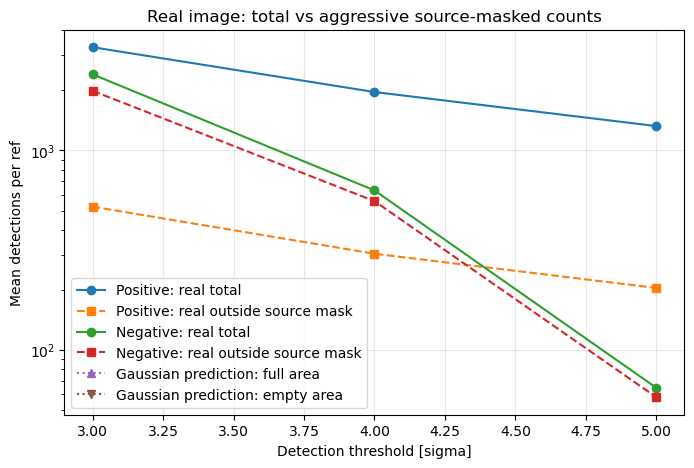

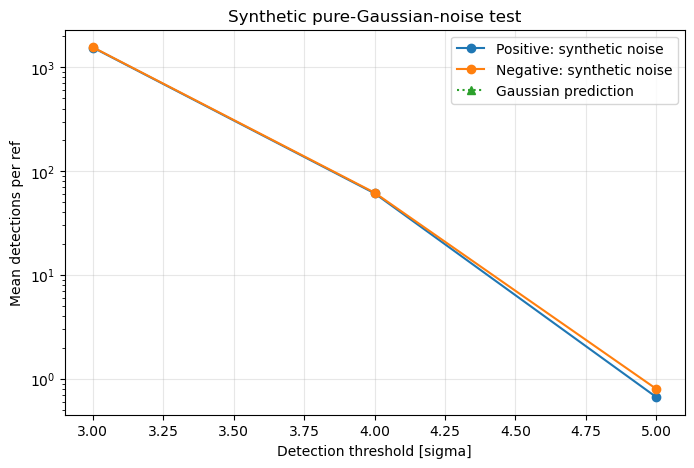


Done. Paste me:
1) Real image summary
2) Synthetic Gaussian noise summary
3) Any error rows


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lsst.daf.butler import Butler
try:
    from lsst.meas.algorithms import SourceDetectionTask, SourceDetectionConfig
except Exception:
    from lsst.meas.algorithms.detection import SourceDetectionTask, SourceDetectionConfig

# =============================================================================
# Settings
# =============================================================================
REPO = "dp2_prep"
COLLECTIONS = "LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2"
WHERE = "instrument='LSSTCam' AND day_obs>=20250801 AND day_obs<=20250921 AND band in ('u','g','r','i','z','y')"

MAX_REFS = 3
THRESHOLDS = [5.0, 4.0, 3.0]

# aggressive source mask built from all 3-sigma positive detections
MASK_SEED_THRESHOLD = 3.0
MASK_RADIUS_PX = 25

# synthetic pure-noise realizations per ref
N_NOISE_REALIZATIONS = 10

MAKE_PLOTS = True


# =============================================================================
# Utilities
# =============================================================================
def get_ref_meta(ref, idx=None):
    data_id = ref.dataId
    return {
        "ref_idx": idx,
        "visit": data_id["visit"] if "visit" in data_id else None,
        "detector": data_id["detector"] if "detector" in data_id else None,
        "band": data_id["band"] if "band" in data_id else None,
        "day_obs": data_id["day_obs"] if "day_obs" in data_id else None,
    }


def load_exposure_and_background(butler, ref):
    exp = butler.get("preliminary_visit_image", dataId=ref.dataId)
    bg = butler.get("preliminary_visit_image_background", dataId=ref.dataId)
    return exp, bg


def estimate_psf_sigma_pix(exposure):
    try:
        bbox = exposure.getBBox()
        x = bbox.getMinX() + 0.5 * (bbox.getWidth() - 1)
        y = bbox.getMinY() + 0.5 * (bbox.getHeight() - 1)
        shape = exposure.getPsf().computeShape()
        try:
            return float(shape.getDeterminantRadius())
        except Exception:
            ixx = float(shape.getIxx())
            iyy = float(shape.getIyy())
            return float(np.sqrt(0.5 * (ixx + iyy)))
    except Exception:
        try:
            shape = exposure.getPsf().computeShape()
            return float(shape.getDeterminantRadius())
        except Exception:
            return np.nan


def gaussian_false_detections(area_pix, sigma_g_pix, nu):
    if not np.isfinite(area_pix) or not np.isfinite(sigma_g_pix) or sigma_g_pix <= 0:
        return np.nan
    coeff = 1.0 / (2.0 ** 2.5 * np.pi ** 1.5)
    return (area_pix / sigma_g_pix ** 2) * coeff * nu * np.exp(-0.5 * nu ** 2)


def make_detection_task(threshold, polarity="positive",
                        do_temp_local_background=True,
                        reestimate_background=True):
    cfg = SourceDetectionConfig()
    cfg.thresholdValue = float(threshold)
    cfg.thresholdPolarity = str(polarity)
    cfg.includeThresholdMultiplier = 1.0
    cfg.reEstimateBackground = bool(reestimate_background)
    cfg.doTempLocalBackground = bool(do_temp_local_background)
    return SourceDetectionTask(config=cfg)


def run_detection(exp, bg, threshold, polarity="positive",
                  do_temp_local_background=True,
                  reestimate_background=True):
    task = make_detection_task(
        threshold=threshold,
        polarity=polarity,
        do_temp_local_background=do_temp_local_background,
        reestimate_background=reestimate_background,
    )
    return task.detectFootprints(
        exposure=exp,
        doSmooth=True,
        sigma=None,
        clearMask=True,
        expId=None,
        background=bg,
    )


def footprintset_to_list(fp_set):
    if fp_set is None:
        return []
    try:
        return list(fp_set.getFootprints())
    except Exception:
        try:
            return list(fp_set)
        except Exception:
            return []


def peak_xy(peak):
    x = None
    y = None
    for name in ("getIx", "getFx", "getX"):
        if hasattr(peak, name):
            x = getattr(peak, name)()
            break
    for name in ("getIy", "getFy", "getY"):
        if hasattr(peak, name):
            y = getattr(peak, name)()
            break
    if x is None or y is None:
        return None
    return int(round(float(x))), int(round(float(y)))


def best_peak_xy_from_footprint(fp):
    try:
        peaks = list(fp.getPeaks())
    except Exception:
        peaks = []
    if len(peaks) == 0:
        return None

    def _peak_value(p):
        for name in ("getPeakValue", "getValue"):
            if hasattr(p, name):
                try:
                    return float(getattr(p, name)())
                except Exception:
                    pass
        return 0.0

    best = max(peaks, key=_peak_value)
    return peak_xy(best)


def disk_offsets(radius):
    rr = int(radius)
    yy, xx = np.mgrid[-rr:rr + 1, -rr:rr + 1]
    keep = (xx * xx + yy * yy) <= rr * rr
    return yy[keep], xx[keep]


def build_peak_mask(image_shape, footprints, radius_px=25):
    mask = np.zeros(image_shape, dtype=bool)
    dy, dx = disk_offsets(radius_px)
    h, w = image_shape
    for fp in footprints:
        xy = best_peak_xy_from_footprint(fp)
        if xy is None:
            continue
        x0, y0 = xy
        xs = x0 + dx
        ys = y0 + dy
        keep = (xs >= 0) & (xs < w) & (ys >= 0) & (ys < h)
        mask[ys[keep], xs[keep]] = True
    return mask


def count_footprints_outside_mask(footprints, mask):
    h, w = mask.shape
    n = 0
    for fp in footprints:
        xy = best_peak_xy_from_footprint(fp)
        if xy is None:
            continue
        x, y = xy
        if 0 <= x < w and 0 <= y < h and not mask[y, x]:
            n += 1
    return n


def make_gaussian_noise_exposure(template_exp, rng):
    exp = template_exp.clone()

    var = exp.variance.array.astype(np.float64, copy=True)
    good = np.isfinite(var) & (var > 0)
    if np.any(good):
        median_var = np.median(var[good])
    else:
        median_var = 1.0

    # replace bad variance pixels with median
    var[~good] = median_var

    noise = rng.normal(loc=0.0, scale=np.sqrt(var), size=var.shape)

    exp.image.array[:, :] = noise
    exp.variance.array[:, :] = var
    try:
        exp.mask.array[:, :] = 0
    except Exception:
        pass

    return exp


# =============================================================================
# Run
# =============================================================================
butler = Butler(REPO, collections=COLLECTIONS)

refs = list(
    butler.registry.queryDatasets(
        "preliminary_visit_image",
        instrument="LSSTCam",
        findFirst=True,
        where=WHERE,
    )
)
if len(refs) == 0:
    raise RuntimeError("No refs found.")

refs = refs[:MAX_REFS]
print(f"Using {len(refs)} refs")
for i, ref in enumerate(refs):
    print(get_ref_meta(ref, i))

real_rows = []
noise_rows = []
errors = []

for idx, ref in enumerate(refs):
    meta = get_ref_meta(ref, idx)

    try:
        exp, bg = load_exposure_and_background(butler, ref)
        image_shape = exp.image.array.shape
        area_pix = int(image_shape[0] * image_shape[1])
        sigma_g_pix = estimate_psf_sigma_pix(exp)

        # aggressive source mask from real 3-sigma positive detections
        seed_res = run_detection(
            exp, bg,
            threshold=MASK_SEED_THRESHOLD,
            polarity="positive",
            do_temp_local_background=True,
            reestimate_background=True,
        )
        seed_fps = footprintset_to_list(seed_res.positive)
        source_mask = build_peak_mask(image_shape, seed_fps, radius_px=MASK_RADIUS_PX)
        empty_fraction = float((~source_mask).mean())

        # -------------------------------------------------
        # Real image: total vs outside aggressive source mask
        # -------------------------------------------------
        for thr in THRESHOLDS:
            for pol in ["positive", "negative"]:
                res = run_detection(
                    exp, bg,
                    threshold=thr,
                    polarity=pol,
                    do_temp_local_background=True,
                    reestimate_background=True,
                )

                if pol == "positive":
                    fps = footprintset_to_list(res.positive)
                    count_total = int(res.numPos)
                else:
                    fps = footprintset_to_list(res.negative)
                    count_total = int(res.numNeg)

                count_outside = int(count_footprints_outside_mask(fps, source_mask))

                real_rows.append({
                    **meta,
                    "threshold": float(thr),
                    "polarity": pol,
                    "count_total": count_total,
                    "count_outside_source_mask": count_outside,
                    "empty_fraction": empty_fraction,
                    "area_pix": area_pix,
                    "psf_sigma_pix": sigma_g_pix,
                    "gaussian_pred_full_area": float(gaussian_false_detections(area_pix, sigma_g_pix, thr)),
                    "gaussian_pred_empty_area": float(gaussian_false_detections(area_pix * empty_fraction, sigma_g_pix, thr)),
                })

        # -------------------------------------------------
        # Synthetic pure Gaussian noise with same variance plane
        # -------------------------------------------------
        for rep in range(N_NOISE_REALIZATIONS):
            rng = np.random.default_rng(1000 * idx + rep)
            noise_exp = make_gaussian_noise_exposure(exp, rng)

            for thr in THRESHOLDS:
                for pol in ["positive", "negative"]:
                    noise_res = run_detection(
                        noise_exp, None,
                        threshold=thr,
                        polarity=pol,
                        do_temp_local_background=True,
                        reestimate_background=True,
                    )

                    if pol == "positive":
                        count_noise = int(noise_res.numPos)
                    else:
                        count_noise = int(noise_res.numNeg)

                    noise_rows.append({
                        **meta,
                        "noise_realization": rep,
                        "threshold": float(thr),
                        "polarity": pol,
                        "count_noise": count_noise,
                        "area_pix": area_pix,
                        "psf_sigma_pix": sigma_g_pix,
                        "gaussian_pred_full_area": float(gaussian_false_detections(area_pix, sigma_g_pix, thr)),
                    })

    except Exception as e:
        errors.append({**meta, "error": repr(e)})

real_df = pd.DataFrame(real_rows)
noise_df = pd.DataFrame(noise_rows)
err_df = pd.DataFrame(errors)

print("\n=== Errors ===")
display(err_df if len(err_df) > 0 else pd.DataFrame({"status": ["no errors recorded"]}))

print("\n=== Real image raw rows ===")
display(real_df.head(20))

print("\n=== Synthetic noise raw rows ===")
display(noise_df.head(20))


# =============================================================================
# Summaries
# =============================================================================
if len(real_df) > 0:
    real_summary = (
        real_df
        .groupby(["threshold", "polarity"], dropna=False)
        .agg(
            n_refs=("count_total", "size"),
            mean_total=("count_total", "mean"),
            median_total=("count_total", "median"),
            mean_outside_source_mask=("count_outside_source_mask", "mean"),
            median_outside_source_mask=("count_outside_source_mask", "median"),
            mean_empty_fraction=("empty_fraction", "mean"),
            mean_gaussian_full=("gaussian_pred_full_area", "mean"),
            mean_gaussian_empty=("gaussian_pred_empty_area", "mean"),
        )
        .reset_index()
        .sort_values(["polarity", "threshold"], ascending=[True, False])
    )

    real_summary["mean_total_over_gauss_full"] = real_summary["mean_total"] / real_summary["mean_gaussian_full"]
    real_summary["mean_outside_over_gauss_empty"] = real_summary["mean_outside_source_mask"] / real_summary["mean_gaussian_empty"]

    print("\n=== Real image summary ===")
    display(real_summary)

if len(noise_df) > 0:
    noise_summary = (
        noise_df
        .groupby(["threshold", "polarity"], dropna=False)
        .agg(
            n_runs=("count_noise", "size"),
            mean_noise_count=("count_noise", "mean"),
            std_noise_count=("count_noise", "std"),
            median_noise_count=("count_noise", "median"),
            mean_gaussian_full=("gaussian_pred_full_area", "mean"),
        )
        .reset_index()
        .sort_values(["polarity", "threshold"], ascending=[True, False])
    )
    noise_summary["mean_noise_over_gauss"] = noise_summary["mean_noise_count"] / noise_summary["mean_gaussian_full"]

    print("\n=== Synthetic Gaussian noise summary ===")
    display(noise_summary)


# =============================================================================
# Plots
# =============================================================================
if MAKE_PLOTS and len(real_df) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    for pol, label in [("positive", "Positive"), ("negative", "Negative")]:
        sub = real_df[real_df["polarity"] == pol].groupby("threshold").agg(
            mean_total=("count_total", "mean"),
            mean_outside=("count_outside_source_mask", "mean"),
            mean_gauss_full=("gaussian_pred_full_area", "mean"),
            mean_gauss_empty=("gaussian_pred_empty_area", "mean"),
        ).reset_index().sort_values("threshold")
        ax.plot(sub["threshold"], sub["mean_total"], marker="o", label=f"{label}: real total")
        ax.plot(sub["threshold"], sub["mean_outside"], marker="s", linestyle="--", label=f"{label}: real outside source mask")
    ga = real_df.groupby("threshold").agg(
        mean_gauss_full=("gaussian_pred_full_area", "mean"),
        mean_gauss_empty=("gaussian_pred_empty_area", "mean"),
    ).reset_index().sort_values("threshold")
    ax.plot(ga["threshold"], ga["mean_gauss_full"], marker="^", linestyle=":", label="Gaussian prediction: full area")
    ax.plot(ga["threshold"], ga["mean_gauss_empty"], marker="v", linestyle=":", label="Gaussian prediction: empty area")
    ax.set_yscale("log")
    ax.set_xlabel("Detection threshold [sigma]")
    ax.set_ylabel("Mean detections per ref")
    ax.set_title("Real image: total vs aggressive source-masked counts")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

if MAKE_PLOTS and len(noise_df) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    for pol, label in [("positive", "Positive"), ("negative", "Negative")]:
        sub = noise_df[noise_df["polarity"] == pol].groupby("threshold").agg(
            mean_noise=("count_noise", "mean"),
            mean_gauss=("gaussian_pred_full_area", "mean"),
        ).reset_index().sort_values("threshold")
        ax.plot(sub["threshold"], sub["mean_noise"], marker="o", label=f"{label}: synthetic noise")
    ga = noise_df.groupby("threshold").agg(mean_gauss=("gaussian_pred_full_area", "mean")).reset_index().sort_values("threshold")
    ax.plot(ga["threshold"], ga["mean_gauss"], marker="^", linestyle=":", label="Gaussian prediction")
    ax.set_yscale("log")
    ax.set_xlabel("Detection threshold [sigma]")
    ax.set_ylabel("Mean detections per ref")
    ax.set_title("Synthetic pure-Gaussian-noise test")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

print("\nDone. Paste me:")
print("1) Real image summary")
print("2) Synthetic Gaussian noise summary")
print("3) Any error rows")

Using 3 refs
{'ref_idx': 0, 'visit': 2025080600341, 'detector': 1, 'band': 'i', 'day_obs': 20250806}
{'ref_idx': 1, 'visit': 2025080600342, 'detector': 1, 'band': 'i', 'day_obs': 20250806}
{'ref_idx': 2, 'visit': 2025080600343, 'detector': 1, 'band': 'i', 'day_obs': 20250806}

Ref 0: visit=2025080600341 det=1 band=i
Available mask planes: ['BAD', 'CR', 'CROSSTALK', 'DETECTED', 'DETECTED_NEGATIVE', 'EDGE', 'INTRP', 'ITL_DIP', 'NOT_DEBLENDED', 'NO_DATA', 'PARTLY_VIGNETTED', 'SAT', 'SPIKE', 'STREAK', 'SUSPECT', 'UNMASKEDNAN', 'VIGNETTED']
Using excluded mask planes: ['BAD', 'SAT', 'EDGE', 'NO_DATA', 'CR', 'DETECTED', 'DETECTED_NEGATIVE']


/tmp/ipykernel_52/2695181724.py:202: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  frac = peak_df["mask_planes_here"].fillna("").str.contains(rf"(^|,){plane}(,|$)", regex=True).mean()


/tmp/ipykernel_52/2695181724.py:202: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  frac = peak_df["mask_planes_here"].fillna("").str.contains(rf"(^|,){plane}(,|$)", regex=True).mean()



Ref 1: visit=2025080600342 det=1 band=i
Available mask planes: ['BAD', 'CR', 'CROSSTALK', 'DETECTED', 'DETECTED_NEGATIVE', 'EDGE', 'INTRP', 'ITL_DIP', 'NOT_DEBLENDED', 'NO_DATA', 'PARTLY_VIGNETTED', 'SAT', 'SPIKE', 'STREAK', 'SUSPECT', 'UNMASKEDNAN', 'VIGNETTED']
Using excluded mask planes: ['BAD', 'SAT', 'EDGE', 'NO_DATA', 'CR', 'DETECTED', 'DETECTED_NEGATIVE']


/tmp/ipykernel_52/2695181724.py:202: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  frac = peak_df["mask_planes_here"].fillna("").str.contains(rf"(^|,){plane}(,|$)", regex=True).mean()


...

mean                         median  \
run_tag                baseline exclude_problem_masks baseline   
threshold polarity                                               
5.0       negative    65.333333             48.333333     66.0   
          positive  1296.666667           1297.333333   1304.0   

                                          
run_tag            exclude_problem_masks  
threshold polarity                        
5.0       negative                  52.0  
          positive                1299.0


=== Negative-peak mask-plane summary ===


,ref_idx,visit,detector,run_tag,mask_plane,fraction_of_peaks_on_this_plane,n_peaks
0,0,2025080600341,1,baseline,DETECTED_NEGATIVE,1.000000,52
34,1,2025080600342,1,baseline,DETECTED_NEGATIVE,1.000000,78
68,2,2025080600343,1,baseline,DETECTED_NEGATIVE,1.000000,66
69,2,2025080600343,1,baseline,PARTLY_VIGNETTED,0.712121,66
35,1,2025080600342,1,baseline,PARTLY_VIGNETTED,0.705128,78
1,0,2025080600341,1,baseline,PARTLY_VIGNETTED,0.615385,52
2,0,2025080600341,1,baseline,BAD,0.038462,52
3,0,2025080600341,1,baseline,INTRP,0.038462,52
70,2,2025080600343,1,baseline,BAD,0.015152,66
71,2,2025080600343,1,baseline,INTRP,0.015152,66



=== Example negative peaks ===


,ref_idx,visit,detector,band,day_obs,run_tag,polarity,threshold,excluded_mask_planes,peak_index,x,y,peak_value,mask_value,mask_planes_here
6832,2,2025080600343,1,i,20250806,baseline,negative,5.0,,65,3960,3971,-27.001143,64,DETECTED_NEGATIVE
6826,2,2025080600343,1,i,20250806,baseline,negative,5.0,,59,3864,3958,-27.146292,64,DETECTED_NEGATIVE
6827,2,2025080600343,1,i,20250806,baseline,negative,5.0,,60,3975,3960,-27.293707,64,DETECTED_NEGATIVE
6815,2,2025080600343,1,i,20250806,baseline,negative,5.0,,48,4060,2531,-27.426144,64,DETECTED_NEGATIVE
6829,2,2025080600343,1,i,20250806,baseline,negative,5.0,,62,3757,3982,-27.787584,64,DETECTED_NEGATIVE
6825,2,2025080600343,1,i,20250806,baseline,negative,5.0,,58,3802,3942,-27.841927,64,DETECTED_NEGATIVE
4153,1,2025080600342,1,i,20250806,baseline,negative,5.0,,52,4060,2489,-27.865826,64,DETECTED_NEGATIVE
4171,1,2025080600342,1,i,20250806,baseline,negative,5.0,,70,3985,3967,-27.904119,64,DETECTED_NEGATIVE
4175,1,2025080600342,1,i,20250806,baseline,negative,5.0,,74,3656,3972,-27.931526,64,DETECTED_NEGATIVE
6804,2,2025080600343,1,i,20250806,baseline,negative,5.0,,37,4060,2186,-28.021370,64,DETECTED_NEGATIVE


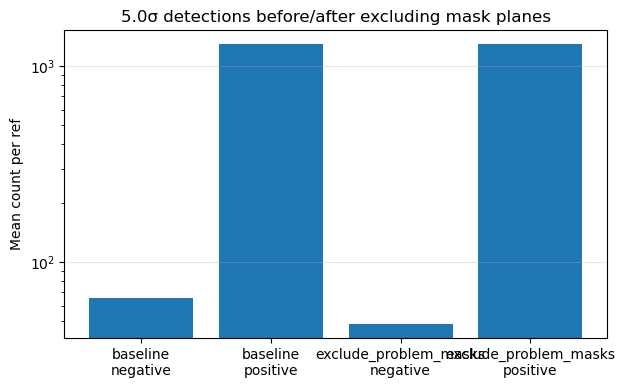

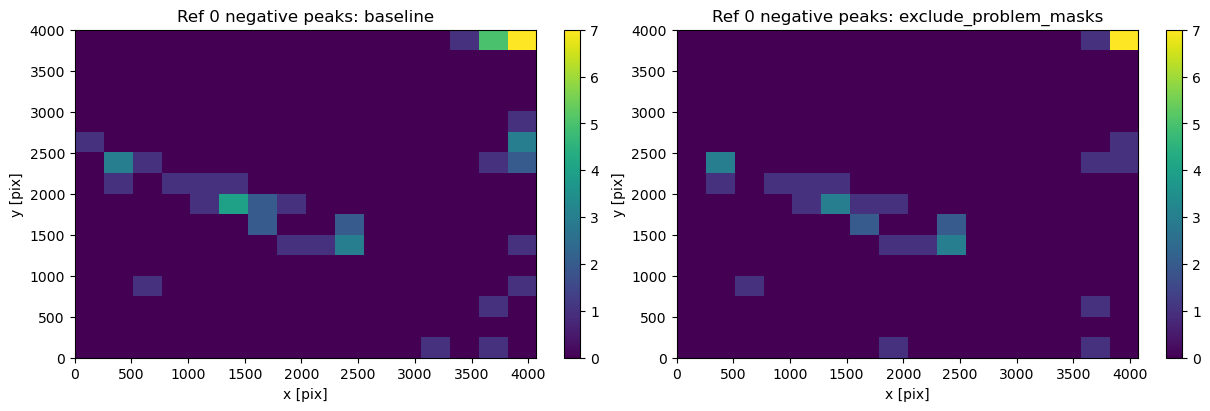

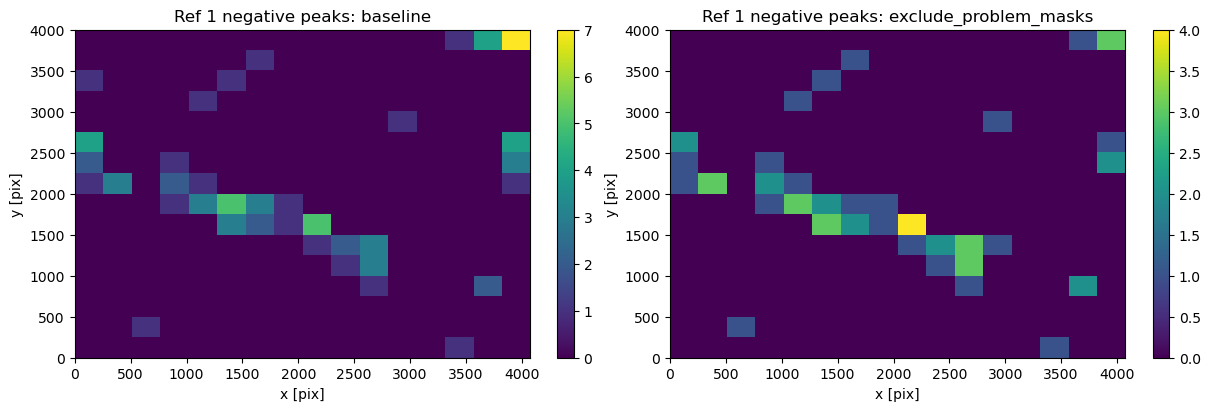

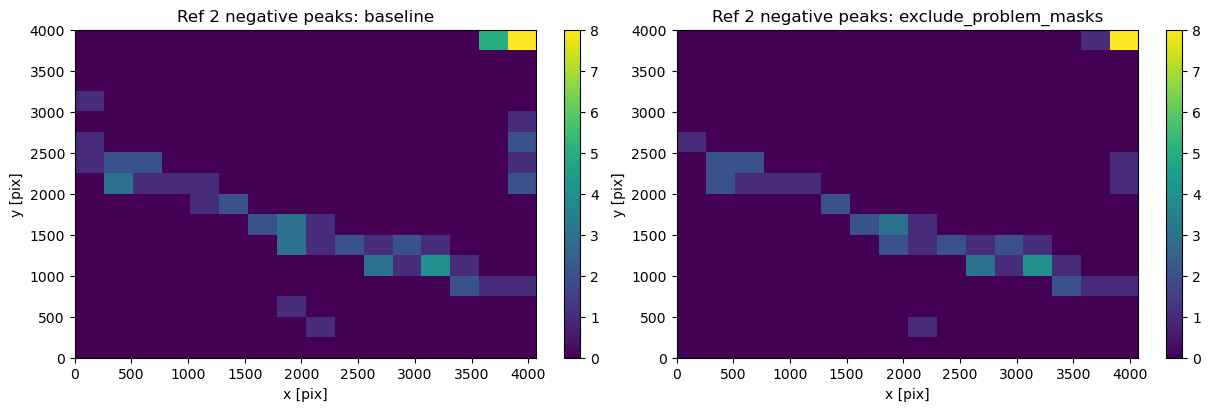


Paste me these outputs:
1) Count table
2) Count summary
3) Negative-peak mask-plane summary


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lsst.daf.butler import Butler
try:
    from lsst.meas.algorithms import SourceDetectionTask, SourceDetectionConfig
except Exception:
    from lsst.meas.algorithms.detection import SourceDetectionTask, SourceDetectionConfig

# =============================================================================
# Settings
# =============================================================================
REPO = "dp2_prep"
COLLECTIONS = "LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2"
WHERE = "instrument='LSSTCam' AND day_obs>=20250801 AND day_obs<=20250921 AND band in ('u','g','r','i','z','y')"

MAX_REFS = 3
THRESHOLD = 5.0

# Candidate problematic mask planes.
# The code will automatically keep only those that exist on the image.
MASK_PLANES_TO_EXCLUDE = ["BAD", "SAT", "EDGE", "NO_DATA", "CR", "DETECTED", "DETECTED_NEGATIVE"]

# 2D histogram binning for spatial maps
NBINS_X = 16
NBINS_Y = 16

MAKE_PLOTS = True


# =============================================================================
# Utilities
# =============================================================================
def get_ref_meta(ref, idx=None):
    data_id = ref.dataId
    return {
        "ref_idx": idx,
        "visit": data_id["visit"] if "visit" in data_id else None,
        "detector": data_id["detector"] if "detector" in data_id else None,
        "band": data_id["band"] if "band" in data_id else None,
        "day_obs": data_id["day_obs"] if "day_obs" in data_id else None,
    }


def load_exposure_and_background(butler, ref):
    exp = butler.get("preliminary_visit_image", dataId=ref.dataId)
    bg = butler.get("preliminary_visit_image_background", dataId=ref.dataId)
    return exp, bg


def available_mask_plane_names(exposure):
    d = exposure.mask.getMaskPlaneDict()
    return list(d.keys())


def keep_existing_mask_planes(exposure, requested_planes):
    available = set(available_mask_plane_names(exposure))
    return [p for p in requested_planes if p in available]


def make_detection_task(threshold, polarity="positive", exclude_mask_planes=None,
                        do_temp_local_background=True, reestimate_background=True):
    cfg = SourceDetectionConfig()
    cfg.thresholdValue = float(threshold)
    cfg.thresholdPolarity = str(polarity)
    cfg.includeThresholdMultiplier = 1.0
    cfg.reEstimateBackground = bool(reestimate_background)
    cfg.doTempLocalBackground = bool(do_temp_local_background)
    cfg.excludeMaskPlanes = list(exclude_mask_planes or [])
    return SourceDetectionTask(config=cfg)


def run_detection(exp, bg, threshold, polarity="positive", exclude_mask_planes=None,
                  do_temp_local_background=True, reestimate_background=True):
    task = make_detection_task(
        threshold=threshold,
        polarity=polarity,
        exclude_mask_planes=exclude_mask_planes,
        do_temp_local_background=do_temp_local_background,
        reestimate_background=reestimate_background,
    )
    return task.detectFootprints(
        exposure=exp,
        doSmooth=True,
        sigma=None,
        clearMask=True,
        expId=None,
        background=bg,
    )


def footprintset_to_list(fp_set):
    if fp_set is None:
        return []
    try:
        return list(fp_set.getFootprints())
    except Exception:
        try:
            return list(fp_set)
        except Exception:
            return []


def peak_xy(peak):
    x = None
    y = None
    for name in ("getIx", "getFx", "getX"):
        if hasattr(peak, name):
            x = getattr(peak, name)()
            break
    for name in ("getIy", "getFy", "getY"):
        if hasattr(peak, name):
            y = getattr(peak, name)()
            break
    if x is None or y is None:
        return None
    return int(round(float(x))), int(round(float(y)))


def best_peak_from_footprint(fp):
    try:
        peaks = list(fp.getPeaks())
    except Exception:
        peaks = []
    if len(peaks) == 0:
        return None

    def peak_value(p):
        for name in ("getPeakValue", "getValue"):
            if hasattr(p, name):
                try:
                    return float(getattr(p, name)())
                except Exception:
                    pass
        return 0.0

    return max(peaks, key=peak_value)


def best_peak_xy_from_footprint(fp):
    p = best_peak_from_footprint(fp)
    if p is None:
        return None
    return peak_xy(p)


def make_peak_table(exposure, footprints, ref_meta, run_tag, polarity, threshold, excluded_planes):
    mask = exposure.mask
    mask_plane_dict = mask.getMaskPlaneDict()
    h, w = exposure.image.array.shape

    rows = []
    for i, fp in enumerate(footprints):
        p = best_peak_from_footprint(fp)
        xy = best_peak_xy_from_footprint(fp)
        if xy is None:
            continue
        x, y = xy
        if not (0 <= x < w and 0 <= y < h):
            continue

        peak_value = np.nan
        if p is not None:
            for name in ("getPeakValue", "getValue"):
                if hasattr(p, name):
                    try:
                        peak_value = float(getattr(p, name)())
                        break
                    except Exception:
                        pass

        mask_val = int(mask.array[y, x])
        flags_here = []
        for name, bit in mask_plane_dict.items():
            if mask_val & (1 << bit):
                flags_here.append(name)

        rows.append({
            **ref_meta,
            "run_tag": run_tag,
            "polarity": polarity,
            "threshold": float(threshold),
            "excluded_mask_planes": ",".join(excluded_planes),
            "peak_index": i,
            "x": x,
            "y": y,
            "peak_value": peak_value,
            "mask_value": mask_val,
            "mask_planes_here": ",".join(flags_here),
        })

    return pd.DataFrame(rows)


def summarize_peak_mask_flags(peak_df, candidate_planes):
    if len(peak_df) == 0:
        return pd.DataFrame()

    out = []
    for plane in candidate_planes:
        frac = peak_df["mask_planes_here"].fillna("").str.contains(rf"(^|,){plane}(,|$)", regex=True).mean()
        out.append({
            "mask_plane": plane,
            "fraction_of_peaks_on_this_plane": frac,
            "n_peaks": len(peak_df),
        })
    return pd.DataFrame(out).sort_values("fraction_of_peaks_on_this_plane", ascending=False)


def make_2d_hist(df, x_edges, y_edges):
    if len(df) == 0:
        return np.zeros((len(y_edges) - 1, len(x_edges) - 1), dtype=int)
    H, _, _ = np.histogram2d(df["y"], df["x"], bins=[y_edges, x_edges])
    return H


# =============================================================================
# Run
# =============================================================================
butler = Butler(REPO, collections=COLLECTIONS)

refs = list(
    butler.registry.queryDatasets(
        "preliminary_visit_image",
        instrument="LSSTCam",
        findFirst=True,
        where=WHERE,
    )
)

if len(refs) == 0:
    raise RuntimeError("No refs found.")

refs = refs[:MAX_REFS]
print(f"Using {len(refs)} refs")
for i, ref in enumerate(refs):
    print(get_ref_meta(ref, i))

count_rows = []
peak_tables = []
flag_summaries = []
errors = []

for idx, ref in enumerate(refs):
    meta = get_ref_meta(ref, idx)

    try:
        exp, bg = load_exposure_and_background(butler, ref)
        h, w = exp.image.array.shape
        existing_planes = keep_existing_mask_planes(exp, MASK_PLANES_TO_EXCLUDE)

        print(f"\nRef {idx}: visit={meta['visit']} det={meta['detector']} band={meta['band']}")
        print("Available mask planes:", available_mask_plane_names(exp))
        print("Using excluded mask planes:", existing_planes)

        for run_tag, excluded in [
            ("baseline", []),
            ("exclude_problem_masks", existing_planes),
        ]:
            for polarity in ["positive", "negative"]:
                res = run_detection(
                    exp, bg,
                    threshold=THRESHOLD,
                    polarity=polarity,
                    exclude_mask_planes=excluded,
                    do_temp_local_background=True,
                    reestimate_background=True,
                )

                if polarity == "positive":
                    fps = footprintset_to_list(res.positive)
                    n = int(res.numPos)
                else:
                    fps = footprintset_to_list(res.negative)
                    n = int(res.numNeg)

                count_rows.append({
                    **meta,
                    "run_tag": run_tag,
                    "polarity": polarity,
                    "threshold": float(THRESHOLD),
                    "excluded_mask_planes": ",".join(excluded),
                    "count": n,
                    "n_footprints": len(fps),
                })

                peak_df = make_peak_table(
                    exposure=exp,
                    footprints=fps,
                    ref_meta=meta,
                    run_tag=run_tag,
                    polarity=polarity,
                    threshold=THRESHOLD,
                    excluded_planes=excluded,
                )
                peak_tables.append(peak_df)

                if polarity == "negative":
                    summary_df = summarize_peak_mask_flags(
                        peak_df,
                        candidate_planes=available_mask_plane_names(exp),
                    )
                    if len(summary_df) > 0:
                        summary_df.insert(0, "ref_idx", idx)
                        summary_df.insert(1, "visit", meta["visit"])
                        summary_df.insert(2, "detector", meta["detector"])
                        summary_df.insert(3, "run_tag", run_tag)
                        flag_summaries.append(summary_df)

    except Exception as e:
        errors.append({**meta, "error": repr(e)})

count_df = pd.DataFrame(count_rows)
peaks_df = pd.concat(peak_tables, ignore_index=True) if len(peak_tables) > 0 else pd.DataFrame()
flag_summary_df = pd.concat(flag_summaries, ignore_index=True) if len(flag_summaries) > 0 else pd.DataFrame()
err_df = pd.DataFrame(errors)

print("\n=== Errors ===")
display(err_df if len(err_df) > 0 else pd.DataFrame({"status": ["no errors recorded"]}))

print("\n=== Count table ===")
display(count_df)

if len(count_df) > 0:
    summary_df = (
        count_df
        .pivot_table(
            index=["threshold", "polarity"],
            columns="run_tag",
            values="count",
            aggfunc=["mean", "median"]
        )
    )
    print("\n=== Count summary ===")
    display(summary_df)

if len(flag_summary_df) > 0:
    print("\n=== Negative-peak mask-plane summary ===")
    display(
        flag_summary_df.sort_values(
            ["run_tag", "fraction_of_peaks_on_this_plane"],
            ascending=[True, False]
        ).head(40)
    )

if len(peaks_df) > 0:
    print("\n=== Example negative peaks ===")
    display(
        peaks_df[peaks_df["polarity"] == "negative"]
        .sort_values(["run_tag", "peak_value"], ascending=[True, False])
        .head(30)
    )

# =============================================================================
# Plots
# =============================================================================
if MAKE_PLOTS and len(count_df) > 0:
    fig, ax = plt.subplots(figsize=(7, 4))
    sub = (
        count_df
        .groupby(["run_tag", "polarity"])
        .agg(mean_count=("count", "mean"))
        .reset_index()
    )
    labels = []
    vals = []
    for _, row in sub.iterrows():
        labels.append(f"{row['run_tag']}\n{row['polarity']}")
        vals.append(row["mean_count"])
    ax.bar(labels, vals)
    ax.set_yscale("log")
    ax.set_ylabel("Mean count per ref")
    ax.set_title(f"{THRESHOLD}σ detections before/after excluding mask planes")
    ax.grid(True, axis="y", alpha=0.3)
    plt.show()

if MAKE_PLOTS and len(peaks_df) > 0:
    for idx, ref in enumerate(refs):
        meta = get_ref_meta(ref, idx)
        exp, _ = load_exposure_and_background(butler, ref)
        h, w = exp.image.array.shape
        x_edges = np.linspace(0, w, NBINS_X + 1)
        y_edges = np.linspace(0, h, NBINS_Y + 1)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

        for ax, run_tag in zip(axes, ["baseline", "exclude_problem_masks"]):
            sub = peaks_df[
                (peaks_df["ref_idx"] == idx) &
                (peaks_df["polarity"] == "negative") &
                (peaks_df["run_tag"] == run_tag)
            ].copy()

            H = make_2d_hist(sub, x_edges, y_edges)
            im = ax.imshow(
                H,
                origin="lower",
                aspect="auto",
                extent=[0, w, 0, h]
            )
            ax.set_title(f"Ref {idx} negative peaks: {run_tag}")
            ax.set_xlabel("x [pix]")
            ax.set_ylabel("y [pix]")
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        plt.show()

print("\nPaste me these outputs:")
print("1) Count table")
print("2) Count summary")
print("3) Negative-peak mask-plane summary")

Using 3 refs
{'ref_idx': 0, 'visit': 2025080600341, 'detector': 1, 'band': 'i', 'day_obs': 20250806}
{'ref_idx': 1, 'visit': 2025080600342, 'detector': 1, 'band': 'i', 'day_obs': 20250806}
{'ref_idx': 2, 'visit': 2025080600343, 'detector': 1, 'band': 'i', 'day_obs': 20250806}



=== Raw counts ===


,ref_idx,visit,detector,band,day_obs,threshold_type,threshold,polarity,count
0,0,2025080600341,1,i,20250806,pixel_stdev,5.0,positive,1353
1,0,2025080600341,1,i,20250806,pixel_stdev,5.0,negative,147
2,0,2025080600341,1,i,20250806,pixel_stdev,4.0,positive,1890
3,0,2025080600341,1,i,20250806,pixel_stdev,4.0,negative,977
4,0,2025080600341,1,i,20250806,pixel_stdev,3.0,positive,3434
5,0,2025080600341,1,i,20250806,pixel_stdev,3.0,negative,3093
6,0,2025080600341,1,i,20250806,stdev,5.0,positive,1060
7,0,2025080600341,1,i,20250806,stdev,5.0,negative,0
8,0,2025080600341,1,i,20250806,stdev,4.0,positive,1260
9,0,2025080600341,1,i,20250806,stdev,4.0,negative,44



=== Summary ===


,threshold_type,threshold,polarity,n_refs,mean_count,median_count
4,pixel_stdev,5.0,negative,3,156.000000,153.0
2,pixel_stdev,4.0,negative,3,945.000000,938.0
0,pixel_stdev,3.0,negative,3,2667.333333,2490.0
5,pixel_stdev,5.0,positive,3,1296.666667,1304.0
3,pixel_stdev,4.0,positive,3,1814.666667,1795.0
1,pixel_stdev,3.0,positive,3,3048.000000,2906.0
10,stdev,5.0,negative,3,1.333333,2.0
8,stdev,4.0,negative,3,38.666667,44.0
6,stdev,3.0,negative,3,776.666667,761.0
11,stdev,5.0,positive,3,980.000000,963.0


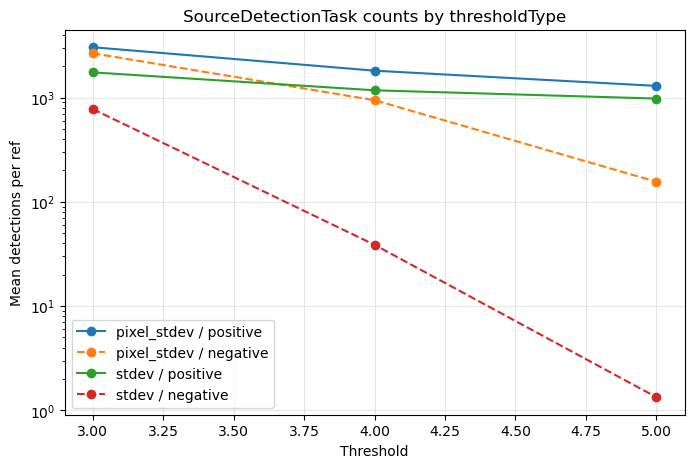


Paste me the Summary table.


In [1]:
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lsst.daf.butler import Butler
try:
    from lsst.meas.algorithms import SourceDetectionTask, SourceDetectionConfig
except Exception:
    from lsst.meas.algorithms.detection import SourceDetectionTask, SourceDetectionConfig

# =============================================================================
# Settings
# =============================================================================
REPO = "dp2_prep"
COLLECTIONS = "LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2"
WHERE = "instrument='LSSTCam' AND day_obs>=20250801 AND day_obs<=20250921 AND band in ('u','g','r','i','z','y')"

MAX_REFS = 3
THRESHOLDS = [5.0, 4.0, 3.0]

# Only sigma-like threshold types for direct comparison
THRESHOLD_TYPES = ["pixel_stdev", "stdev"]

DO_TEMP_LOCAL_BACKGROUND = False
DO_TEMP_WIDE_BACKGROUND = False
RE_ESTIMATE_BACKGROUND = False

MAKE_PLOTS = True


# =============================================================================
# Helpers
# =============================================================================
def get_ref_meta(ref, idx=None):
    d = ref.dataId
    return {
        "ref_idx": idx,
        "visit": d["visit"] if "visit" in d else None,
        "detector": d["detector"] if "detector" in d else None,
        "band": d["band"] if "band" in d else None,
        "day_obs": d["day_obs"] if "day_obs" in d else None,
    }

def make_detection_task(threshold, threshold_type, polarity="positive"):
    cfg = SourceDetectionConfig()
    cfg.thresholdValue = float(threshold)
    cfg.thresholdType = str(threshold_type)
    cfg.thresholdPolarity = str(polarity)
    cfg.includeThresholdMultiplier = 1.0
    cfg.reEstimateBackground = bool(RE_ESTIMATE_BACKGROUND)
    cfg.doTempLocalBackground = bool(DO_TEMP_LOCAL_BACKGROUND)
    if hasattr(cfg, "doTempWideBackground"):
        cfg.doTempWideBackground = bool(DO_TEMP_WIDE_BACKGROUND)
    return SourceDetectionTask(config=cfg)

def run_detection(exp, bg, threshold, threshold_type, polarity="positive"):
    task = make_detection_task(threshold, threshold_type, polarity=polarity)
    res = task.detectFootprints(
        exposure=exp,
        doSmooth=True,
        sigma=None,
        clearMask=True,
        expId=None,
        background=bg,
    )
    return res

# =============================================================================
# Run
# =============================================================================
butler = Butler(REPO, collections=COLLECTIONS)
refs = list(
    butler.registry.queryDatasets(
        "preliminary_visit_image",
        instrument="LSSTCam",
        findFirst=True,
        where=WHERE,
    )
)[:MAX_REFS]

rows = []

print(f"Using {len(refs)} refs")
for i, ref in enumerate(refs):
    print(get_ref_meta(ref, i))

for i, ref in enumerate(refs):
    meta = get_ref_meta(ref, i)
    exp = butler.get("preliminary_visit_image", dataId=ref.dataId)
    bg = butler.get("preliminary_visit_image_background", dataId=ref.dataId)

    for tt in THRESHOLD_TYPES:
        for thr in THRESHOLDS:
            for pol in ["positive", "negative"]:
                res = run_detection(exp, bg, thr, tt, polarity=pol)
                rows.append({
                    **meta,
                    "threshold_type": tt,
                    "threshold": thr,
                    "polarity": pol,
                    "count": int(res.numPos if pol == "positive" else res.numNeg),
                })
                del res
                gc.collect()

    del exp, bg
    gc.collect()

count_df = pd.DataFrame(rows)

print("\n=== Raw counts ===")
display(count_df)

summary_df = (
    count_df
    .groupby(["threshold_type", "threshold", "polarity"], dropna=False)
    .agg(
        n_refs=("count", "size"),
        mean_count=("count", "mean"),
        median_count=("count", "median"),
    )
    .reset_index()
    .sort_values(["threshold_type", "polarity", "threshold"], ascending=[True, True, False])
)

print("\n=== Summary ===")
display(summary_df)

if MAKE_PLOTS and len(count_df) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    for tt in sorted(count_df["threshold_type"].unique()):
        for pol, ls in [("positive", "-"), ("negative", "--")]:
            sub = (
                count_df[(count_df["threshold_type"] == tt) & (count_df["polarity"] == pol)]
                .groupby("threshold")
                .agg(mean_count=("count", "mean"))
                .reset_index()
                .sort_values("threshold")
            )
            ax.plot(sub["threshold"], sub["mean_count"], marker="o", linestyle=ls, label=f"{tt} / {pol}")
    ax.set_yscale("log")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Mean detections per ref")
    ax.set_title("SourceDetectionTask counts by thresholdType")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

print("\nPaste me the Summary table.")

In [2]:
import gc
import pandas as pd

from lsst.daf.butler import Butler
from lsst.drp.tasks.single_frame_detect_and_measure import (
    SingleFrameDetectAndMeasureTask,
    SingleFrameDetectAndMeasureConfig,
)

# =============================================================================
# Settings
# =============================================================================
REPO = "dp2_prep"
COLLECTIONS = "LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2"
WHERE = "instrument='LSSTCam' AND day_obs>=20250801 AND day_obs<=20250921 AND band in ('u','g','r','i','z','y')"

MAX_REFS = 1                  # keep this at 1 first
THRESHOLDS = [5.0, 4.0, 3.0]
THRESHOLD_TYPE = "pixel_stdev"

DO_TEMP_LOCAL_BACKGROUND = False
DO_TEMP_WIDE_BACKGROUND = False
RE_ESTIMATE_BACKGROUND = False

# =============================================================================
# Helpers
# =============================================================================
def get_ref_meta(ref, idx=None):
    d = ref.dataId
    return {
        "ref_idx": idx,
        "visit": d["visit"] if "visit" in d else None,
        "detector": d["detector"] if "detector" in d else None,
        "band": d["band"] if "band" in d else None,
        "day_obs": d["day_obs"] if "day_obs" in d else None,
    }

def extract_source_catalog(result):
    for attr in ("sources", "outputSources", "sourceCat", "sourceCatalog"):
        if hasattr(result, attr):
            cat = getattr(result, attr)
            if cat is not None:
                return cat
    return None

def get_schema_names(cat):
    try:
        return list(cat.schema.getNames())
    except Exception:
        try:
            return [item.field.getName() for item in cat.schema]
        except Exception:
            return []

def safe_flag_value(rec, field_name):
    try:
        return bool(rec[field_name])
    except Exception:
        return False

def make_sfdm_task(threshold, threshold_type, release_id=0):
    cfg = SingleFrameDetectAndMeasureConfig()

    cfg.connections.exposure = "preliminary_visit_image"
    cfg.connections.input_background = "preliminary_visit_image_background"
    cfg.connections.sources = "single_visit_star_reprocessed_unstandardized"
    cfg.connections.sources_footprints = "single_visit_star_reprocessed_footprints"
    cfg.connections.background = "preliminary_visit_image_reprocessed_background"

    cfg.id_generator.release_id = int(release_id)

    cfg.detection.thresholdValue = float(threshold)
    cfg.detection.thresholdType = str(threshold_type)
    cfg.detection.includeThresholdMultiplier = 1.0
    cfg.detection.reEstimateBackground = bool(RE_ESTIMATE_BACKGROUND)
    cfg.detection.doTempLocalBackground = bool(DO_TEMP_LOCAL_BACKGROUND)
    if hasattr(cfg.detection, "doTempWideBackground"):
        cfg.detection.doTempWideBackground = bool(DO_TEMP_WIDE_BACKGROUND)

    cfg.deblend.maxFootprintArea = -1

    return SingleFrameDetectAndMeasureTask(config=cfg)

# =============================================================================
# Run
# =============================================================================
butler = Butler(REPO, collections=COLLECTIONS)
refs = list(
    butler.registry.queryDatasets(
        "preliminary_visit_image",
        instrument="LSSTCam",
        findFirst=True,
        where=WHERE,
    )
)[:MAX_REFS]

rows = []

print(f"Using {len(refs)} refs")
for i, ref in enumerate(refs):
    print(get_ref_meta(ref, i))

for i, ref in enumerate(refs):
    meta = get_ref_meta(ref, i)
    exp = butler.get("preliminary_visit_image", dataId=ref.dataId)
    bg = butler.get("preliminary_visit_image_background", dataId=ref.dataId)

    for j, thr in enumerate(THRESHOLDS):
        print(f"Running ref={i}, thresholdType={THRESHOLD_TYPE}, threshold={thr}")
        task = make_sfdm_task(thr, THRESHOLD_TYPE, release_id=100 + j)
        result = task.run(exposure=exp, input_background=bg)
        cat = extract_source_catalog(result)
        if cat is None:
            print("No source catalog found in result; skipping")
            continue

        schema_names = get_schema_names(cat)
        pixel_flag_fields = sorted([n for n in schema_names if n.startswith("base_PixelFlags_")])

        counts = {f: 0 for f in pixel_flag_fields}
        n_total = 0

        for rec in cat:
            n_total += 1
            for f in pixel_flag_fields:
                if safe_flag_value(rec, f):
                    counts[f] += 1

        row = {
            **meta,
            "threshold_type": THRESHOLD_TYPE,
            "threshold": thr,
            "n_sources_total": n_total,
        }

        for f in pixel_flag_fields:
            row[f + "_count"] = counts[f]
            row[f + "_frac"] = counts[f] / n_total if n_total > 0 else float("nan")

        # handy filtered counts
        bad_like_fields = [
            "base_PixelFlags_saturated",
            "base_PixelFlags_saturatedCenter",
            "base_PixelFlags_bad",
            "base_PixelFlags_edge",
            "base_PixelFlags_interpolated",
            "base_PixelFlags_interpolatedCenter",
        ]
        present = [f for f in bad_like_fields if f in pixel_flag_fields]
        n_bad_like = 0
        for rec in cat:
            if any(safe_flag_value(rec, f) for f in present):
                n_bad_like += 1
        row["n_sources_clean_basic"] = n_total - n_bad_like

        rows.append(row)

        del task, result, cat
        gc.collect()

    del exp, bg
    gc.collect()

flag_summary_df = pd.DataFrame(rows)

print("\n=== Pixel-flag summary ===")
display(flag_summary_df)

print("\nPaste me this Pixel-flag summary table.")

Using 1 refs
{'ref_idx': 0, 'visit': 2025080600341, 'detector': 1, 'band': 'i', 'day_obs': 20250806}
Running ref=0, thresholdType=pixel_stdev, threshold=5.0


Running ref=0, thresholdType=pixel_stdev, threshold=4.0


Running ref=0, thresholdType=pixel_stdev, threshold=3.0



=== Pixel-flag summary ===


,ref_idx,visit,detector,band,day_obs,threshold_type,threshold,n_sources_total,n_sources_clean_basic
0,0,2025080600341,1,i,20250806,pixel_stdev,5.0,2030,2030
1,0,2025080600341,1,i,20250806,pixel_stdev,4.0,3119,3119
2,0,2025080600341,1,i,20250806,pixel_stdev,3.0,7667,7667



Paste me this Pixel-flag summary table.


Using 3 refs
{'ref_idx': 0, 'visit': 2025080600341, 'detector': 1, 'band': 'i', 'day_obs': 20250806}
{'ref_idx': 1, 'visit': 2025080600342, 'detector': 1, 'band': 'i', 'day_obs': 20250806}
{'ref_idx': 2, 'visit': 2025080600343, 'detector': 1, 'band': 'i', 'day_obs': 20250806}

=== Ref 0: {'ref_idx': 0, 'visit': 2025080600341, 'detector': 1, 'band': 'i', 'day_obs': 20250806} ===
Available mask planes: ['BAD', 'CR', 'CROSSTALK', 'DETECTED', 'DETECTED_NEGATIVE', 'EDGE', 'INTRP', 'ITL_DIP', 'NOT_DEBLENDED', 'NO_DATA', 'PARTLY_VIGNETTED', 'SAT', 'SPIKE', 'STREAK', 'SUSPECT', 'UNMASKEDNAN', 'VIGNETTED']
Using excluded mask planes: []


[mem] after ref 0 RSS = 0.65 GB

=== Ref 1: {'ref_idx': 1, 'visit': 2025080600342, 'detector': 1, 'band': 'i', 'day_obs': 20250806} ===
Available mask planes: ['BAD', 'CR', 'CROSSTALK', 'DETECTED', 'DETECTED_NEGATIVE', 'EDGE', 'INTRP', 'ITL_DIP', 'NOT_DEBLENDED', 'NO_DATA', 'PARTLY_VIGNETTED', 'SAT', 'SPIKE', 'STREAK', 'SUSPECT', 'UNMASKEDNAN', 'VIGNETTED']
Using excluded mask planes: []


[mem] after ref 1 RSS = 0.65 GB

=== Ref 2: {'ref_idx': 2, 'visit': 2025080600343, 'detector': 1, 'band': 'i', 'day_obs': 20250806} ===
Available mask planes: ['BAD', 'CR', 'CROSSTALK', 'DETECTED', 'DETECTED_NEGATIVE', 'EDGE', 'INTRP', 'ITL_DIP', 'NOT_DEBLENDED', 'NO_DATA', 'PARTLY_VIGNETTED', 'SAT', 'SPIKE', 'STREAK', 'SUSPECT', 'UNMASKEDNAN', 'VIGNETTED']
Using excluded mask planes: []


[mem] after ref 2 RSS = 0.65 GB

=== Variance-plane summary ===


,ref_idx,visit,detector,band,day_obs,n_pix,n_valid_sigma_pix,sigma_median,sigma_p90,sigma_p95,sigma_p99,sigma_max
0,0,2025080600341,1,i,20250806,16288000,16288000,65.002178,72.245222,73.386991,75.739960,459.278612
1,1,2025080600342,1,i,20250806,16288000,16288000,65.259791,72.490894,73.629941,75.987734,599.645364
2,2,2025080600343,1,i,20250806,16288000,16288000,65.587400,72.848998,73.998997,76.389642,515.225770



=== Count summary ===


,threshold_type,threshold,polarity,n_refs,mean_count,median_count
4,pixel_stdev,5.0,negative,3,156.000000,153.0
2,pixel_stdev,4.0,negative,3,945.000000,938.0
0,pixel_stdev,3.0,negative,3,2667.333333,2490.0
5,pixel_stdev,5.0,positive,3,1296.666667,1304.0
3,pixel_stdev,4.0,positive,3,1814.666667,1795.0
1,pixel_stdev,3.0,positive,3,3048.000000,2906.0
10,stdev,5.0,negative,3,1.333333,2.0
8,stdev,4.0,negative,3,38.666667,44.0
6,stdev,3.0,negative,3,776.666667,761.0
11,stdev,5.0,positive,3,980.000000,963.0



=== Negative-peak / variance summary ===


,threshold_type,threshold,n_peaks,mean_local_sigma,median_local_sigma,mean_local_sigma_percentile,median_local_sigma_percentile,mean_abs_peak_value
0,pixel_stdev,5.0,468,65.966495,66.172085,51.933914,56.330611,31.432111


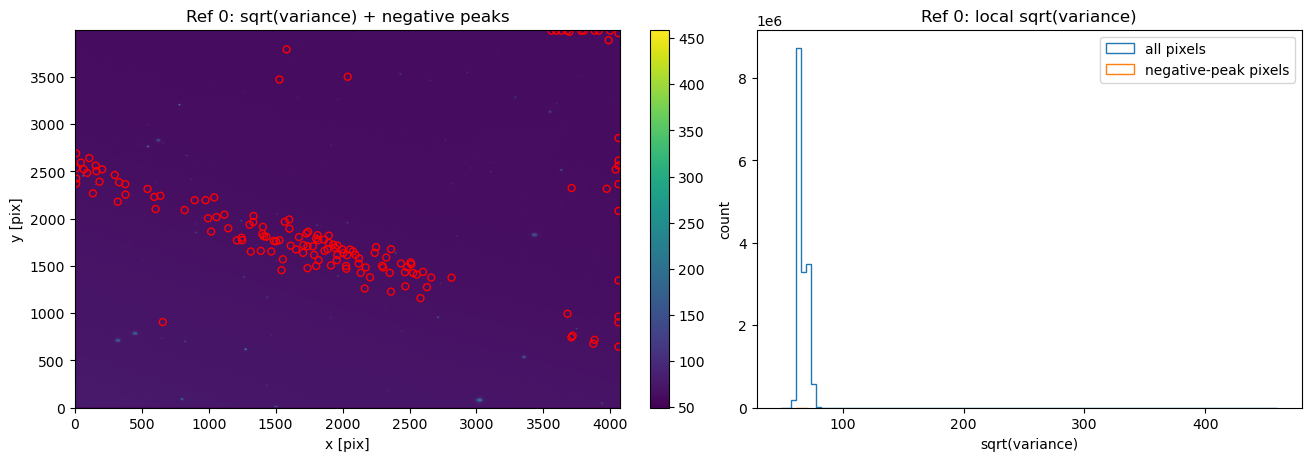

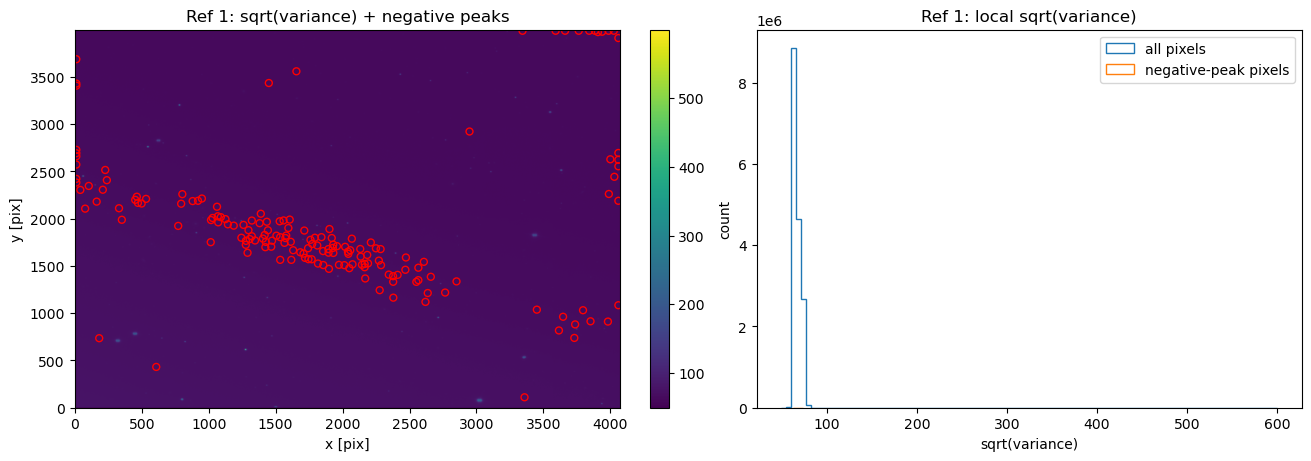

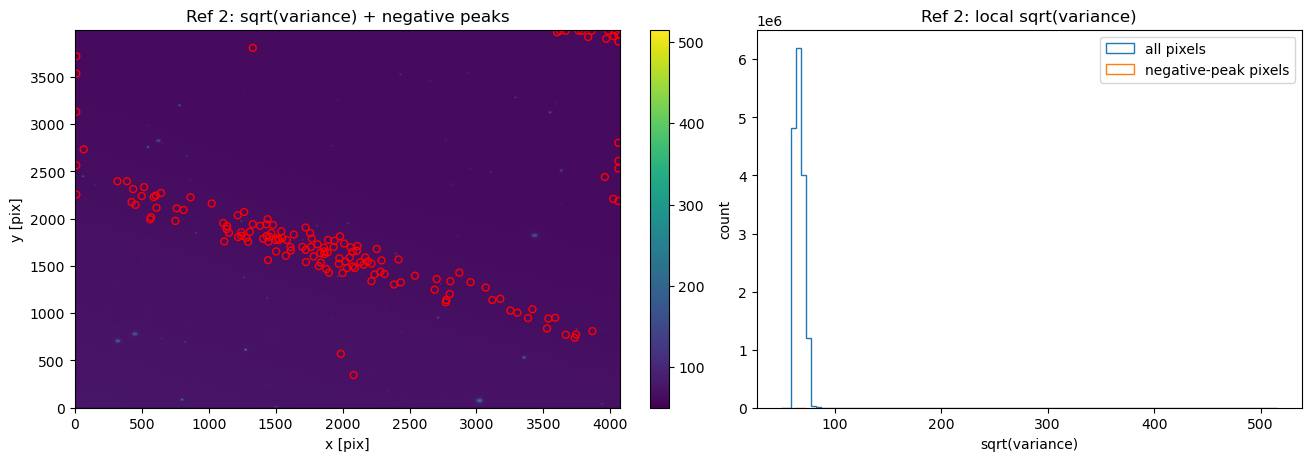


Paste me:
1) Variance-plane summary
2) Count summary
3) Negative-peak / variance summary


In [3]:
import gc
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lsst.daf.butler import Butler
try:
    from lsst.meas.algorithms import SourceDetectionTask, SourceDetectionConfig
except Exception:
    from lsst.meas.algorithms.detection import SourceDetectionTask, SourceDetectionConfig

# =============================================================================
# Settings
# =============================================================================
REPO = "dp2_prep"
COLLECTIONS = "LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2"
WHERE = "instrument='LSSTCam' AND day_obs>=20250801 AND day_obs<=20250921 AND band in ('u','g','r','i','z','y')"

MAX_REFS = 3
THRESHOLDS = [5.0, 4.0, 3.0]
THRESHOLD_TYPES = ["pixel_stdev", "stdev"]

DO_TEMP_LOCAL_BACKGROUND = False
DO_TEMP_WIDE_BACKGROUND = False
RE_ESTIMATE_BACKGROUND = False

# Set to [] for no exclusions, or e.g.
# ["PARTLY_VIGNETTED", "VIGNETTED", "BAD", "SAT", "EDGE", "NO_DATA", "CR", "INTRP", "SUSPECT"]
EXCLUDE_MASK_PLANES = []

PLOT_NEGATIVE_THRESHOLD = 5.0
PLOT_NEGATIVE_THRESHOLD_TYPE = "pixel_stdev"

MAKE_PLOTS = True


# =============================================================================
# Helpers
# =============================================================================
def get_ref_meta(ref, idx=None):
    d = ref.dataId
    return {
        "ref_idx": idx,
        "visit": d["visit"] if "visit" in d else None,
        "detector": d["detector"] if "detector" in d else None,
        "band": d["band"] if "band" in d else None,
        "day_obs": d["day_obs"] if "day_obs" in d else None,
    }

def available_mask_planes(exposure):
    return list(exposure.mask.getMaskPlaneDict().keys())

def existing_mask_planes(exposure, requested):
    avail = set(available_mask_planes(exposure))
    return [p for p in requested if p in avail]

def make_detection_task(threshold, threshold_type, polarity="positive", exclude_mask_planes=None):
    cfg = SourceDetectionConfig()
    cfg.thresholdValue = float(threshold)
    cfg.thresholdType = str(threshold_type)
    cfg.thresholdPolarity = str(polarity)
    cfg.includeThresholdMultiplier = 1.0
    cfg.reEstimateBackground = bool(RE_ESTIMATE_BACKGROUND)
    cfg.doTempLocalBackground = bool(DO_TEMP_LOCAL_BACKGROUND)
    if hasattr(cfg, "doTempWideBackground"):
        cfg.doTempWideBackground = bool(DO_TEMP_WIDE_BACKGROUND)
    cfg.excludeMaskPlanes = list(exclude_mask_planes or [])
    return SourceDetectionTask(config=cfg)

def run_detection(exp, bg, threshold, threshold_type, polarity="positive", exclude_mask_planes=None):
    task = make_detection_task(
        threshold=threshold,
        threshold_type=threshold_type,
        polarity=polarity,
        exclude_mask_planes=exclude_mask_planes,
    )
    return task.detectFootprints(
        exposure=exp,
        doSmooth=True,
        sigma=None,
        clearMask=True,
        expId=None,
        background=bg,
    )

def footprintset_to_list(fp_set):
    if fp_set is None:
        return []
    try:
        return list(fp_set.getFootprints())
    except Exception:
        try:
            return list(fp_set)
        except Exception:
            return []

def best_peak_from_footprint(fp):
    try:
        peaks = list(fp.getPeaks())
    except Exception:
        peaks = []
    if len(peaks) == 0:
        return None

    def peak_value(p):
        for name in ("getPeakValue", "getValue"):
            if hasattr(p, name):
                try:
                    return float(getattr(p, name)())
                except Exception:
                    pass
        return 0.0

    return max(peaks, key=peak_value)

def peak_xy(peak):
    x = None
    y = None
    for name in ("getIx", "getFx", "getX"):
        if hasattr(peak, name):
            x = getattr(peak, name)()
            break
    for name in ("getIy", "getFy", "getY"):
        if hasattr(peak, name):
            y = getattr(peak, name)()
            break
    if x is None or y is None:
        return None
    return int(round(float(x))), int(round(float(y)))

def peak_value(peak):
    if peak is None:
        return np.nan
    for name in ("getPeakValue", "getValue"):
        if hasattr(peak, name):
            try:
                return float(getattr(peak, name)())
            except Exception:
                pass
    return np.nan

def sigma_percentile(valid_sigma_sorted, value):
    if not np.isfinite(value):
        return np.nan
    idx = np.searchsorted(valid_sigma_sorted, value, side="right")
    return 100.0 * idx / len(valid_sigma_sorted)

def maybe_import_psutil():
    try:
        import psutil
        return psutil
    except Exception:
        return None

PSUTIL = maybe_import_psutil()

def print_mem(tag=""):
    if PSUTIL is None:
        return
    proc = PSUTIL.Process(os.getpid())
    rss_gb = proc.memory_info().rss / (1024**3)
    print(f"[mem] {tag} RSS = {rss_gb:.2f} GB")


# =============================================================================
# Run
# =============================================================================
butler = Butler(REPO, collections=COLLECTIONS)
refs = list(
    butler.registry.queryDatasets(
        "preliminary_visit_image",
        instrument="LSSTCam",
        findFirst=True,
        where=WHERE,
    )
)[:MAX_REFS]

print(f"Using {len(refs)} refs")
for i, ref in enumerate(refs):
    print(get_ref_meta(ref, i))

count_rows = []
variance_rows = []
neg_peak_rows = []

for i, ref in enumerate(refs):
    meta = get_ref_meta(ref, i)
    print(f"\n=== Ref {i}: {meta} ===")
    exp = butler.get("preliminary_visit_image", dataId=ref.dataId)
    bg = butler.get("preliminary_visit_image_background", dataId=ref.dataId)

    used_exclude_mask_planes = existing_mask_planes(exp, EXCLUDE_MASK_PLANES)
    print("Available mask planes:", available_mask_planes(exp))
    print("Using excluded mask planes:", used_exclude_mask_planes)

    var = exp.variance.array.astype(np.float64, copy=False)
    sigma_map = np.sqrt(np.where(np.isfinite(var) & (var > 0), var, np.nan))
    valid_sigma = sigma_map[np.isfinite(sigma_map)]
    sigma_sorted = np.sort(valid_sigma)

    variance_rows.append({
        **meta,
        "n_pix": sigma_map.size,
        "n_valid_sigma_pix": int(np.isfinite(sigma_map).sum()),
        "sigma_median": float(np.nanmedian(sigma_map)),
        "sigma_p90": float(np.nanpercentile(sigma_map, 90)),
        "sigma_p95": float(np.nanpercentile(sigma_map, 95)),
        "sigma_p99": float(np.nanpercentile(sigma_map, 99)),
        "sigma_max": float(np.nanmax(sigma_map)),
    })

    h, w = sigma_map.shape

    for tt in THRESHOLD_TYPES:
        for thr in THRESHOLDS:
            for pol in ["positive", "negative"]:
                res = run_detection(
                    exp, bg,
                    threshold=thr,
                    threshold_type=tt,
                    polarity=pol,
                    exclude_mask_planes=used_exclude_mask_planes,
                )
                n = int(res.numPos if pol == "positive" else res.numNeg)
                count_rows.append({
                    **meta,
                    "threshold_type": tt,
                    "threshold": float(thr),
                    "polarity": pol,
                    "count": n,
                    "exclude_mask_planes": ",".join(used_exclude_mask_planes),
                })

                # detailed peak sampling only for one config to keep memory down
                if (tt == PLOT_NEGATIVE_THRESHOLD_TYPE) and (thr == PLOT_NEGATIVE_THRESHOLD) and (pol == "negative"):
                    fps = footprintset_to_list(res.negative)
                    for k, fp in enumerate(fps):
                        pk = best_peak_from_footprint(fp)
                        xy = peak_xy(pk)
                        if xy is None:
                            continue
                        x, y = xy
                        if not (0 <= x < w and 0 <= y < h):
                            continue
                        sig = sigma_map[y, x]
                        neg_peak_rows.append({
                            **meta,
                            "threshold_type": tt,
                            "threshold": float(thr),
                            "peak_index": k,
                            "x": x,
                            "y": y,
                            "peak_value": peak_value(pk),
                            "local_sigma": float(sig) if np.isfinite(sig) else np.nan,
                            "local_sigma_percentile": sigma_percentile(sigma_sorted, sig),
                        })

                del res
                gc.collect()

    del exp, bg, var, sigma_map, valid_sigma, sigma_sorted
    gc.collect()
    print_mem(f"after ref {i}")

count_df = pd.DataFrame(count_rows)
variance_df = pd.DataFrame(variance_rows)
neg_peaks_df = pd.DataFrame(neg_peak_rows)

print("\n=== Variance-plane summary ===")
display(variance_df)

print("\n=== Count summary ===")
count_summary = (
    count_df
    .groupby(["threshold_type", "threshold", "polarity"], dropna=False)
    .agg(
        n_refs=("count", "size"),
        mean_count=("count", "mean"),
        median_count=("count", "median"),
    )
    .reset_index()
    .sort_values(["threshold_type", "polarity", "threshold"], ascending=[True, True, False])
)
display(count_summary)

if len(neg_peaks_df) > 0:
    neg_peak_summary = (
        neg_peaks_df
        .groupby(["threshold_type", "threshold"], dropna=False)
        .agg(
            n_peaks=("peak_index", "size"),
            mean_local_sigma=("local_sigma", "mean"),
            median_local_sigma=("local_sigma", "median"),
            mean_local_sigma_percentile=("local_sigma_percentile", "mean"),
            median_local_sigma_percentile=("local_sigma_percentile", "median"),
            mean_abs_peak_value=("peak_value", lambda s: float(np.nanmean(np.abs(s)))),
        )
        .reset_index()
    )
    print("\n=== Negative-peak / variance summary ===")
    display(neg_peak_summary)

if MAKE_PLOTS and len(neg_peaks_df) > 0:
    for ref_idx in sorted(neg_peaks_df["ref_idx"].unique()):
        ref = refs[ref_idx]
        exp = butler.get("preliminary_visit_image", dataId=ref.dataId)
        var = exp.variance.array.astype(np.float64, copy=False)
        sigma_map = np.sqrt(np.where(np.isfinite(var) & (var > 0), var, np.nan))
        h, w = sigma_map.shape

        sub = neg_peaks_df[neg_peaks_df["ref_idx"] == ref_idx].copy()

        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

        im = axes[0].imshow(sigma_map, origin="lower", aspect="auto")
        axes[0].scatter(sub["x"], sub["y"], s=25, facecolors="none", edgecolors="r")
        axes[0].set_title(f"Ref {ref_idx}: sqrt(variance) + negative peaks")
        axes[0].set_xlabel("x [pix]")
        axes[0].set_ylabel("y [pix]")
        plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

        axes[1].hist(np.ravel(sigma_map[np.isfinite(sigma_map)]), bins=100, histtype="step", label="all pixels")
        axes[1].hist(sub["local_sigma"].dropna(), bins=40, histtype="step", label="negative-peak pixels")
        axes[1].set_title(f"Ref {ref_idx}: local sqrt(variance)")
        axes[1].set_xlabel("sqrt(variance)")
        axes[1].set_ylabel("count")
        axes[1].legend()

        plt.show()

        del exp, var, sigma_map
        gc.collect()

print("\nPaste me:")
print("1) Variance-plane summary")
print("2) Count summary")
print("3) Negative-peak / variance summary")

In [7]:
import gc
import os
import numpy as np
import pandas as pd

from lsst.daf.butler import Butler
from lsst.drp.tasks.single_frame_detect_and_measure import (
    SingleFrameDetectAndMeasureTask,
    SingleFrameDetectAndMeasureConfig,
)

# =============================================================================
# Settings
# =============================================================================
REPO = "dp2_prep"
COLLECTIONS = "LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2"
WHERE = "instrument='LSSTCam' AND day_obs>=20250801 AND day_obs<=20250921 AND band in ('u','g','r','i','z','y')"

MAX_REFS = 1
THRESHOLDS = [5.0]           # after a successful first run, try [5.0, 4.0, 3.0]
THRESHOLD_TYPES = ["pixel_stdev", "stdev"]

DO_TEMP_LOCAL_BACKGROUND = False
DO_TEMP_WIDE_BACKGROUND = False
RE_ESTIMATE_BACKGROUND = False


# =============================================================================
# Helpers
# =============================================================================
def get_ref_meta(ref, idx=None):
    d = ref.dataId
    return {
        "ref_idx": idx,
        "visit": d["visit"] if "visit" in d else None,
        "detector": d["detector"] if "detector" in d else None,
        "band": d["band"] if "band" in d else None,
        "day_obs": d["day_obs"] if "day_obs" in d else None,
    }

def extract_source_catalog(result):
    for attr in ("sources", "outputSources", "sourceCat", "sourceCatalog"):
        if hasattr(result, attr):
            cat = getattr(result, attr)
            if cat is not None:
                return cat
    return None

def get_schema_names(cat):
    if hasattr(cat, "colnames"):
        return list(cat.colnames)
    if hasattr(cat, "schema"):
        try:
            return list(cat.schema.getNames())
        except Exception:
            try:
                return [item.field.getName() for item in cat.schema]
            except Exception:
                pass
    try:
        return list(cat.keys())
    except Exception:
        return []

def safe_flag_value(rec, field_name):
    try:
        return bool(rec[field_name])
    except Exception:
        return False

def make_sfdm_task(threshold, threshold_type, release_id=0):
    cfg = SingleFrameDetectAndMeasureConfig()

    cfg.connections.exposure = "preliminary_visit_image"
    cfg.connections.input_background = "preliminary_visit_image_background"
    cfg.connections.sources = "single_visit_star_reprocessed_unstandardized"
    cfg.connections.sources_footprints = "single_visit_star_reprocessed_footprints"
    cfg.connections.background = "preliminary_visit_image_reprocessed_background"

    cfg.id_generator.release_id = int(release_id)

    cfg.detection.thresholdValue = float(threshold)
    cfg.detection.thresholdType = str(threshold_type)
    cfg.detection.includeThresholdMultiplier = 1.0
    cfg.detection.reEstimateBackground = bool(RE_ESTIMATE_BACKGROUND)
    cfg.detection.doTempLocalBackground = bool(DO_TEMP_LOCAL_BACKGROUND)

    if hasattr(cfg.detection, "doTempWideBackground"):
        cfg.detection.doTempWideBackground = bool(DO_TEMP_WIDE_BACKGROUND)

    cfg.deblend.maxFootprintArea = -1

    return SingleFrameDetectAndMeasureTask(config=cfg)

def maybe_import_psutil():
    try:
        import psutil
        return psutil
    except Exception:
        return None

PSUTIL = maybe_import_psutil()

def print_mem(tag=""):
    if PSUTIL is None:
        return
    proc = PSUTIL.Process(os.getpid())
    rss_gb = proc.memory_info().rss / (1024**3)
    print(f"[mem] {tag} RSS = {rss_gb:.2f} GB")


# =============================================================================
# Run
# =============================================================================
butler = Butler(REPO, collections=COLLECTIONS)
refs = list(
    butler.registry.queryDatasets(
        "preliminary_visit_image",
        instrument="LSSTCam",
        findFirst=True,
        where=WHERE,
    )
)[:MAX_REFS]

print(f"Using {len(refs)} refs")
for i, ref in enumerate(refs):
    print(get_ref_meta(ref, i))

rows = []
errors = []

for i, ref in enumerate(refs):
    meta = get_ref_meta(ref, i)
    exp = butler.get("preliminary_visit_image", dataId=ref.dataId)
    bg = butler.get("preliminary_visit_image_background", dataId=ref.dataId)

    for tt_i, threshold_type in enumerate(THRESHOLD_TYPES):
        for th_i, thr in enumerate(THRESHOLDS):
            release_id = 1000 + 100 * tt_i + th_i
            print(f"\nRunning ref={i}, thresholdType={threshold_type}, threshold={thr}")
            print_mem("before")

            try:
                task = make_sfdm_task(thr, threshold_type, release_id=release_id)
                result = task.run(exposure=exp, input_background=bg)
                cat = extract_source_catalog(result)

                if cat is None:
                    errors.append({**meta, "threshold_type": threshold_type, "threshold": thr, "error": "No source catalog found"})
                    continue

                schema_names = get_schema_names(cat)
                pixel_flag_fields = sorted([n for n in schema_names if n.startswith("base_PixelFlags_")])

                if len(pixel_flag_fields) == 0:
                    rows.append({
                        **meta,
                        "threshold_type": threshold_type,
                        "threshold": thr,
                        "n_sources_total": int(len(cat)),
                        "note": "No base_PixelFlags_* fields found in schema",
                    })
                else:
                    counts = {f: 0 for f in pixel_flag_fields}
                    n_total = 0

                    # aggregate only; do not store per-source rows
                    for rec in cat:
                        n_total += 1
                        for f in pixel_flag_fields:
                            if safe_flag_value(rec, f):
                                counts[f] += 1

                    row = {
                        **meta,
                        "threshold_type": threshold_type,
                        "threshold": thr,
                        "n_sources_total": n_total,
                    }

                    for f in pixel_flag_fields:
                        row[f + "_count"] = counts[f]
                        row[f + "_frac"] = counts[f] / n_total if n_total > 0 else np.nan

                    # Jim's saturated-pixel cuts
                    sat = "base_PixelFlags_saturated"
                    satc = "base_PixelFlags_saturatedCenter"
                    bad = "base_PixelFlags_bad"
                    edge = "base_PixelFlags_edge"
                    interp = "base_PixelFlags_interpolated"
                    interpc = "base_PixelFlags_interpolatedCenter"

                    present = [f for f in [sat, satc, bad, edge, interp, interpc] if f in pixel_flag_fields]

                    n_bad_like = 0
                    for rec in cat:
                        if any(safe_flag_value(rec, f) for f in present):
                            n_bad_like += 1

                    row["n_sources_clean_basic"] = n_total - n_bad_like
                    rows.append(row)

                del task, result, cat
                gc.collect()
                print_mem("after")

            except Exception as e:
                errors.append({
                    **meta,
                    "threshold_type": threshold_type,
                    "threshold": thr,
                    "error": repr(e),
                })

    del exp, bg
    gc.collect()

flag_df = pd.DataFrame(rows)
err_df = pd.DataFrame(errors)

print("\n=== Pixel-flag summary ===")
display(flag_df)

print("\n=== Errors ===")
display(err_df if len(err_df) > 0 else pd.DataFrame({"status": ["no errors recorded"]}))

print("\nPaste me:")
print("1) Pixel-flag summary")
print("2) Errors")

Using 1 refs
{'ref_idx': 0, 'visit': 2025080600341, 'detector': 1, 'band': 'i', 'day_obs': 20250806}

Running ref=0, thresholdType=pixel_stdev, threshold=5.0
[mem] before RSS = 1.04 GB


[mem] after RSS = 1.00 GB

Running ref=0, thresholdType=stdev, threshold=5.0
[mem] before RSS = 1.00 GB


[mem] after RSS = 1.00 GB

=== Pixel-flag summary ===


,ref_idx,visit,detector,band,day_obs,threshold_type,threshold,n_sources_total,base_PixelFlags_flag_count,base_PixelFlags_flag_frac,...,base_PixelFlags_flag_saturatedCenter_frac,base_PixelFlags_flag_saturatedCenterAll_count,base_PixelFlags_flag_saturatedCenterAll_frac,base_PixelFlags_flag_suspect_count,base_PixelFlags_flag_suspect_frac,base_PixelFlags_flag_suspectCenter_count,base_PixelFlags_flag_suspectCenter_frac,base_PixelFlags_flag_suspectCenterAll_count,base_PixelFlags_flag_suspectCenterAll_frac,n_sources_clean_basic
0,0,2025080600341,1,i,20250806,pixel_stdev,5.0,2030,0,0.0,...,0.012808,26,0.012808,31,0.015271,23,0.011330,0,0.0,2030
1,0,2025080600341,1,i,20250806,stdev,5.0,1486,0,0.0,...,0.017497,26,0.017497,29,0.019515,24,0.016151,0,0.0,1486



=== Errors ===


,status
0,no errors recorded



Paste me:
1) Pixel-flag summary
2) Errors


In [6]:
from lsst.daf.butler import Butler
from lsst.drp.tasks.single_frame_detect_and_measure import (
    SingleFrameDetectAndMeasureTask,
    SingleFrameDetectAndMeasureConfig,
)

REPO = "dp2_prep"
COLLECTIONS = "LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2"
WHERE = "instrument='LSSTCam' AND day_obs>=20250801 AND day_obs<=20250921 AND band in ('u','g','r','i','z','y')"

def extract_source_catalog(result):
    for attr in ("sources", "outputSources", "sourceCat", "sourceCatalog"):
        if hasattr(result, attr):
            cat = getattr(result, attr)
            if cat is not None:
                return cat
    return None

def get_column_names(cat):
    # astropy Table
    if hasattr(cat, "colnames"):
        return list(cat.colnames)

    # LSST SourceCatalog / afw table-like
    if hasattr(cat, "schema"):
        try:
            return list(cat.schema.getNames())
        except Exception:
            try:
                return [item.field.getName() for item in cat.schema]
            except Exception:
                pass

    # fallback
    try:
        return list(cat.keys())
    except Exception:
        return []

butler = Butler(REPO, collections=COLLECTIONS)
ref = list(
    butler.registry.queryDatasets(
        "preliminary_visit_image",
        instrument="LSSTCam",
        findFirst=True,
        where=WHERE,
    )
)[0]

exp = butler.get("preliminary_visit_image", dataId=ref.dataId)
bg = butler.get("preliminary_visit_image_background", dataId=ref.dataId)

cfg = SingleFrameDetectAndMeasureConfig()
cfg.connections.exposure = "preliminary_visit_image"
cfg.connections.input_background = "preliminary_visit_image_background"
cfg.connections.sources = "single_visit_star_reprocessed_unstandardized"
cfg.connections.sources_footprints = "single_visit_star_reprocessed_footprints"
cfg.connections.background = "preliminary_visit_image_reprocessed_background"

cfg.id_generator.release_id = 999
cfg.detection.thresholdValue = 5.0
cfg.detection.thresholdType = "pixel_stdev"
cfg.detection.includeThresholdMultiplier = 1.0
cfg.detection.reEstimateBackground = False
cfg.detection.doTempLocalBackground = False
if hasattr(cfg.detection, "doTempWideBackground"):
    cfg.detection.doTempWideBackground = False
cfg.deblend.maxFootprintArea = -1

task = SingleFrameDetectAndMeasureTask(config=cfg)
result = task.run(exposure=exp, input_background=bg)
cat = extract_source_catalog(result)

print("Catalog type:", type(cat))
names = get_column_names(cat)

interesting = [
    n for n in names
    if ("flag" in n.lower()) or ("sat" in n.lower()) or ("pixel" in n.lower()) or ("mask" in n.lower())
]

print(f"Total columns/fields: {len(names)}")
print("\nInteresting columns/fields:")
for n in sorted(interesting):
    print(n)

print("\nFirst 50 columns/fields:")
for n in names[:50]:
    print(n)

Catalog type: <class 'astropy.table.table.Table'>
Total columns/fields: 420

Interesting columns/fields:
base_CircularApertureFlux_12_0_flag
base_CircularApertureFlux_12_0_flag_apertureTruncated
base_CircularApertureFlux_12_0_flag_sincCoeffsTruncated
base_CircularApertureFlux_17_0_flag
base_CircularApertureFlux_17_0_flag_apertureTruncated
base_CircularApertureFlux_25_0_flag
base_CircularApertureFlux_25_0_flag_apertureTruncated
base_CircularApertureFlux_35_0_flag
base_CircularApertureFlux_35_0_flag_apertureTruncated
base_CircularApertureFlux_3_0_flag
base_CircularApertureFlux_3_0_flag_apertureTruncated
base_CircularApertureFlux_3_0_flag_sincCoeffsTruncated
base_CircularApertureFlux_4_5_flag
base_CircularApertureFlux_4_5_flag_apertureTruncated
base_CircularApertureFlux_4_5_flag_sincCoeffsTruncated
base_CircularApertureFlux_50_0_flag
base_CircularApertureFlux_50_0_flag_apertureTruncated
base_CircularApertureFlux_6_0_flag
base_CircularApertureFlux_6_0_flag_apertureTruncated
base_CircularAp

In [9]:
import gc
import os
import numpy as np
import pandas as pd

from lsst.daf.butler import Butler
from lsst.drp.tasks.single_frame_detect_and_measure import (
    SingleFrameDetectAndMeasureTask,
    SingleFrameDetectAndMeasureConfig,
)

# =============================================================================
# Settings
# =============================================================================
REPO = "dp2_prep"
COLLECTIONS = "LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2"
WHERE = "instrument='LSSTCam' AND day_obs>=20250801 AND day_obs<=20250921 AND band in ('u','g','r','i','z','y')"

MAX_REFS = 1
THRESHOLDS = [5.0]   # after success, try [5.0, 4.0, 3.0]
THRESHOLD_TYPES = ["pixel_stdev", "stdev"]

DO_TEMP_LOCAL_BACKGROUND = False
DO_TEMP_WIDE_BACKGROUND = False
RE_ESTIMATE_BACKGROUND = False


# =============================================================================
# Helpers
# =============================================================================
def get_ref_meta(ref, idx=None):
    d = ref.dataId
    return {
        "ref_idx": idx,
        "visit": d["visit"] if "visit" in d else None,
        "detector": d["detector"] if "detector" in d else None,
        "band": d["band"] if "band" in d else None,
        "day_obs": d["day_obs"] if "day_obs" in d else None,
    }

def extract_source_catalog(result):
    for attr in ("sources", "outputSources", "sourceCat", "sourceCatalog"):
        if hasattr(result, attr):
            cat = getattr(result, attr)
            if cat is not None:
                return cat
    return None

def get_column_names(cat):
    if hasattr(cat, "colnames"):
        return list(cat.colnames)
    if hasattr(cat, "schema"):
        try:
            return list(cat.schema.getNames())
        except Exception:
            try:
                return [item.field.getName() for item in cat.schema]
            except Exception:
                pass
    try:
        return list(cat.keys())
    except Exception:
        return []

def safe_flag_value(rec, field_name):
    try:
        return bool(rec[field_name])
    except Exception:
        return False

def make_sfdm_task(threshold, threshold_type, release_id=0):
    cfg = SingleFrameDetectAndMeasureConfig()

    cfg.connections.exposure = "preliminary_visit_image"
    cfg.connections.input_background = "preliminary_visit_image_background"
    cfg.connections.sources = "single_visit_star_reprocessed_unstandardized"
    cfg.connections.sources_footprints = "single_visit_star_reprocessed_footprints"
    cfg.connections.background = "preliminary_visit_image_reprocessed_background"

    cfg.id_generator.release_id = int(release_id)

    cfg.detection.thresholdValue = float(threshold)
    cfg.detection.thresholdType = str(threshold_type)
    cfg.detection.includeThresholdMultiplier = 1.0
    cfg.detection.reEstimateBackground = bool(RE_ESTIMATE_BACKGROUND)
    cfg.detection.doTempLocalBackground = bool(DO_TEMP_LOCAL_BACKGROUND)

    if hasattr(cfg.detection, "doTempWideBackground"):
        cfg.detection.doTempWideBackground = bool(DO_TEMP_WIDE_BACKGROUND)

    cfg.deblend.maxFootprintArea = -1
    return SingleFrameDetectAndMeasureTask(config=cfg)

def maybe_import_psutil():
    try:
        import psutil
        return psutil
    except Exception:
        return None

PSUTIL = maybe_import_psutil()

def print_mem(tag=""):
    if PSUTIL is None:
        return
    proc = PSUTIL.Process(os.getpid())
    rss_gb = proc.memory_info().rss / (1024**3)
    print(f"[mem] {tag} RSS = {rss_gb:.2f} GB")


# =============================================================================
# Run
# =============================================================================
butler = Butler(REPO, collections=COLLECTIONS)
refs = list(
    butler.registry.queryDatasets(
        "preliminary_visit_image",
        instrument="LSSTCam",
        findFirst=True,
        where=WHERE,
    )
)[:MAX_REFS]

rows = []
errors = []

for i, ref in enumerate(refs):
    meta = get_ref_meta(ref, i)
    print(meta)

    exp = butler.get("preliminary_visit_image", dataId=ref.dataId)
    bg = butler.get("preliminary_visit_image_background", dataId=ref.dataId)

    for tt_i, threshold_type in enumerate(THRESHOLD_TYPES):
        for th_i, thr in enumerate(THRESHOLDS):
            print(f"\nRunning ref={i}, thresholdType={threshold_type}, threshold={thr}")
            print_mem("before")

            try:
                task = make_sfdm_task(thr, threshold_type, release_id=1000 + 100 * tt_i + th_i)
                result = task.run(exposure=exp, input_background=bg)
                cat = extract_source_catalog(result)

                if cat is None:
                    errors.append({**meta, "threshold_type": threshold_type, "threshold": thr, "error": "No source catalog found"})
                    continue

                names = get_column_names(cat)

                wanted = [
                    "base_PixelFlags_flag",
                    "base_PixelFlags_flag_bad",
                    "base_PixelFlags_flag_badCenter",
                    "base_PixelFlags_flag_badCenterAll",
                    "base_PixelFlags_flag_cr",
                    "base_PixelFlags_flag_crCenter",
                    "base_PixelFlags_flag_crCenterAll",
                    "base_PixelFlags_flag_edge",
                    "base_PixelFlags_flag_edgeCenter",
                    "base_PixelFlags_flag_edgeCenterAll",
                    "base_PixelFlags_flag_interpolated",
                    "base_PixelFlags_flag_interpolatedCenter",
                    "base_PixelFlags_flag_interpolatedCenterAll",
                    "base_PixelFlags_flag_nodata",
                    "base_PixelFlags_flag_nodataCenter",
                    "base_PixelFlags_flag_nodataCenterAll",
                    "base_PixelFlags_flag_offimage",
                    "base_PixelFlags_flag_saturated",
                    "base_PixelFlags_flag_saturatedCenter",
                    "base_PixelFlags_flag_saturatedCenterAll",
                    "base_PixelFlags_flag_suspect",
                    "base_PixelFlags_flag_suspectCenter",
                    "base_PixelFlags_flag_suspectCenterAll",
                ]
                present = [x for x in wanted if x in names]

                row = {
                    **meta,
                    "threshold_type": threshold_type,
                    "threshold": thr,
                    "n_sources_total": int(len(cat)),
                }

                counts = {f: 0 for f in present}
                n_clean_basic = 0
                n_clean_sat = 0

                basic_bad_fields = [
                    "base_PixelFlags_flag_bad",
                    "base_PixelFlags_flag_edge",
                    "base_PixelFlags_flag_interpolated",
                    "base_PixelFlags_flag_interpolatedCenter",
                    "base_PixelFlags_flag_nodata",
                    "base_PixelFlags_flag_cr",
                    "base_PixelFlags_flag_saturated",
                    "base_PixelFlags_flag_saturatedCenter",
                    "base_PixelFlags_flag_suspect",
                ]
                basic_bad_fields = [f for f in basic_bad_fields if f in present]

                sat_fields = [
                    "base_PixelFlags_flag_saturated",
                    "base_PixelFlags_flag_saturatedCenter",
                    "base_PixelFlags_flag_saturatedCenterAll",
                ]
                sat_fields = [f for f in sat_fields if f in present]

                for rec in cat:
                    for f in present:
                        if safe_flag_value(rec, f):
                            counts[f] += 1

                    if not any(safe_flag_value(rec, f) for f in basic_bad_fields):
                        n_clean_basic += 1

                    if not any(safe_flag_value(rec, f) for f in sat_fields):
                        n_clean_sat += 1

                for f in present:
                    row[f + "_count"] = counts[f]
                    row[f + "_frac"] = counts[f] / len(cat) if len(cat) > 0 else np.nan

                row["n_sources_clean_basic"] = n_clean_basic
                row["frac_sources_clean_basic"] = n_clean_basic / len(cat) if len(cat) > 0 else np.nan
                row["n_sources_clean_sat"] = n_clean_sat
                row["frac_sources_clean_sat"] = n_clean_sat / len(cat) if len(cat) > 0 else np.nan

                rows.append(row)

                del task, result, cat
                gc.collect()
                print_mem("after")

            except Exception as e:
                errors.append({
                    **meta,
                    "threshold_type": threshold_type,
                    "threshold": thr,
                    "error": repr(e),
                })

    del exp, bg
    gc.collect()

flag_df = pd.DataFrame(rows)
err_df = pd.DataFrame(errors)

print("\n=== Corrected pixel-flag summary ===")
display(flag_df)

print("\n=== Errors ===")
display(err_df if len(err_df) > 0 else pd.DataFrame({"status": ["no errors recorded"]}))

{'ref_idx': 0, 'visit': 2025080600341, 'detector': 1, 'band': 'i', 'day_obs': 20250806}

Running ref=0, thresholdType=pixel_stdev, threshold=5.0
[mem] before RSS = 1.02 GB


[mem] after RSS = 1.00 GB

Running ref=0, thresholdType=stdev, threshold=5.0
[mem] before RSS = 1.00 GB


[mem] after RSS = 1.00 GB

=== Corrected pixel-flag summary ===


,ref_idx,visit,detector,band,day_obs,threshold_type,threshold,n_sources_total,base_PixelFlags_flag_count,base_PixelFlags_flag_frac,...,base_PixelFlags_flag_suspect_count,base_PixelFlags_flag_suspect_frac,base_PixelFlags_flag_suspectCenter_count,base_PixelFlags_flag_suspectCenter_frac,base_PixelFlags_flag_suspectCenterAll_count,base_PixelFlags_flag_suspectCenterAll_frac,n_sources_clean_basic,frac_sources_clean_basic,n_sources_clean_sat,frac_sources_clean_sat
0,0,2025080600341,1,i,20250806,pixel_stdev,5.0,2030,0,0.0,...,31,0.015271,23,0.011330,0,0.0,1863,0.917734,1998,0.984236
1,0,2025080600341,1,i,20250806,stdev,5.0,1486,0,0.0,...,29,0.019515,24,0.016151,0,0.0,1353,0.910498,1457,0.980485



=== Errors ===


,status
0,no errors recorded


In [10]:
import numpy as np
import pandas as pd

from lsst.daf.butler import Butler
try:
    from lsst.meas.algorithms import SourceDetectionTask, SourceDetectionConfig
except Exception:
    from lsst.meas.algorithms.detection import SourceDetectionTask, SourceDetectionConfig

# =============================================================================
# Settings
# =============================================================================
REPO = "dp2_prep"
COLLECTIONS = "LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2"
WHERE = "instrument='LSSTCam' AND day_obs>=20250801 AND day_obs<=20250921 AND band in ('u','g','r','i','z','y')"

MAX_REFS = 3
THRESHOLD = 5.0
THRESHOLD_TYPES = ["pixel_stdev", "stdev"]
SAT_RADIUS = 20

# =============================================================================
# Helpers
# =============================================================================
def get_ref_meta(ref, idx=None):
    d = ref.dataId
    return {
        "ref_idx": idx,
        "visit": d["visit"] if "visit" in d else None,
        "detector": d["detector"] if "detector" in d else None,
        "band": d["band"] if "band" in d else None,
        "day_obs": d["day_obs"] if "day_obs" in d else None,
    }

def make_detection_task(threshold, threshold_type, polarity="negative"):
    cfg = SourceDetectionConfig()
    cfg.thresholdValue = float(threshold)
    cfg.thresholdType = str(threshold_type)
    cfg.thresholdPolarity = str(polarity)
    cfg.includeThresholdMultiplier = 1.0
    cfg.reEstimateBackground = False
    cfg.doTempLocalBackground = False
    if hasattr(cfg, "doTempWideBackground"):
        cfg.doTempWideBackground = False
    return SourceDetectionTask(config=cfg)

def footprintset_to_list(fp_set):
    if fp_set is None:
        return []
    try:
        return list(fp_set.getFootprints())
    except Exception:
        return list(fp_set)

def best_peak_from_footprint(fp):
    try:
        peaks = list(fp.getPeaks())
    except Exception:
        peaks = []
    if len(peaks) == 0:
        return None

    def peak_value(p):
        for name in ("getPeakValue", "getValue"):
            if hasattr(p, name):
                try:
                    return float(getattr(p, name)())
                except Exception:
                    pass
        return 0.0

    return max(peaks, key=peak_value)

def peak_xy(peak):
    if peak is None:
        return None
    x = y = None
    for name in ("getIx", "getFx", "getX"):
        if hasattr(peak, name):
            x = getattr(peak, name)()
            break
    for name in ("getIy", "getFy", "getY"):
        if hasattr(peak, name):
            y = getattr(peak, name)()
            break
    if x is None or y is None:
        return None
    return int(round(float(x))), int(round(float(y)))

def disk_offsets(radius):
    rr = int(radius)
    yy, xx = np.mgrid[-rr:rr+1, -rr:rr+1]
    keep = (xx*xx + yy*yy) <= rr*rr
    return yy[keep], xx[keep]

def dilate_mask(mask, radius):
    dy, dx = disk_offsets(radius)
    out = np.zeros_like(mask, dtype=bool)
    ys, xs = np.where(mask)
    h, w = mask.shape
    for y0, x0 in zip(ys, xs):
        yy = y0 + dy
        xx = x0 + dx
        keep = (yy >= 0) & (yy < h) & (xx >= 0) & (xx < w)
        out[yy[keep], xx[keep]] = True
    return out

# =============================================================================
# Run
# =============================================================================
butler = Butler(REPO, collections=COLLECTIONS)
refs = list(
    butler.registry.queryDatasets(
        "preliminary_visit_image",
        instrument="LSSTCam",
        findFirst=True,
        where=WHERE,
    )
)[:MAX_REFS]

rows = []

for i, ref in enumerate(refs):
    meta = get_ref_meta(ref, i)
    exp = butler.get("preliminary_visit_image", dataId=ref.dataId)
    bg = butler.get("preliminary_visit_image_background", dataId=ref.dataId)

    mask_dict = exp.mask.getMaskPlaneDict()
    if "SAT" not in mask_dict:
        print(f"Ref {i}: no SAT mask plane")
        continue

    sat_bit = 1 << mask_dict["SAT"]
    sat_mask = (exp.mask.array & sat_bit) != 0
    sat_near_mask = dilate_mask(sat_mask, SAT_RADIUS)

    print(f"Ref {i}: SAT frac={sat_mask.mean():.6e}, near-SAT frac={sat_near_mask.mean():.6e}")

    for tt in THRESHOLD_TYPES:
        task = make_detection_task(THRESHOLD, tt, polarity="negative")
        res = task.detectFootprints(
            exposure=exp,
            doSmooth=True,
            sigma=None,
            clearMask=True,
            expId=None,
            background=bg,
        )
        fps = footprintset_to_list(res.negative)

        n_total = 0
        n_on_sat = 0
        n_near_sat = 0
        n_far_sat = 0

        for fp in fps:
            pk = best_peak_from_footprint(fp)
            xy = peak_xy(pk)
            if xy is None:
                continue
            x, y = xy
            if not (0 <= x < sat_mask.shape[1] and 0 <= y < sat_mask.shape[0]):
                continue

            n_total += 1
            on_sat = bool(sat_mask[y, x])
            near_sat = bool(sat_near_mask[y, x])

            if on_sat:
                n_on_sat += 1
            if near_sat:
                n_near_sat += 1
            else:
                n_far_sat += 1

        rows.append({
            **meta,
            "threshold_type": tt,
            "threshold": THRESHOLD,
            "n_negative_total": n_total,
            "n_negative_on_SAT": n_on_sat,
            "n_negative_near_SAT": n_near_sat,
            "n_negative_far_from_SAT": n_far_sat,
            "frac_negative_on_SAT": n_on_sat / n_total if n_total else np.nan,
            "frac_negative_near_SAT": n_near_sat / n_total if n_total else np.nan,
            "frac_negative_far_from_SAT": n_far_sat / n_total if n_total else np.nan,
        })

sat_df = pd.DataFrame(rows)

print("\n=== SAT proximity summary ===")
display(sat_df)

print("\n=== Mean SAT proximity summary ===")
display(
    sat_df.groupby("threshold_type", dropna=False)
    .agg(
        mean_n_negative_total=("n_negative_total", "mean"),
        mean_frac_negative_on_SAT=("frac_negative_on_SAT", "mean"),
        mean_frac_negative_near_SAT=("frac_negative_near_SAT", "mean"),
        mean_frac_negative_far_from_SAT=("frac_negative_far_from_SAT", "mean"),
    )
    .reset_index()
)

Ref 0: SAT frac=5.117878e-04, near-SAT frac=2.886604e-03


Ref 1: SAT frac=4.884578e-04, near-SAT frac=2.670432e-03


Ref 2: SAT frac=4.697937e-04, near-SAT frac=2.580673e-03



=== SAT proximity summary ===


,ref_idx,visit,detector,band,day_obs,threshold_type,threshold,n_negative_total,n_negative_on_SAT,n_negative_near_SAT,n_negative_far_from_SAT,frac_negative_on_SAT,frac_negative_near_SAT,frac_negative_far_from_SAT
0,0,2025080600341,1,i,20250806,pixel_stdev,5.0,147,0,0,147,0.0,0.0,1.0
1,0,2025080600341,1,i,20250806,stdev,5.0,0,0,0,0,NaN,NaN,NaN
2,1,2025080600342,1,i,20250806,pixel_stdev,5.0,168,0,0,168,0.0,0.0,1.0
3,1,2025080600342,1,i,20250806,stdev,5.0,2,0,0,2,0.0,0.0,1.0
4,2,2025080600343,1,i,20250806,pixel_stdev,5.0,153,0,0,153,0.0,0.0,1.0
5,2,2025080600343,1,i,20250806,stdev,5.0,2,0,0,2,0.0,0.0,1.0



=== Mean SAT proximity summary ===


,threshold_type,mean_n_negative_total,mean_frac_negative_on_SAT,mean_frac_negative_near_SAT,mean_frac_negative_far_from_SAT
0,pixel_stdev,156.000000,0.0,0.0,1.0
1,stdev,1.333333,0.0,0.0,1.0


Using 3 refs
{'ref_idx': 0, 'visit': 2025080600341, 'detector': 1, 'band': 'i', 'day_obs': 20250806}
{'ref_idx': 1, 'visit': 2025080600342, 'detector': 1, 'band': 'i', 'day_obs': 20250806}
{'ref_idx': 2, 'visit': 2025080600343, 'detector': 1, 'band': 'i', 'day_obs': 20250806}

=== Ref 0: {'ref_idx': 0, 'visit': 2025080600341, 'detector': 1, 'band': 'i', 'day_obs': 20250806} ===
Available mask planes: ['BAD', 'CR', 'CROSSTALK', 'DETECTED', 'DETECTED_NEGATIVE', 'EDGE', 'INTRP', 'ITL_DIP', 'NOT_DEBLENDED', 'NO_DATA', 'PARTLY_VIGNETTED', 'SAT', 'SPIKE', 'STREAK', 'SUSPECT', 'UNMASKEDNAN', 'VIGNETTED']
Using old_exclude: ['BAD', 'SAT', 'EDGE', 'NO_DATA', 'CR']
Using broad_exclude: ['BAD', 'SAT', 'EDGE', 'NO_DATA', 'CR', 'PARTLY_VIGNETTED', 'VIGNETTED', 'INTRP', 'SUSPECT', 'SPIKE', 'STREAK']


/tmp/ipykernel_58/3754435472.py:177: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  frac = plane_strings.str.contains(fr"(^|,){plane}(,|$)", regex=True).mean()



=== Ref 1: {'ref_idx': 1, 'visit': 2025080600342, 'detector': 1, 'band': 'i', 'day_obs': 20250806} ===
Available mask planes: ['BAD', 'CR', 'CROSSTALK', 'DETECTED', 'DETECTED_NEGATIVE', 'EDGE', 'INTRP', 'ITL_DIP', 'NOT_DEBLENDED', 'NO_DATA', 'PARTLY_VIGNETTED', 'SAT', 'SPIKE', 'STREAK', 'SUSPECT', 'UNMASKEDNAN', 'VIGNETTED']
Using old_exclude: ['BAD', 'SAT', 'EDGE', 'NO_DATA', 'CR']
Using broad_exclude: ['BAD', 'SAT', 'EDGE', 'NO_DATA', 'CR', 'PARTLY_VIGNETTED', 'VIGNETTED', 'INTRP', 'SUSPECT', 'SPIKE', 'STREAK']


/tmp/ipykernel_58/3754435472.py:177: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  frac = plane_strings.str.contains(fr"(^|,){plane}(,|$)", regex=True).mean()


/tmp/ipykernel_58/3754435472.py:177: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  frac = plane_strings.str.contains(fr"(^|,){plane}(,|$)", regex=True).mean()


...

,threshold_type,config_tag,n_refs,mean_negative_count,median_negative_count,mean_positive_count,median_positive_count
0,pixel_stdev,baseline,3,156.000000,153.0,1296.666667,1304.0
1,pixel_stdev,broad_exclude,3,8.000000,8.0,445.000000,440.0
2,pixel_stdev,old_exclude,3,132.666667,132.0,1258.333333,1269.0
3,stdev,baseline,3,1.333333,2.0,980.000000,963.0
4,stdev,broad_exclude,3,8.000000,8.0,7.333333,7.0
5,stdev,old_exclude,3,0.000000,0.0,956.000000,943.0



=== Negative-count comparison ===


config_tag,threshold_type,baseline,broad_exclude,old_exclude,frac_remaining_old_vs_baseline,frac_remaining_broad_vs_baseline,frac_removed_broad_vs_baseline
0,pixel_stdev,156.000000,8.0,132.666667,0.850427,0.051282,0.948718
1,stdev,1.333333,8.0,0.000000,0.000000,6.000000,-5.000000



=== Baseline negative-peak mask-plane summary ===


,ref_idx,visit,detector,threshold_type,mask_plane,fraction_of_negative_peaks_on_plane,n_negative_peaks
17,1,2025080600342,1,pixel_stdev,PARTLY_VIGNETTED,0.869048,168
51,2,2025080600343,1,pixel_stdev,PARTLY_VIGNETTED,0.862745,153
0,0,2025080600341,1,pixel_stdev,PARTLY_VIGNETTED,0.843537,147
1,0,2025080600341,1,pixel_stdev,BAD,0.013605,147
2,0,2025080600341,1,pixel_stdev,INTRP,0.013605,147
18,1,2025080600342,1,pixel_stdev,BAD,0.011905,168
19,1,2025080600342,1,pixel_stdev,CROSSTALK,0.011905,168
20,1,2025080600342,1,pixel_stdev,INTRP,0.011905,168
3,0,2025080600341,1,pixel_stdev,CROSSTALK,0.006803,147
52,2,2025080600343,1,pixel_stdev,BAD,0.006536,153


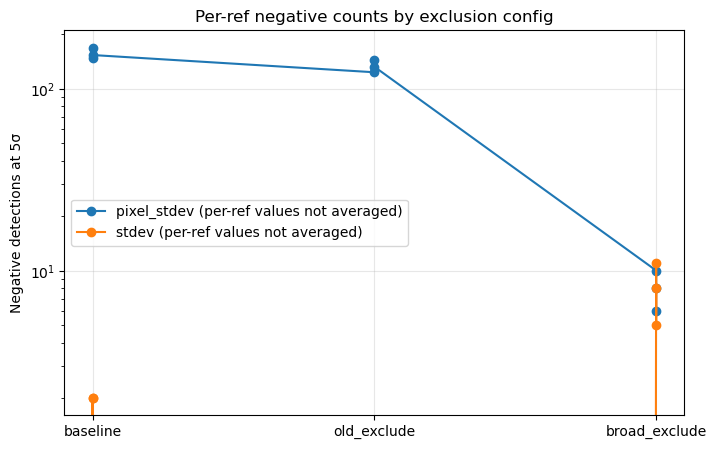

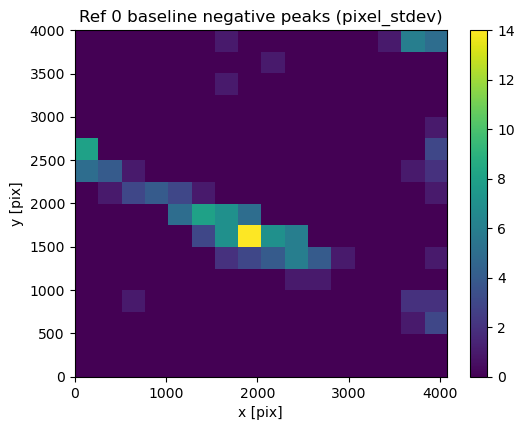

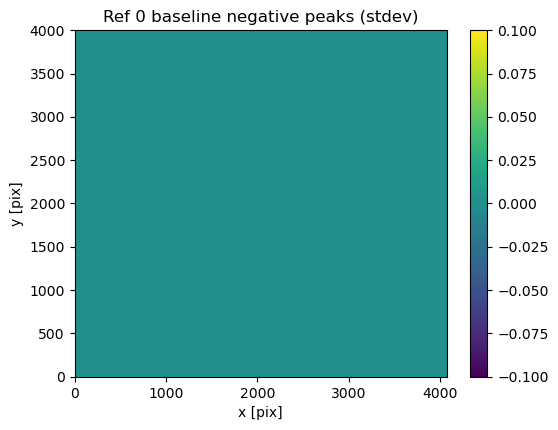


Paste me:
1) Summary table
2) Negative-count comparison
3) Baseline negative-peak mask-plane summary


In [11]:
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lsst.daf.butler import Butler
try:
    from lsst.meas.algorithms import SourceDetectionTask, SourceDetectionConfig
except Exception:
    from lsst.meas.algorithms.detection import SourceDetectionTask, SourceDetectionConfig

# =============================================================================
# Settings
# =============================================================================
REPO = "dp2_prep"
COLLECTIONS = "LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2"
WHERE = "instrument='LSSTCam' AND day_obs>=20250801 AND day_obs<=20250921 AND band in ('u','g','r','i','z','y')"

MAX_REFS = 3
THRESHOLD = 5.0
THRESHOLD_TYPES = ["pixel_stdev", "stdev"]

DO_TEMP_LOCAL_BACKGROUND = False
DO_TEMP_WIDE_BACKGROUND = False
RE_ESTIMATE_BACKGROUND = False

OLD_EXCLUDE = [
    "BAD", "SAT", "EDGE", "NO_DATA", "CR"
]

BROAD_EXCLUDE = [
    "BAD", "SAT", "EDGE", "NO_DATA", "CR",
    "PARTLY_VIGNETTED", "VIGNETTED",
    "INTRP", "SUSPECT",
    "SPIKE", "STREAK"
]

MAKE_PLOTS = True
PLOT_REF_INDEX = 0   # spatial plots for this ref only


# =============================================================================
# Helpers
# =============================================================================
def get_ref_meta(ref, idx=None):
    d = ref.dataId
    return {
        "ref_idx": idx,
        "visit": d["visit"] if "visit" in d else None,
        "detector": d["detector"] if "detector" in d else None,
        "band": d["band"] if "band" in d else None,
        "day_obs": d["day_obs"] if "day_obs" in d else None,
    }

def available_mask_planes(exposure):
    return list(exposure.mask.getMaskPlaneDict().keys())

def keep_existing_mask_planes(exposure, requested):
    avail = set(available_mask_planes(exposure))
    return [p for p in requested if p in avail]

def make_detection_task(threshold, threshold_type, polarity="negative", exclude_mask_planes=None):
    cfg = SourceDetectionConfig()
    cfg.thresholdValue = float(threshold)
    cfg.thresholdType = str(threshold_type)
    cfg.thresholdPolarity = str(polarity)
    cfg.includeThresholdMultiplier = 1.0
    cfg.reEstimateBackground = bool(RE_ESTIMATE_BACKGROUND)
    cfg.doTempLocalBackground = bool(DO_TEMP_LOCAL_BACKGROUND)
    if hasattr(cfg, "doTempWideBackground"):
        cfg.doTempWideBackground = bool(DO_TEMP_WIDE_BACKGROUND)
    cfg.excludeMaskPlanes = list(exclude_mask_planes or [])
    return SourceDetectionTask(config=cfg)

def run_detection(exp, bg, threshold, threshold_type, polarity="negative", exclude_mask_planes=None):
    task = make_detection_task(
        threshold=threshold,
        threshold_type=threshold_type,
        polarity=polarity,
        exclude_mask_planes=exclude_mask_planes,
    )
    return task.detectFootprints(
        exposure=exp,
        doSmooth=True,
        sigma=None,
        clearMask=True,
        expId=None,
        background=bg,
    )

def footprintset_to_list(fp_set):
    if fp_set is None:
        return []
    try:
        return list(fp_set.getFootprints())
    except Exception:
        try:
            return list(fp_set)
        except Exception:
            return []

def best_peak_from_footprint(fp):
    try:
        peaks = list(fp.getPeaks())
    except Exception:
        peaks = []
    if len(peaks) == 0:
        return None

    def peak_value(p):
        for name in ("getPeakValue", "getValue"):
            if hasattr(p, name):
                try:
                    return float(getattr(p, name)())
                except Exception:
                    pass
        return 0.0

    return max(peaks, key=peak_value)

def peak_xy(peak):
    if peak is None:
        return None
    x = y = None
    for name in ("getIx", "getFx", "getX"):
        if hasattr(peak, name):
            x = getattr(peak, name)()
            break
    for name in ("getIy", "getFy", "getY"):
        if hasattr(peak, name):
            y = getattr(peak, name)()
            break
    if x is None or y is None:
        return None
    return int(round(float(x))), int(round(float(y)))

def make_peak_mask_flags_df(exposure, footprints, ref_meta, threshold_type, config_tag):
    mask = exposure.mask
    mask_plane_dict = mask.getMaskPlaneDict()
    h, w = exposure.image.array.shape

    rows = []
    for i, fp in enumerate(footprints):
        pk = best_peak_from_footprint(fp)
        xy = peak_xy(pk)
        if xy is None:
            continue
        x, y = xy
        if not (0 <= x < w and 0 <= y < h):
            continue

        mask_val = int(mask.array[y, x])
        flags_here = []
        for name, bit in mask_plane_dict.items():
            if mask_val & (1 << bit):
                flags_here.append(name)

        rows.append({
            **ref_meta,
            "threshold_type": threshold_type,
            "config_tag": config_tag,
            "peak_index": i,
            "x": x,
            "y": y,
            "mask_planes_here": ",".join(flags_here),
        })
    return pd.DataFrame(rows)

def summarize_mask_plane_hits(peak_df, candidate_planes):
    if len(peak_df) == 0:
        return pd.DataFrame()

    rows = []
    plane_strings = peak_df["mask_planes_here"].fillna("")

    for plane in candidate_planes:
        frac = plane_strings.str.contains(fr"(^|,){plane}(,|$)", regex=True).mean()
        rows.append({
            "mask_plane": plane,
            "fraction_of_negative_peaks_on_plane": float(frac),
            "n_negative_peaks": int(len(peak_df)),
        })
    return pd.DataFrame(rows).sort_values("fraction_of_negative_peaks_on_plane", ascending=False)

def make_2d_hist(df, w, h, nbins_x=16, nbins_y=16):
    x_edges = np.linspace(0, w, nbins_x + 1)
    y_edges = np.linspace(0, h, nbins_y + 1)
    if len(df) == 0:
        H = np.zeros((nbins_y, nbins_x), dtype=int)
    else:
        H, _, _ = np.histogram2d(df["y"], df["x"], bins=[y_edges, x_edges])
    return H, x_edges, y_edges


# =============================================================================
# Run
# =============================================================================
butler = Butler(REPO, collections=COLLECTIONS)
refs = list(
    butler.registry.queryDatasets(
        "preliminary_visit_image",
        instrument="LSSTCam",
        findFirst=True,
        where=WHERE,
    )
)[:MAX_REFS]

print(f"Using {len(refs)} refs")
for i, ref in enumerate(refs):
    print(get_ref_meta(ref, i))

count_rows = []
baseline_peak_tables = []
mask_hit_summaries = []

for i, ref in enumerate(refs):
    meta = get_ref_meta(ref, i)
    exp = butler.get("preliminary_visit_image", dataId=ref.dataId)
    bg = butler.get("preliminary_visit_image_background", dataId=ref.dataId)

    print(f"\n=== Ref {i}: {meta} ===")
    print("Available mask planes:", available_mask_planes(exp))

    config_map = {
        "baseline": [],
        "old_exclude": keep_existing_mask_planes(exp, OLD_EXCLUDE),
        "broad_exclude": keep_existing_mask_planes(exp, BROAD_EXCLUDE),
    }

    print("Using old_exclude:", config_map["old_exclude"])
    print("Using broad_exclude:", config_map["broad_exclude"])

    for threshold_type in THRESHOLD_TYPES:
        for config_tag, exclude_planes in config_map.items():
            res_neg = run_detection(
                exp, bg,
                threshold=THRESHOLD,
                threshold_type=threshold_type,
                polarity="negative",
                exclude_mask_planes=exclude_planes,
            )
            res_pos = run_detection(
                exp, bg,
                threshold=THRESHOLD,
                threshold_type=threshold_type,
                polarity="positive",
                exclude_mask_planes=exclude_planes,
            )

            neg_count = int(res_neg.numNeg)
            pos_count = int(res_pos.numPos)

            count_rows.append({
                **meta,
                "threshold_type": threshold_type,
                "config_tag": config_tag,
                "threshold": THRESHOLD,
                "excluded_mask_planes": ",".join(exclude_planes),
                "negative_count": neg_count,
                "positive_count": pos_count,
            })

            # Detailed mask-plane association only for baseline negative peaks
            if config_tag == "baseline":
                neg_fps = footprintset_to_list(res_neg.negative)
                peak_df = make_peak_mask_flags_df(
                    exposure=exp,
                    footprints=neg_fps,
                    ref_meta=meta,
                    threshold_type=threshold_type,
                    config_tag=config_tag,
                )
                baseline_peak_tables.append(peak_df)

                hit_df = summarize_mask_plane_hits(
                    peak_df,
                    candidate_planes=available_mask_planes(exp),
                )
                if len(hit_df) > 0:
                    hit_df.insert(0, "ref_idx", i)
                    hit_df.insert(1, "visit", meta["visit"])
                    hit_df.insert(2, "detector", meta["detector"])
                    hit_df.insert(3, "threshold_type", threshold_type)
                    mask_hit_summaries.append(hit_df)

            del res_neg, res_pos
            gc.collect()

    del exp, bg
    gc.collect()

count_df = pd.DataFrame(count_rows)
baseline_peaks_df = pd.concat(baseline_peak_tables, ignore_index=True) if len(baseline_peak_tables) > 0 else pd.DataFrame()
mask_hits_df = pd.concat(mask_hit_summaries, ignore_index=True) if len(mask_hit_summaries) > 0 else pd.DataFrame()

print("\n=== Raw count table ===")
display(count_df)

if len(count_df) > 0:
    summary_df = (
        count_df
        .groupby(["threshold_type", "config_tag"], dropna=False)
        .agg(
            n_refs=("negative_count", "size"),
            mean_negative_count=("negative_count", "mean"),
            median_negative_count=("negative_count", "median"),
            mean_positive_count=("positive_count", "mean"),
            median_positive_count=("positive_count", "median"),
        )
        .reset_index()
        .sort_values(["threshold_type", "config_tag"])
    )

    print("\n=== Summary table ===")
    display(summary_df)

    pivot_df = summary_df.pivot(
        index="threshold_type",
        columns="config_tag",
        values="mean_negative_count",
    ).reset_index()

    if {"baseline", "old_exclude", "broad_exclude"}.issubset(summary_df["config_tag"].unique()):
        pivot_df["frac_remaining_old_vs_baseline"] = pivot_df["old_exclude"] / pivot_df["baseline"]
        pivot_df["frac_remaining_broad_vs_baseline"] = pivot_df["broad_exclude"] / pivot_df["baseline"]
        pivot_df["frac_removed_broad_vs_baseline"] = 1.0 - pivot_df["frac_remaining_broad_vs_baseline"]

    print("\n=== Negative-count comparison ===")
    display(pivot_df)

if len(mask_hits_df) > 0:
    print("\n=== Baseline negative-peak mask-plane summary ===")
    display(
        mask_hits_df.sort_values(
            ["threshold_type", "fraction_of_negative_peaks_on_plane"],
            ascending=[True, False]
        ).head(60)
    )

if MAKE_PLOTS and len(count_df) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    for tt in sorted(count_df["threshold_type"].unique()):
        sub = (
            count_df[count_df["threshold_type"] == tt]
            .set_index("config_tag")
            .loc[["baseline", "old_exclude", "broad_exclude"]]
            .reset_index()
        )
        ax.plot(sub["config_tag"], sub["negative_count"], marker="o", linestyle="-", label=f"{tt} (per-ref values not averaged)")
    ax.set_yscale("log")
    ax.set_ylabel("Negative detections at 5σ")
    ax.set_title("Per-ref negative counts by exclusion config")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

if MAKE_PLOTS and len(baseline_peaks_df) > 0 and PLOT_REF_INDEX in baseline_peaks_df["ref_idx"].unique():
    ref = refs[PLOT_REF_INDEX]
    exp = butler.get("preliminary_visit_image", dataId=ref.dataId)
    h, w = exp.image.array.shape

    for tt in sorted(baseline_peaks_df["threshold_type"].unique()):
        sub = baseline_peaks_df[
            (baseline_peaks_df["ref_idx"] == PLOT_REF_INDEX) &
            (baseline_peaks_df["threshold_type"] == tt)
        ].copy()

        H, x_edges, y_edges = make_2d_hist(sub, w=w, h=h, nbins_x=16, nbins_y=16)

        plt.figure(figsize=(6, 4.5))
        plt.imshow(H, origin="lower", aspect="auto", extent=[0, w, 0, h])
        plt.colorbar()
        plt.title(f"Ref {PLOT_REF_INDEX} baseline negative peaks ({tt})")
        plt.xlabel("x [pix]")
        plt.ylabel("y [pix]")
        plt.show()

    del exp
    gc.collect()

print("\nPaste me:")
print("1) Summary table")
print("2) Negative-count comparison")
print("3) Baseline negative-peak mask-plane summary")

Using 3 refs
{'ref_idx': 0, 'visit': 2025080600341, 'detector': 1, 'band': 'i', 'day_obs': 20250806}
{'ref_idx': 1, 'visit': 2025080600342, 'detector': 1, 'band': 'i', 'day_obs': 20250806}
{'ref_idx': 2, 'visit': 2025080600343, 'detector': 1, 'band': 'i', 'day_obs': 20250806}

=== Ref 0: {'ref_idx': 0, 'visit': 2025080600341, 'detector': 1, 'band': 'i', 'day_obs': 20250806} ===
Available mask planes: ['BAD', 'CR', 'CROSSTALK', 'DETECTED', 'DETECTED_NEGATIVE', 'EDGE', 'INTRP', 'ITL_DIP', 'NOT_DEBLENDED', 'NO_DATA', 'PARTLY_VIGNETTED', 'SAT', 'SPIKE', 'STREAK', 'SUSPECT', 'UNMASKEDNAN', 'VIGNETTED']



=== Ref 1: {'ref_idx': 1, 'visit': 2025080600342, 'detector': 1, 'band': 'i', 'day_obs': 20250806} ===
Available mask planes: ['BAD', 'CR', 'CROSSTALK', 'DETECTED', 'DETECTED_NEGATIVE', 'EDGE', 'INTRP', 'ITL_DIP', 'NOT_DEBLENDED', 'NO_DATA', 'PARTLY_VIGNETTED', 'SAT', 'SPIKE', 'STREAK', 'SUSPECT', 'UNMASKEDNAN', 'VIGNETTED']



=== Ref 2: {'ref_idx': 2, 'visit': 2025080600343, 'detector': 1, 'band': 'i', 'day_obs': 20250806} ===
Available mask planes: ['BAD', 'CR', 'CROSSTALK', 'DETECTED', 'DETECTED_NEGATIVE', 'EDGE', 'INTRP', 'ITL_DIP', 'NOT_DEBLENDED', 'NO_DATA', 'PARTLY_VIGNETTED', 'SAT', 'SPIKE', 'STREAK', 'SUSPECT', 'UNMASKEDNAN', 'VIGNETTED']



=== Raw results ===


,ref_idx,visit,detector,band,day_obs,threshold_type,experiment,excluded_mask_planes,negative_count,positive_count
0,0,2025080600341,1,i,20250806,pixel_stdev,baseline,,147,1353
1,0,2025080600341,1,i,20250806,pixel_stdev,PARTLY_VIGNETTED_only,PARTLY_VIGNETTED,23,482
2,0,2025080600341,1,i,20250806,pixel_stdev,VIGNETTED_only,VIGNETTED,147,1353
3,0,2025080600341,1,i,20250806,pixel_stdev,INTRP_only,INTRP,123,1305
4,0,2025080600341,1,i,20250806,pixel_stdev,BAD_only,BAD,123,1306
5,0,2025080600341,1,i,20250806,pixel_stdev,PARTLY_VIGNETTED_plus_INTRP,"PARTLY_VIGNETTED,INTRP",10,470
6,0,2025080600341,1,i,20250806,pixel_stdev,PARTLY_VIGNETTED_plus_VIGNETTED,"PARTLY_VIGNETTED,VIGNETTED",23,482
7,0,2025080600341,1,i,20250806,pixel_stdev,PARTLY_VIGNETTED_plus_INTRP_plus_BAD,"PARTLY_VIGNETTED,INTRP,BAD",10,470
8,0,2025080600341,1,i,20250806,stdev,baseline,,0,1060
9,0,2025080600341,1,i,20250806,stdev,PARTLY_VIGNETTED_only,PARTLY_VIGNETTED,13,23



=== Summary ===


,threshold_type,experiment,n_refs,mean_negative_count,median_negative_count,mean_positive_count,median_positive_count
3,pixel_stdev,PARTLY_VIGNETTED_plus_INTRP,3,8.000000,8.0,445.666667,441.0
4,pixel_stdev,PARTLY_VIGNETTED_plus_INTRP_plus_BAD,3,8.000000,8.0,445.666667,441.0
2,pixel_stdev,PARTLY_VIGNETTED_only,3,22.000000,22.0,452.666667,446.0
5,pixel_stdev,PARTLY_VIGNETTED_plus_VIGNETTED,3,22.000000,22.0,452.666667,446.0
0,pixel_stdev,BAD_only,3,132.666667,132.0,1260.333333,1271.0
1,pixel_stdev,INTRP_only,3,132.666667,132.0,1260.333333,1272.0
6,pixel_stdev,VIGNETTED_only,3,156.000000,153.0,1296.666667,1304.0
7,pixel_stdev,baseline,3,156.000000,153.0,1296.666667,1304.0
8,stdev,BAD_only,3,0.000000,0.0,956.333333,943.0
9,stdev,INTRP_only,3,0.000000,0.0,958.333333,945.0



=== Comparison to baseline ===


,threshold_type,experiment,n_refs,mean_negative_count,median_negative_count,mean_positive_count,median_positive_count,baseline_negative,baseline_positive,frac_negative_remaining_vs_baseline,frac_negative_removed_vs_baseline,frac_positive_remaining_vs_baseline
3,pixel_stdev,PARTLY_VIGNETTED_plus_INTRP,3,8.000000,8.0,445.666667,441.0,156.000000,1296.666667,0.051282,0.948718,0.343702
4,pixel_stdev,PARTLY_VIGNETTED_plus_INTRP_plus_BAD,3,8.000000,8.0,445.666667,441.0,156.000000,1296.666667,0.051282,0.948718,0.343702
2,pixel_stdev,PARTLY_VIGNETTED_only,3,22.000000,22.0,452.666667,446.0,156.000000,1296.666667,0.141026,0.858974,0.349100
5,pixel_stdev,PARTLY_VIGNETTED_plus_VIGNETTED,3,22.000000,22.0,452.666667,446.0,156.000000,1296.666667,0.141026,0.858974,0.349100
0,pixel_stdev,BAD_only,3,132.666667,132.0,1260.333333,1271.0,156.000000,1296.666667,0.850427,0.149573,0.971979
1,pixel_stdev,INTRP_only,3,132.666667,132.0,1260.333333,1272.0,156.000000,1296.666667,0.850427,0.149573,0.971979
6,pixel_stdev,VIGNETTED_only,3,156.000000,153.0,1296.666667,1304.0,156.000000,1296.666667,1.000000,0.000000,1.000000
7,pixel_stdev,baseline,3,156.000000,153.0,1296.666667,1304.0,156.000000,1296.666667,1.000000,0.000000,1.000000
8,stdev,BAD_only,3,0.000000,0.0,956.333333,943.0,1.333333,980.000000,0.000000,1.000000,0.975850
9,stdev,INTRP_only,3,0.000000,0.0,958.333333,945.0,1.333333,980.000000,0.000000,1.000000,0.977891


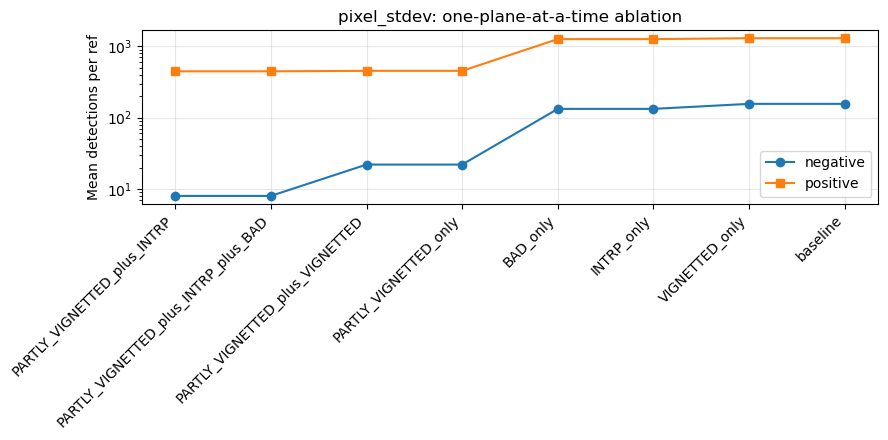

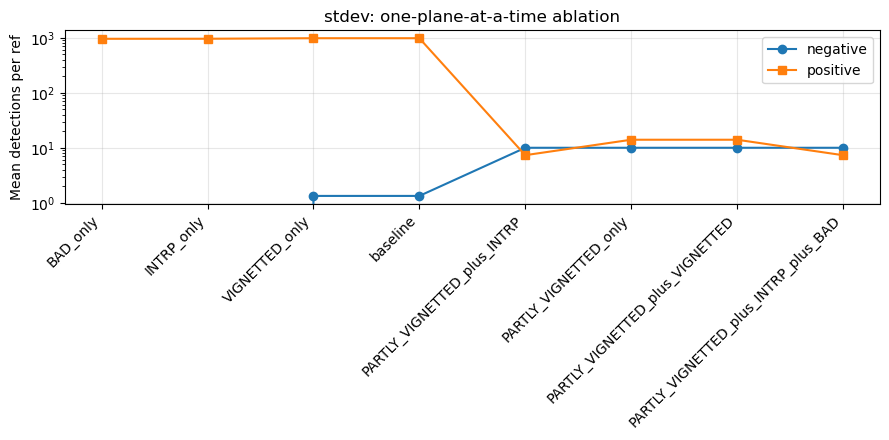


Paste me:
1) Summary
2) Comparison to baseline


In [1]:
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lsst.daf.butler import Butler
try:
    from lsst.meas.algorithms import SourceDetectionTask, SourceDetectionConfig
except Exception:
    from lsst.meas.algorithms.detection import SourceDetectionTask, SourceDetectionConfig

# =============================================================================
# Settings
# =============================================================================
REPO = "dp2_prep"
COLLECTIONS = "LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2"
WHERE = "instrument='LSSTCam' AND day_obs>=20250801 AND day_obs<=20250921 AND band in ('u','g','r','i','z','y')"

MAX_REFS = 3
THRESHOLD = 5.0
THRESHOLD_TYPES = ["pixel_stdev", "stdev"]

DO_TEMP_LOCAL_BACKGROUND = False
DO_TEMP_WIDE_BACKGROUND = False
RE_ESTIMATE_BACKGROUND = False

EXPERIMENTS = {
    "baseline": [],
    "PARTLY_VIGNETTED_only": ["PARTLY_VIGNETTED"],
    "VIGNETTED_only": ["VIGNETTED"],
    "INTRP_only": ["INTRP"],
    "BAD_only": ["BAD"],
    "PARTLY_VIGNETTED_plus_INTRP": ["PARTLY_VIGNETTED", "INTRP"],
    "PARTLY_VIGNETTED_plus_VIGNETTED": ["PARTLY_VIGNETTED", "VIGNETTED"],
    "PARTLY_VIGNETTED_plus_INTRP_plus_BAD": ["PARTLY_VIGNETTED", "INTRP", "BAD"],
}

MAKE_PLOTS = True

# =============================================================================
# Helpers
# =============================================================================
def get_ref_meta(ref, idx=None):
    d = ref.dataId
    return {
        "ref_idx": idx,
        "visit": d["visit"] if "visit" in d else None,
        "detector": d["detector"] if "detector" in d else None,
        "band": d["band"] if "band" in d else None,
        "day_obs": d["day_obs"] if "day_obs" in d else None,
    }

def available_mask_planes(exposure):
    return list(exposure.mask.getMaskPlaneDict().keys())

def keep_existing_mask_planes(exposure, requested):
    avail = set(available_mask_planes(exposure))
    return [p for p in requested if p in avail]

def make_detection_task(threshold, threshold_type, polarity="negative", exclude_mask_planes=None):
    cfg = SourceDetectionConfig()
    cfg.thresholdValue = float(threshold)
    cfg.thresholdType = str(threshold_type)
    cfg.thresholdPolarity = str(polarity)
    cfg.includeThresholdMultiplier = 1.0
    cfg.reEstimateBackground = bool(RE_ESTIMATE_BACKGROUND)
    cfg.doTempLocalBackground = bool(DO_TEMP_LOCAL_BACKGROUND)
    if hasattr(cfg, "doTempWideBackground"):
        cfg.doTempWideBackground = bool(DO_TEMP_WIDE_BACKGROUND)
    cfg.excludeMaskPlanes = list(exclude_mask_planes or [])
    return SourceDetectionTask(config=cfg)

def run_detection(exp, bg, threshold, threshold_type, polarity="negative", exclude_mask_planes=None):
    task = make_detection_task(
        threshold=threshold,
        threshold_type=threshold_type,
        polarity=polarity,
        exclude_mask_planes=exclude_mask_planes,
    )
    return task.detectFootprints(
        exposure=exp,
        doSmooth=True,
        sigma=None,
        clearMask=True,
        expId=None,
        background=bg,
    )

# =============================================================================
# Run
# =============================================================================
butler = Butler(REPO, collections=COLLECTIONS)
refs = list(
    butler.registry.queryDatasets(
        "preliminary_visit_image",
        instrument="LSSTCam",
        findFirst=True,
        where=WHERE,
    )
)[:MAX_REFS]

rows = []

print(f"Using {len(refs)} refs")
for i, ref in enumerate(refs):
    print(get_ref_meta(ref, i))

for i, ref in enumerate(refs):
    meta = get_ref_meta(ref, i)
    exp = butler.get("preliminary_visit_image", dataId=ref.dataId)
    bg = butler.get("preliminary_visit_image_background", dataId=ref.dataId)

    print(f"\n=== Ref {i}: {meta} ===")
    print("Available mask planes:", available_mask_planes(exp))

    for threshold_type in THRESHOLD_TYPES:
        for tag, requested_planes in EXPERIMENTS.items():
            exclude_planes = keep_existing_mask_planes(exp, requested_planes)

            res_neg = run_detection(
                exp, bg,
                threshold=THRESHOLD,
                threshold_type=threshold_type,
                polarity="negative",
                exclude_mask_planes=exclude_planes,
            )
            res_pos = run_detection(
                exp, bg,
                threshold=THRESHOLD,
                threshold_type=threshold_type,
                polarity="positive",
                exclude_mask_planes=exclude_planes,
            )

            rows.append({
                **meta,
                "threshold_type": threshold_type,
                "experiment": tag,
                "excluded_mask_planes": ",".join(exclude_planes),
                "negative_count": int(res_neg.numNeg),
                "positive_count": int(res_pos.numPos),
            })

            del res_neg, res_pos
            gc.collect()

    del exp, bg
    gc.collect()

df = pd.DataFrame(rows)

print("\n=== Raw results ===")
display(df)

summary = (
    df.groupby(["threshold_type", "experiment"], dropna=False)
      .agg(
          n_refs=("negative_count", "size"),
          mean_negative_count=("negative_count", "mean"),
          median_negative_count=("negative_count", "median"),
          mean_positive_count=("positive_count", "mean"),
          median_positive_count=("positive_count", "median"),
      )
      .reset_index()
)

print("\n=== Summary ===")
display(summary.sort_values(["threshold_type", "mean_negative_count"]))

baseline = (
    summary[summary["experiment"] == "baseline"]
    [["threshold_type", "mean_negative_count", "mean_positive_count"]]
    .rename(columns={
        "mean_negative_count": "baseline_negative",
        "mean_positive_count": "baseline_positive",
    })
)

comp = summary.merge(baseline, on="threshold_type", how="left")
comp["frac_negative_remaining_vs_baseline"] = comp["mean_negative_count"] / comp["baseline_negative"]
comp["frac_negative_removed_vs_baseline"] = 1.0 - comp["frac_negative_remaining_vs_baseline"]
comp["frac_positive_remaining_vs_baseline"] = comp["mean_positive_count"] / comp["baseline_positive"]

print("\n=== Comparison to baseline ===")
display(
    comp.sort_values(
        ["threshold_type", "frac_negative_remaining_vs_baseline", "mean_negative_count"],
        ascending=[True, True, True]
    )
)

if MAKE_PLOTS:
    for tt in sorted(df["threshold_type"].unique()):
        sub = comp[comp["threshold_type"] == tt].copy()
        sub = sub.sort_values("frac_negative_remaining_vs_baseline")
        plt.figure(figsize=(9, 4.5))
        plt.plot(sub["experiment"], sub["mean_negative_count"], marker="o", label="negative")
        plt.plot(sub["experiment"], sub["mean_positive_count"], marker="s", label="positive")
        plt.yscale("log")
        plt.xticks(rotation=45, ha="right")
        plt.ylabel("Mean detections per ref")
        plt.title(f"{tt}: one-plane-at-a-time ablation")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

print("\nPaste me:")
print("1) Summary")
print("2) Comparison to baseline")

In [1]:
import gc
from lsst.daf.butler import Butler
try:
    from lsst.meas.algorithms import SourceDetectionTask, SourceDetectionConfig
except Exception:
    from lsst.meas.algorithms.detection import SourceDetectionTask, SourceDetectionConfig

# =============================================================================
# Settings
# =============================================================================
REPO = "dp2_prep"
COLLECTIONS = "LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2"
WHERE = "instrument='LSSTCam' AND day_obs>=20250801 AND day_obs<=20250921 AND band in ('u','g','r','i','z','y')"

MAX_REFS = 3
THRESHOLDS = [5.0, 4.0, 3.0]

DO_TEMP_LOCAL_BACKGROUND = False
DO_TEMP_WIDE_BACKGROUND = False
RE_ESTIMATE_BACKGROUND = False

# "Best case" setups to compare:
# 1) stdev baseline
# 2) pixel_stdev baseline
# 3) pixel_stdev cleaned with the planes we found matter most
EXPERIMENTS = {
    "stdev_baseline": {
        "threshold_type": "stdev",
        "exclude_mask_planes": [],
    },
    "pixel_stdev_baseline": {
        "threshold_type": "pixel_stdev",
        "exclude_mask_planes": [],
    },
    "pixel_stdev_cleaned": {
        "threshold_type": "pixel_stdev",
        "exclude_mask_planes": ["PARTLY_VIGNETTED", "INTRP"],
    },
}

# =============================================================================
# Helpers
# =============================================================================
def get_ref_meta(ref, idx=None):
    d = ref.dataId
    return {
        "ref_idx": idx,
        "visit": d["visit"] if "visit" in d else None,
        "detector": d["detector"] if "detector" in d else None,
        "band": d["band"] if "band" in d else None,
        "day_obs": d["day_obs"] if "day_obs" in d else None,
    }

def available_mask_planes(exposure):
    return list(exposure.mask.getMaskPlaneDict().keys())

def keep_existing_mask_planes(exposure, requested):
    avail = set(available_mask_planes(exposure))
    return [p for p in requested if p in avail]

def make_detection_task(threshold, threshold_type, polarity="positive", exclude_mask_planes=None):
    cfg = SourceDetectionConfig()
    cfg.thresholdValue = float(threshold)
    cfg.thresholdType = str(threshold_type)
    cfg.thresholdPolarity = str(polarity)
    cfg.includeThresholdMultiplier = 1.0
    cfg.reEstimateBackground = bool(RE_ESTIMATE_BACKGROUND)
    cfg.doTempLocalBackground = bool(DO_TEMP_LOCAL_BACKGROUND)
    if hasattr(cfg, "doTempWideBackground"):
        cfg.doTempWideBackground = bool(DO_TEMP_WIDE_BACKGROUND)
    cfg.excludeMaskPlanes = list(exclude_mask_planes or [])
    return SourceDetectionTask(config=cfg)

def run_detection(exp, bg, threshold, threshold_type, polarity="positive", exclude_mask_planes=None):
    task = make_detection_task(
        threshold=threshold,
        threshold_type=threshold_type,
        polarity=polarity,
        exclude_mask_planes=exclude_mask_planes,
    )
    return task.detectFootprints(
        exposure=exp,
        doSmooth=True,
        sigma=None,
        clearMask=True,
        expId=None,
        background=bg,
    )

# =============================================================================
# Run
# =============================================================================
butler = Butler(REPO, collections=COLLECTIONS)
refs = list(
    butler.registry.queryDatasets(
        "preliminary_visit_image",
        instrument="LSSTCam",
        findFirst=True,
        where=WHERE,
    )
)[:MAX_REFS]

print(f"Using {len(refs)} refs")
for i, ref in enumerate(refs):
    print(get_ref_meta(ref, i))

rows = []

for i, ref in enumerate(refs):
    meta = get_ref_meta(ref, i)
    exp = butler.get("preliminary_visit_image", dataId=ref.dataId)
    bg = butler.get("preliminary_visit_image_background", dataId=ref.dataId)

    print(f"\n=== Ref {i}: {meta} ===")
    print("Available mask planes:", available_mask_planes(exp))

    for label, cfg in EXPERIMENTS.items():
        threshold_type = cfg["threshold_type"]
        exclude_planes = keep_existing_mask_planes(exp, cfg["exclude_mask_planes"])

        for thr in THRESHOLDS:
            res_pos = run_detection(
                exp, bg,
                threshold=thr,
                threshold_type=threshold_type,
                polarity="positive",
                exclude_mask_planes=exclude_planes,
            )
            res_neg = run_detection(
                exp, bg,
                threshold=thr,
                threshold_type=threshold_type,
                polarity="negative",
                exclude_mask_planes=exclude_planes,
            )

            pos_count = int(res_pos.numPos)
            neg_count = int(res_neg.numNeg)
            total_count = pos_count + neg_count

            rows.append({
                **meta,
                "experiment": label,
                "threshold_type": threshold_type,
                "threshold": thr,
                "excluded_mask_planes": ",".join(exclude_planes),
                "positive_count": pos_count,
                "negative_count": neg_count,
                "total_count": total_count,
            })

            del res_pos, res_neg
            gc.collect()

    del exp, bg
    gc.collect()

# =============================================================================
# Output: only counts
# =============================================================================
import pandas as pd
df = pd.DataFrame(rows)

print("\n=== Per-ref counts ===")
display(
    df.sort_values(["experiment", "ref_idx", "threshold"], ascending=[True, True, False])
)

summary = (
    df.groupby(["experiment", "threshold"], dropna=False)
      .agg(
          mean_positive_count=("positive_count", "mean"),
          mean_negative_count=("negative_count", "mean"),
          mean_total_count=("total_count", "mean"),
          median_positive_count=("positive_count", "median"),
          median_negative_count=("negative_count", "median"),
          median_total_count=("total_count", "median"),
      )
      .reset_index()
      .sort_values(["experiment", "threshold"], ascending=[True, False])
)

print("\n=== Mean/median counts by experiment and threshold ===")
display(summary)

print("\nCopy the mean_total_count or median_total_count columns and compute the ratios you want.")

Using 3 refs
{'ref_idx': 0, 'visit': 2025080600341, 'detector': 1, 'band': 'i', 'day_obs': 20250806}
{'ref_idx': 1, 'visit': 2025080600342, 'detector': 1, 'band': 'i', 'day_obs': 20250806}
{'ref_idx': 2, 'visit': 2025080600343, 'detector': 1, 'band': 'i', 'day_obs': 20250806}

=== Ref 0: {'ref_idx': 0, 'visit': 2025080600341, 'detector': 1, 'band': 'i', 'day_obs': 20250806} ===
Available mask planes: ['BAD', 'CR', 'CROSSTALK', 'DETECTED', 'DETECTED_NEGATIVE', 'EDGE', 'INTRP', 'ITL_DIP', 'NOT_DEBLENDED', 'NO_DATA', 'PARTLY_VIGNETTED', 'SAT', 'SPIKE', 'STREAK', 'SUSPECT', 'UNMASKEDNAN', 'VIGNETTED']



=== Ref 1: {'ref_idx': 1, 'visit': 2025080600342, 'detector': 1, 'band': 'i', 'day_obs': 20250806} ===
Available mask planes: ['BAD', 'CR', 'CROSSTALK', 'DETECTED', 'DETECTED_NEGATIVE', 'EDGE', 'INTRP', 'ITL_DIP', 'NOT_DEBLENDED', 'NO_DATA', 'PARTLY_VIGNETTED', 'SAT', 'SPIKE', 'STREAK', 'SUSPECT', 'UNMASKEDNAN', 'VIGNETTED']



=== Ref 2: {'ref_idx': 2, 'visit': 2025080600343, 'detector': 1, 'band': 'i', 'day_obs': 20250806} ===
Available mask planes: ['BAD', 'CR', 'CROSSTALK', 'DETECTED', 'DETECTED_NEGATIVE', 'EDGE', 'INTRP', 'ITL_DIP', 'NOT_DEBLENDED', 'NO_DATA', 'PARTLY_VIGNETTED', 'SAT', 'SPIKE', 'STREAK', 'SUSPECT', 'UNMASKEDNAN', 'VIGNETTED']



=== Per-ref counts ===


,ref_idx,visit,detector,band,day_obs,experiment,threshold_type,threshold,excluded_mask_planes,positive_count,negative_count,total_count
3,0,2025080600341,1,i,20250806,pixel_stdev_baseline,pixel_stdev,5.0,,1353,147,1500
4,0,2025080600341,1,i,20250806,pixel_stdev_baseline,pixel_stdev,4.0,,1890,977,2867
5,0,2025080600341,1,i,20250806,pixel_stdev_baseline,pixel_stdev,3.0,,3434,3093,6527
12,1,2025080600342,1,i,20250806,pixel_stdev_baseline,pixel_stdev,5.0,,1304,168,1472
13,1,2025080600342,1,i,20250806,pixel_stdev_baseline,pixel_stdev,4.0,,1795,938,2733
14,1,2025080600342,1,i,20250806,pixel_stdev_baseline,pixel_stdev,3.0,,2906,2490,5396
21,2,2025080600343,1,i,20250806,pixel_stdev_baseline,pixel_stdev,5.0,,1233,153,1386
22,2,2025080600343,1,i,20250806,pixel_stdev_baseline,pixel_stdev,4.0,,1759,920,2679
23,2,2025080600343,1,i,20250806,pixel_stdev_baseline,pixel_stdev,3.0,,2804,2419,5223
6,0,2025080600341,1,i,20250806,pixel_stdev_cleaned,pixel_stdev,5.0,"PARTLY_VIGNETTED,INTRP",470,10,480



=== Mean/median counts by experiment and threshold ===


,experiment,threshold,mean_positive_count,mean_negative_count,mean_total_count,median_positive_count,median_negative_count,median_total_count
2,pixel_stdev_baseline,5.0,1296.666667,156.000000,1452.666667,1304.0,153.0,1472.0
1,pixel_stdev_baseline,4.0,1814.666667,945.000000,2759.666667,1795.0,938.0,2733.0
0,pixel_stdev_baseline,3.0,3048.000000,2667.333333,5715.333333,2906.0,2490.0,5396.0
5,pixel_stdev_cleaned,5.0,445.666667,8.000000,453.666667,441.0,8.0,449.0
4,pixel_stdev_cleaned,4.0,566.000000,143.333333,709.333333,554.0,146.0,706.0
3,pixel_stdev_cleaned,3.0,1007.666667,1033.333333,2041.000000,997.0,999.0,1996.0
8,stdev_baseline,5.0,980.000000,1.333333,981.333333,963.0,2.0,965.0
7,stdev_baseline,4.0,1176.666667,38.666667,1215.333333,1172.0,44.0,1221.0
6,stdev_baseline,3.0,1749.000000,776.666667,2525.666667,1722.0,761.0,2483.0



Copy the mean_total_count or median_total_count columns and compute the ratios you want.


In [2]:
import gc
from lsst.daf.butler import Butler
try:
    from lsst.meas.algorithms import SourceDetectionTask, SourceDetectionConfig
except Exception:
    from lsst.meas.algorithms.detection import SourceDetectionTask, SourceDetectionConfig
import pandas as pd

# =============================================================================
# Settings
# =============================================================================
REPO = "dp2_prep"
COLLECTIONS = "LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2"
WHERE = "instrument='LSSTCam' AND day_obs>=20250801 AND day_obs<=20250921 AND band in ('u','g','r','i','z','y')"

MAX_REFS = 3
THRESHOLDS = [5.0, 4.0, 3.0]

DO_TEMP_LOCAL_BACKGROUND = False
DO_TEMP_WIDE_BACKGROUND = False
RE_ESTIMATE_BACKGROUND = False

EXPERIMENTS = {
    "stdev_baseline": {
        "threshold_type": "stdev",
        "exclude_mask_planes": [],
    },
    "stdev_cleaned": {
        "threshold_type": "stdev",
        #"exclude_mask_planes": ['BAD', 'EDGE', 'INTRP', 'NO_DATA', 'PARTLY_VIGNETTED', 'SAT', 'SUSPECT', 'UNMASKEDNAN', 'VIGNETTED'],
        "exclude_mask_planes": ["PARTLY_VIGNETTED", "INTRP"],
    },
    "pixel_stdev_baseline": {
        "threshold_type": "pixel_stdev",
        "exclude_mask_planes": [],
    },
    "pixel_stdev_cleaned": {
        "threshold_type": "pixel_stdev",
        #"exclude_mask_planes": ['BAD', 'EDGE', 'INTRP', 'NO_DATA', 'PARTLY_VIGNETTED', 'SAT', 'SUSPECT', 'UNMASKEDNAN', 'VIGNETTED'],
        "exclude_mask_planes": ["PARTLY_VIGNETTED", "INTRP"],
    },
}

# =============================================================================
# Helpers
# =============================================================================
def get_ref_meta(ref, idx=None):
    d = ref.dataId
    return {
        "ref_idx": idx,
        "visit": d["visit"] if "visit" in d else None,
        "detector": d["detector"] if "detector" in d else None,
        "band": d["band"] if "band" in d else None,
        "day_obs": d["day_obs"] if "day_obs" in d else None,
    }

def available_mask_planes(exposure):
    return list(exposure.mask.getMaskPlaneDict().keys())

def keep_existing_mask_planes(exposure, requested):
    avail = set(available_mask_planes(exposure))
    return [p for p in requested if p in avail]

def make_detection_task(threshold, threshold_type, polarity="positive", exclude_mask_planes=None):
    cfg = SourceDetectionConfig()
    cfg.thresholdValue = float(threshold)
    cfg.thresholdType = str(threshold_type)
    cfg.thresholdPolarity = str(polarity)
    cfg.includeThresholdMultiplier = 1.0
    cfg.reEstimateBackground = bool(RE_ESTIMATE_BACKGROUND)
    cfg.doTempLocalBackground = bool(DO_TEMP_LOCAL_BACKGROUND)
    if hasattr(cfg, "doTempWideBackground"):
        cfg.doTempWideBackground = bool(DO_TEMP_WIDE_BACKGROUND)
    cfg.excludeMaskPlanes = list(exclude_mask_planes or [])
    return SourceDetectionTask(config=cfg)

def run_detection(exp, bg, threshold, threshold_type, polarity="positive", exclude_mask_planes=None):
    task = make_detection_task(
        threshold=threshold,
        threshold_type=threshold_type,
        polarity=polarity,
        exclude_mask_planes=exclude_mask_planes,
    )
    return task.detectFootprints(
        exposure=exp,
        doSmooth=True,
        sigma=None,
        clearMask=True,
        expId=None,
        background=bg,
    )

# =============================================================================
# Run
# =============================================================================
butler = Butler(REPO, collections=COLLECTIONS)
refs = list(
    butler.registry.queryDatasets(
        "preliminary_visit_image",
        instrument="LSSTCam",
        findFirst=True,
        where=WHERE,
    )
)[:MAX_REFS]

print(f"Using {len(refs)} refs")
for i, ref in enumerate(refs):
    print(get_ref_meta(ref, i))

rows = []

for i, ref in enumerate(refs):
    meta = get_ref_meta(ref, i)
    exp = butler.get("preliminary_visit_image", dataId=ref.dataId)
    bg = butler.get("preliminary_visit_image_background", dataId=ref.dataId)

    print(f"\n=== Ref {i}: {meta} ===")
    print("Available mask planes:", available_mask_planes(exp))

    for label, cfg in EXPERIMENTS.items():
        threshold_type = cfg["threshold_type"]
        exclude_planes = keep_existing_mask_planes(exp, cfg["exclude_mask_planes"])

        for thr in THRESHOLDS:
            res_pos = run_detection(
                exp, bg,
                threshold=thr,
                threshold_type=threshold_type,
                polarity="positive",
                exclude_mask_planes=exclude_planes,
            )
            res_neg = run_detection(
                exp, bg,
                threshold=thr,
                threshold_type=threshold_type,
                polarity="negative",
                exclude_mask_planes=exclude_planes,
            )

            pos_count = int(res_pos.numPos)
            neg_count = int(res_neg.numNeg)
            total_count = pos_count + neg_count

            rows.append({
                **meta,
                "experiment": label,
                "threshold_type": threshold_type,
                "threshold": thr,
                "excluded_mask_planes": ",".join(exclude_planes),
                "positive_count": pos_count,
                "negative_count": neg_count,
                "total_count": total_count,
            })

            del res_pos, res_neg
            gc.collect()

    del exp, bg
    gc.collect()

df = pd.DataFrame(rows)

print("\n=== Per-ref counts ===")
display(
    df.sort_values(["experiment", "ref_idx", "threshold"], ascending=[True, True, False])
)

summary = (
    df.groupby(["experiment", "threshold"], dropna=False)
      .agg(
          mean_positive_count=("positive_count", "mean"),
          mean_negative_count=("negative_count", "mean"),
          mean_total_count=("total_count", "mean"),
          median_positive_count=("positive_count", "median"),
          median_negative_count=("negative_count", "median"),
          median_total_count=("total_count", "median"),
      )
      .reset_index()
      .sort_values(["experiment", "threshold"], ascending=[True, False])
)

print("\n=== Mean/median counts by experiment and threshold ===")
display(summary)

Using 3 refs
{'ref_idx': 0, 'visit': 2025080600341, 'detector': 1, 'band': 'i', 'day_obs': 20250806}
{'ref_idx': 1, 'visit': 2025080600342, 'detector': 1, 'band': 'i', 'day_obs': 20250806}
{'ref_idx': 2, 'visit': 2025080600343, 'detector': 1, 'band': 'i', 'day_obs': 20250806}

=== Ref 0: {'ref_idx': 0, 'visit': 2025080600341, 'detector': 1, 'band': 'i', 'day_obs': 20250806} ===
Available mask planes: ['BAD', 'CR', 'CROSSTALK', 'DETECTED', 'DETECTED_NEGATIVE', 'EDGE', 'INTRP', 'ITL_DIP', 'NOT_DEBLENDED', 'NO_DATA', 'PARTLY_VIGNETTED', 'SAT', 'SPIKE', 'STREAK', 'SUSPECT', 'UNMASKEDNAN', 'VIGNETTED']



=== Ref 1: {'ref_idx': 1, 'visit': 2025080600342, 'detector': 1, 'band': 'i', 'day_obs': 20250806} ===
Available mask planes: ['BAD', 'CR', 'CROSSTALK', 'DETECTED', 'DETECTED_NEGATIVE', 'EDGE', 'INTRP', 'ITL_DIP', 'NOT_DEBLENDED', 'NO_DATA', 'PARTLY_VIGNETTED', 'SAT', 'SPIKE', 'STREAK', 'SUSPECT', 'UNMASKEDNAN', 'VIGNETTED']



=== Ref 2: {'ref_idx': 2, 'visit': 2025080600343, 'detector': 1, 'band': 'i', 'day_obs': 20250806} ===
Available mask planes: ['BAD', 'CR', 'CROSSTALK', 'DETECTED', 'DETECTED_NEGATIVE', 'EDGE', 'INTRP', 'ITL_DIP', 'NOT_DEBLENDED', 'NO_DATA', 'PARTLY_VIGNETTED', 'SAT', 'SPIKE', 'STREAK', 'SUSPECT', 'UNMASKEDNAN', 'VIGNETTED']



=== Per-ref counts ===


,ref_idx,visit,detector,band,day_obs,experiment,threshold_type,threshold,excluded_mask_planes,positive_count,negative_count,total_count
6,0,2025080600341,1,i,20250806,pixel_stdev_baseline,pixel_stdev,5.0,,1353,147,1500
7,0,2025080600341,1,i,20250806,pixel_stdev_baseline,pixel_stdev,4.0,,1890,977,2867
8,0,2025080600341,1,i,20250806,pixel_stdev_baseline,pixel_stdev,3.0,,3434,3093,6527
18,1,2025080600342,1,i,20250806,pixel_stdev_baseline,pixel_stdev,5.0,,1304,168,1472
19,1,2025080600342,1,i,20250806,pixel_stdev_baseline,pixel_stdev,4.0,,1795,938,2733
20,1,2025080600342,1,i,20250806,pixel_stdev_baseline,pixel_stdev,3.0,,2906,2490,5396
30,2,2025080600343,1,i,20250806,pixel_stdev_baseline,pixel_stdev,5.0,,1233,153,1386
31,2,2025080600343,1,i,20250806,pixel_stdev_baseline,pixel_stdev,4.0,,1759,920,2679
32,2,2025080600343,1,i,20250806,pixel_stdev_baseline,pixel_stdev,3.0,,2804,2419,5223
9,0,2025080600341,1,i,20250806,pixel_stdev_cleaned,pixel_stdev,5.0,"PARTLY_VIGNETTED,INTRP",470,10,480



=== Mean/median counts by experiment and threshold ===


,experiment,threshold,mean_positive_count,mean_negative_count,mean_total_count,median_positive_count,median_negative_count,median_total_count
2,pixel_stdev_baseline,5.0,1296.666667,156.000000,1452.666667,1304.0,153.0,1472.0
1,pixel_stdev_baseline,4.0,1814.666667,945.000000,2759.666667,1795.0,938.0,2733.0
0,pixel_stdev_baseline,3.0,3048.000000,2667.333333,5715.333333,2906.0,2490.0,5396.0
5,pixel_stdev_cleaned,5.0,445.666667,8.000000,453.666667,441.0,8.0,449.0
4,pixel_stdev_cleaned,4.0,566.000000,143.333333,709.333333,554.0,146.0,706.0
3,pixel_stdev_cleaned,3.0,1007.666667,1033.333333,2041.000000,997.0,999.0,1996.0
8,stdev_baseline,5.0,980.000000,1.333333,981.333333,963.0,2.0,965.0
7,stdev_baseline,4.0,1176.666667,38.666667,1215.333333,1172.0,44.0,1221.0
6,stdev_baseline,3.0,1749.000000,776.666667,2525.666667,1722.0,761.0,2483.0
11,stdev_cleaned,5.0,7.333333,10.000000,17.333333,7.0,10.0,17.0


Using 3 refs
{'ref_idx': 0, 'visit': 2025080600341, 'detector': 1, 'band': 'i', 'day_obs': 20250806}
{'ref_idx': 1, 'visit': 2025080600342, 'detector': 1, 'band': 'i', 'day_obs': 20250806}
{'ref_idx': 2, 'visit': 2025080600343, 'detector': 1, 'band': 'i', 'day_obs': 20250806}



=== Raw counts ===


,ref_idx,visit,detector,band,day_obs,threshold_type,reEstimateBackground,threshold,positive_count,negative_count,total_count
0,0,2025080600341,1,i,20250806,pixel_stdev,False,5.0,1353,147,1500
1,0,2025080600341,1,i,20250806,pixel_stdev,False,4.0,1890,977,2867
2,0,2025080600341,1,i,20250806,pixel_stdev,False,3.0,3434,3093,6527
3,0,2025080600341,1,i,20250806,pixel_stdev,True,5.0,1353,52,1405
4,0,2025080600341,1,i,20250806,pixel_stdev,True,4.0,2053,649,2702
5,0,2025080600341,1,i,20250806,pixel_stdev,True,3.0,3717,2750,6467
6,0,2025080600341,1,i,20250806,stdev,False,5.0,1101,6,1107
7,0,2025080600341,1,i,20250806,stdev,False,4.0,1323,20,1343
8,0,2025080600341,1,i,20250806,stdev,False,3.0,2121,613,2734
9,0,2025080600341,1,i,20250806,stdev,True,5.0,1101,7,1108



=== Summary counts ===


,threshold_type,reEstimateBackground,threshold,n_refs,mean_positive_count,mean_negative_count,mean_total_count,median_positive_count,median_negative_count,median_total_count
2,pixel_stdev,False,5.0,3,1296.666667,156.000000,1452.666667,1304.0,153.0,1472.0
1,pixel_stdev,False,4.0,3,1814.666667,945.000000,2759.666667,1795.0,938.0,2733.0
0,pixel_stdev,False,3.0,3,3048.000000,2667.333333,5715.333333,2906.0,2490.0,5396.0
5,pixel_stdev,True,5.0,3,1296.666667,65.333333,1362.000000,1304.0,66.0,1382.0
4,pixel_stdev,True,4.0,3,1961.333333,631.000000,2592.333333,1933.0,640.0,2573.0
3,pixel_stdev,True,3.0,3,3289.000000,2404.666667,5693.666667,3170.0,2282.0,5452.0
8,stdev,False,5.0,3,1020.333333,7.000000,1027.333333,1004.0,7.0,1011.0
7,stdev,False,4.0,3,1236.333333,20.333333,1256.666667,1235.0,20.0,1254.0
6,stdev,False,3.0,3,1935.333333,515.666667,2451.000000,1887.0,518.0,2405.0
11,stdev,True,5.0,3,1020.333333,5.000000,1025.333333,1004.0,5.0,1009.0



=== Ratio summary ===


,threshold_type,reEstimateBackground,positive_ratio_3_over_5,negative_ratio_3_over_5,total_ratio_3_over_5,positive_ratio_4_over_5,negative_ratio_4_over_5,total_ratio_4_over_5
0,pixel_stdev,False,2.350643,17.098291,3.934374,1.399486,6.057692,1.899725
1,pixel_stdev,True,2.536504,36.806122,4.180372,1.512596,9.658163,1.903328
2,stdev,False,1.896766,73.666667,2.385788,1.211696,2.904762,1.223232
3,stdev,True,1.859523,104.333333,2.359233,1.184254,3.866667,1.197334


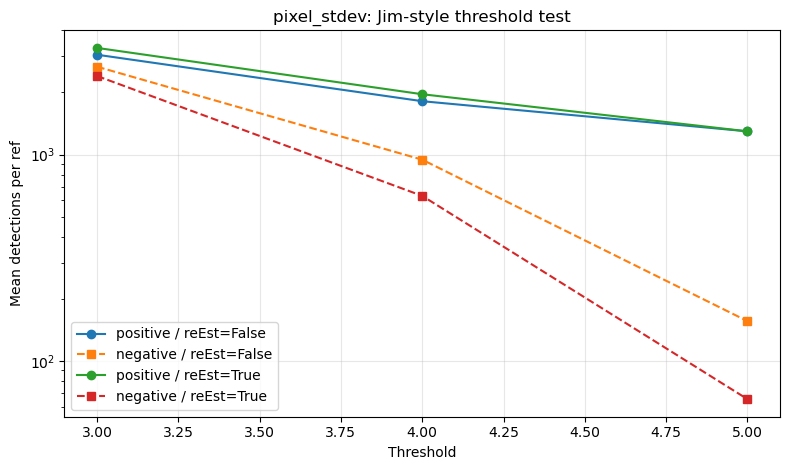

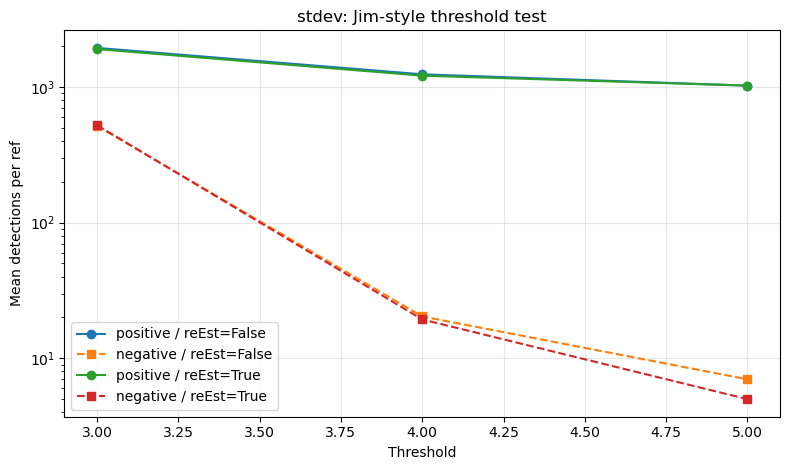


Paste me:
1) Summary counts
2) Ratio summary


In [4]:
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lsst.daf.butler import Butler
try:
    from lsst.meas.algorithms import SourceDetectionTask, SourceDetectionConfig
except Exception:
    from lsst.meas.algorithms.detection import SourceDetectionTask, SourceDetectionConfig

# =============================================================================
# Settings
# =============================================================================
REPO = "dp2_prep"
COLLECTIONS = "LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2"
WHERE = "instrument='LSSTCam' AND day_obs>=20250801 AND day_obs<=20250921 AND band in ('u','g','r','i','z','y')"

MAX_REFS = 3
THRESHOLDS = [5.0, 4.0, 3.0]
THRESHOLD_TYPES = ["pixel_stdev", "stdev"]
REESTIMATE_CHOICES = [False, True]

DO_TEMP_LOCAL_BACKGROUND = False
DO_TEMP_WIDE_BACKGROUND = False

MAKE_PLOTS = True

# =============================================================================
# Helpers
# =============================================================================
def get_ref_meta(ref, idx=None):
    d = ref.dataId
    return {
        "ref_idx": idx,
        "visit": d["visit"] if "visit" in d else None,
        "detector": d["detector"] if "detector" in d else None,
        "band": d["band"] if "band" in d else None,
        "day_obs": d["day_obs"] if "day_obs" in d else None,
    }

def make_detection_task(threshold, threshold_type, polarity="positive", reestimate_background=False):
    cfg = SourceDetectionConfig()
    cfg.thresholdValue = float(threshold)
    cfg.thresholdType = str(threshold_type)
    cfg.thresholdPolarity = str(polarity)
    cfg.includeThresholdMultiplier = 1.0
    cfg.reEstimateBackground = bool(reestimate_background)
    cfg.doTempLocalBackground = bool(DO_TEMP_LOCAL_BACKGROUND)
    if hasattr(cfg, "doTempWideBackground"):
        cfg.doTempWideBackground = bool(DO_TEMP_WIDE_BACKGROUND)
    return SourceDetectionTask(config=cfg)

def run_detection(exp, bg, threshold, threshold_type, polarity="positive", reestimate_background=False):
    task = make_detection_task(
        threshold=threshold,
        threshold_type=threshold_type,
        polarity=polarity,
        reestimate_background=reestimate_background,
    )
    return task.detectFootprints(
        exposure=exp,
        doSmooth=True,
        sigma=None,
        clearMask=True,
        expId=None,
        background=bg,
    )

# =============================================================================
# Run
# =============================================================================
butler = Butler(REPO, collections=COLLECTIONS)
refs = list(
    butler.registry.queryDatasets(
        "preliminary_visit_image",
        instrument="LSSTCam",
        findFirst=True,
        where=WHERE,
    )
)[:MAX_REFS]

rows = []

print(f"Using {len(refs)} refs")
for i, ref in enumerate(refs):
    print(get_ref_meta(ref, i))

for i, ref in enumerate(refs):
    meta = get_ref_meta(ref, i)
    exp = butler.get("preliminary_visit_image", dataId=ref.dataId)
    bg = butler.get("preliminary_visit_image_background", dataId=ref.dataId)

    for threshold_type in THRESHOLD_TYPES:
        for reest in REESTIMATE_CHOICES:
            for thr in THRESHOLDS:
                res_pos = run_detection(exp, bg, thr, threshold_type, polarity="positive", reestimate_background=reest)
                res_neg = run_detection(exp, bg, thr, threshold_type, polarity="negative", reestimate_background=reest)

                rows.append({
                    **meta,
                    "threshold_type": threshold_type,
                    "reEstimateBackground": reest,
                    "threshold": thr,
                    "positive_count": int(res_pos.numPos),
                    "negative_count": int(res_neg.numNeg),
                    "total_count": int(res_pos.numPos + res_neg.numNeg),
                })

                del res_pos, res_neg
                gc.collect()

    del exp, bg
    gc.collect()

raw_df = pd.DataFrame(rows)

print("\n=== Raw counts ===")
display(raw_df)

summary_df = (
    raw_df
    .groupby(["threshold_type", "reEstimateBackground", "threshold"], dropna=False)
    .agg(
        n_refs=("positive_count", "size"),
        mean_positive_count=("positive_count", "mean"),
        mean_negative_count=("negative_count", "mean"),
        mean_total_count=("total_count", "mean"),
        median_positive_count=("positive_count", "median"),
        median_negative_count=("negative_count", "median"),
        median_total_count=("total_count", "median"),
    )
    .reset_index()
    .sort_values(["threshold_type", "reEstimateBackground", "threshold"], ascending=[True, True, False])
)

print("\n=== Summary counts ===")
display(summary_df)

# ratio table
ratio_rows = []
for (tt, reest), sub in summary_df.groupby(["threshold_type", "reEstimateBackground"], dropna=False):
    m = {float(r["threshold"]): r for _, r in sub.iterrows()}
    if 5.0 in m and 4.0 in m and 3.0 in m:
        ratio_rows.append({
            "threshold_type": tt,
            "reEstimateBackground": reest,
            "positive_ratio_3_over_5": m[3.0]["mean_positive_count"] / m[5.0]["mean_positive_count"],
            "negative_ratio_3_over_5": m[3.0]["mean_negative_count"] / m[5.0]["mean_negative_count"] if m[5.0]["mean_negative_count"] != 0 else np.nan,
            "total_ratio_3_over_5": m[3.0]["mean_total_count"] / m[5.0]["mean_total_count"],
            "positive_ratio_4_over_5": m[4.0]["mean_positive_count"] / m[5.0]["mean_positive_count"],
            "negative_ratio_4_over_5": m[4.0]["mean_negative_count"] / m[5.0]["mean_negative_count"] if m[5.0]["mean_negative_count"] != 0 else np.nan,
            "total_ratio_4_over_5": m[4.0]["mean_total_count"] / m[5.0]["mean_total_count"],
        })

ratio_df = pd.DataFrame(ratio_rows)

print("\n=== Ratio summary ===")
display(ratio_df)

if MAKE_PLOTS:
    for tt in sorted(summary_df["threshold_type"].unique()):
        plt.figure(figsize=(8, 4.8))
        sub = summary_df[summary_df["threshold_type"] == tt].copy()
        for reest in sorted(sub["reEstimateBackground"].unique()):
            ss = sub[sub["reEstimateBackground"] == reest].sort_values("threshold")
            label_suffix = f"reEst={reest}"
            plt.plot(ss["threshold"], ss["mean_positive_count"], marker="o", label=f"positive / {label_suffix}")
            plt.plot(ss["threshold"], ss["mean_negative_count"], marker="s", linestyle="--", label=f"negative / {label_suffix}")
        plt.yscale("log")
        plt.xlabel("Threshold")
        plt.ylabel("Mean detections per ref")
        plt.title(f"{tt}: Jim-style threshold test")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

print("\nPaste me:")
print("1) Summary counts")
print("2) Ratio summary")

In [5]:
import gc
import numpy as np
import pandas as pd

from lsst.daf.butler import Butler
from lsst.drp.tasks.single_frame_detect_and_measure import (
    SingleFrameDetectAndMeasureTask,
    SingleFrameDetectAndMeasureConfig,
)

# =============================================================================
# Settings
# =============================================================================
REPO = "dp2_prep"
COLLECTIONS = "LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2"
WHERE = "instrument='LSSTCam' AND day_obs>=20250801 AND day_obs<=20250921 AND band in ('u','g','r','i','z','y')"

MAX_REFS = 1
THRESHOLDS = [5.0, 4.0, 3.0]
THRESHOLD_TYPES = ["pixel_stdev", "stdev"]
REESTIMATE_CHOICES = [False, True]

DO_TEMP_LOCAL_BACKGROUND = False
DO_TEMP_WIDE_BACKGROUND = False

# =============================================================================
# Helpers
# =============================================================================
def get_ref_meta(ref, idx=None):
    d = ref.dataId
    return {
        "ref_idx": idx,
        "visit": d["visit"] if "visit" in d else None,
        "detector": d["detector"] if "detector" in d else None,
        "band": d["band"] if "band" in d else None,
        "day_obs": d["day_obs"] if "day_obs" in d else None,
    }

def extract_source_catalog(result):
    for attr in ("sources", "outputSources", "sourceCat", "sourceCatalog"):
        if hasattr(result, attr):
            cat = getattr(result, attr)
            if cat is not None:
                return cat
    return None

def get_column_names(cat):
    if hasattr(cat, "colnames"):
        return list(cat.colnames)
    if hasattr(cat, "schema"):
        try:
            return list(cat.schema.getNames())
        except Exception:
            try:
                return [item.field.getName() for item in cat.schema]
            except Exception:
                pass
    try:
        return list(cat.keys())
    except Exception:
        return []

def safe_flag_value(rec, field_name):
    try:
        return bool(rec[field_name])
    except Exception:
        return False

def make_sfdm_task(threshold, threshold_type, reestimate_background=False, release_id=0):
    cfg = SingleFrameDetectAndMeasureConfig()

    cfg.connections.exposure = "preliminary_visit_image"
    cfg.connections.input_background = "preliminary_visit_image_background"
    cfg.connections.sources = "single_visit_star_reprocessed_unstandardized"
    cfg.connections.sources_footprints = "single_visit_star_reprocessed_footprints"
    cfg.connections.background = "preliminary_visit_image_reprocessed_background"

    cfg.id_generator.release_id = int(release_id)

    cfg.detection.thresholdValue = float(threshold)
    cfg.detection.thresholdType = str(threshold_type)
    cfg.detection.includeThresholdMultiplier = 1.0
    cfg.detection.reEstimateBackground = bool(reestimate_background)
    cfg.detection.doTempLocalBackground = bool(DO_TEMP_LOCAL_BACKGROUND)
    if hasattr(cfg.detection, "doTempWideBackground"):
        cfg.detection.doTempWideBackground = bool(DO_TEMP_WIDE_BACKGROUND)

    cfg.deblend.maxFootprintArea = -1
    return SingleFrameDetectAndMeasureTask(config=cfg)

# =============================================================================
# Run
# =============================================================================
butler = Butler(REPO, collections=COLLECTIONS)
refs = list(
    butler.registry.queryDatasets(
        "preliminary_visit_image",
        instrument="LSSTCam",
        findFirst=True,
        where=WHERE,
    )
)[:MAX_REFS]

rows = []

for i, ref in enumerate(refs):
    meta = get_ref_meta(ref, i)
    print(meta)

    exp = butler.get("preliminary_visit_image", dataId=ref.dataId)
    bg = butler.get("preliminary_visit_image_background", dataId=ref.dataId)

    for tt_i, threshold_type in enumerate(THRESHOLD_TYPES):
        for re_i, reest in enumerate(REESTIMATE_CHOICES):
            for th_i, thr in enumerate(THRESHOLDS):
                print(f"Running ref={i}, thresholdType={threshold_type}, reEstimateBackground={reest}, threshold={thr}")
                task = make_sfdm_task(
                    threshold=thr,
                    threshold_type=threshold_type,
                    reestimate_background=reest,
                    release_id=1000 + 100 * tt_i + 10 * re_i + th_i,
                )
                result = task.run(exposure=exp, input_background=bg)
                cat = extract_source_catalog(result)

                if cat is None:
                    rows.append({
                        **meta,
                        "threshold_type": threshold_type,
                        "reEstimateBackground": reest,
                        "threshold": thr,
                        "error": "No source catalog found",
                    })
                    continue

                names = get_column_names(cat)
                n_total = int(len(cat))

                sat_fields = [f for f in [
                    "base_PixelFlags_flag_saturated",
                    "base_PixelFlags_flag_saturatedCenter",
                    "base_PixelFlags_flag_saturatedCenterAll",
                ] if f in names]

                broad_fields = [f for f in [
                    "base_PixelFlags_flag_bad",
                    "base_PixelFlags_flag_edge",
                    "base_PixelFlags_flag_interpolated",
                    "base_PixelFlags_flag_interpolatedCenter",
                    "base_PixelFlags_flag_nodata",
                    "base_PixelFlags_flag_cr",
                    "base_PixelFlags_flag_saturated",
                    "base_PixelFlags_flag_saturatedCenter",
                    "base_PixelFlags_flag_suspect",
                ] if f in names]

                n_clean_sat = 0
                n_clean_broad = 0

                for rec in cat:
                    if not any(safe_flag_value(rec, f) for f in sat_fields):
                        n_clean_sat += 1
                    if not any(safe_flag_value(rec, f) for f in broad_fields):
                        n_clean_broad += 1

                rows.append({
                    **meta,
                    "threshold_type": threshold_type,
                    "reEstimateBackground": reest,
                    "threshold": thr,
                    "n_sources_total": n_total,
                    "n_sources_clean_sat": n_clean_sat,
                    "frac_sources_clean_sat": n_clean_sat / n_total if n_total else np.nan,
                    "n_sources_clean_broad": n_clean_broad,
                    "frac_sources_clean_broad": n_clean_broad / n_total if n_total else np.nan,
                })

                del task, result, cat
                gc.collect()

    del exp, bg
    gc.collect()

flag_df = pd.DataFrame(rows)

print("\n=== Measured-source cut summary ===")
display(flag_df)

ratio_rows = []
for (tt, reest), sub in flag_df.groupby(["threshold_type", "reEstimateBackground"], dropna=False):
    m = {float(r["threshold"]): r for _, r in sub.iterrows()}
    if 5.0 in m and 4.0 in m and 3.0 in m:
        ratio_rows.append({
            "threshold_type": tt,
            "reEstimateBackground": reest,
            "total_ratio_3_over_5": m[3.0]["n_sources_total"] / m[5.0]["n_sources_total"],
            "clean_sat_ratio_3_over_5": m[3.0]["n_sources_clean_sat"] / m[5.0]["n_sources_clean_sat"] if m[5.0]["n_sources_clean_sat"] != 0 else np.nan,
            "clean_broad_ratio_3_over_5": m[3.0]["n_sources_clean_broad"] / m[5.0]["n_sources_clean_broad"] if m[5.0]["n_sources_clean_broad"] != 0 else np.nan,
        })

flag_ratio_df = pd.DataFrame(ratio_rows)

print("\n=== Measured-source ratio summary ===")
display(flag_ratio_df)

print("\nPaste me:")
print("1) Measured-source cut summary")
print("2) Measured-source ratio summary")

{'ref_idx': 0, 'visit': 2025080600341, 'detector': 1, 'band': 'i', 'day_obs': 20250806}
Running ref=0, thresholdType=pixel_stdev, reEstimateBackground=False, threshold=5.0


Running ref=0, thresholdType=pixel_stdev, reEstimateBackground=False, threshold=4.0


Running ref=0, thresholdType=pixel_stdev, reEstimateBackground=False, threshold=3.0


Running ref=0, thresholdType=pixel_stdev, reEstimateBackground=True, threshold=5.0


Running ref=0, thresholdType=pixel_stdev, reEstimateBackground=True, threshold=4.0


...


=== Measured-source cut summary ===


,ref_idx,visit,detector,band,day_obs,threshold_type,reEstimateBackground,threshold,n_sources_total,n_sources_clean_sat,frac_sources_clean_sat,n_sources_clean_broad,frac_sources_clean_broad
0,0,2025080600341,1,i,20250806,pixel_stdev,False,5.0,2030,1998,0.984236,1863,0.917734
1,0,2025080600341,1,i,20250806,pixel_stdev,False,4.0,3119,3083,0.988458,2894,0.927861
2,0,2025080600341,1,i,20250806,pixel_stdev,False,3.0,7667,7627,0.994783,7256,0.946394
3,0,2025080600341,1,i,20250806,pixel_stdev,True,5.0,2030,1998,0.984236,1863,0.917734
4,0,2025080600341,1,i,20250806,pixel_stdev,True,4.0,3438,3402,0.989529,3195,0.929319
5,0,2025080600341,1,i,20250806,pixel_stdev,True,3.0,9244,9205,0.995781,8785,0.950346
6,0,2025080600341,1,i,20250806,stdev,False,5.0,1555,1525,0.980707,1414,0.909325
7,0,2025080600341,1,i,20250806,stdev,False,4.0,1972,1940,0.983773,1814,0.919878
8,0,2025080600341,1,i,20250806,stdev,False,3.0,3733,3698,0.990624,3486,0.933833
9,0,2025080600341,1,i,20250806,stdev,True,5.0,1555,1525,0.980707,1414,0.909325



=== Measured-source ratio summary ===


,threshold_type,reEstimateBackground,total_ratio_3_over_5,clean_sat_ratio_3_over_5,clean_broad_ratio_3_over_5
0,pixel_stdev,False,3.776847,3.817317,3.894793
1,pixel_stdev,True,4.553695,4.607107,4.715513
2,stdev,False,2.400643,2.424918,2.465347
3,stdev,True,2.320900,2.344262,2.389675



Paste me:
1) Measured-source cut summary
2) Measured-source ratio summary


In [15]:
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lsst.daf.butler import Butler
from lsst.drp.tasks.single_frame_detect_and_measure import SingleFrameDetectAndMeasureTask, SingleFrameDetectAndMeasureConfig


def source_detect(exposure, input_background, threshold = 5.0, release_id=0):
    cfg = SingleFrameDetectAndMeasureConfig()
    cfg.connections.exposure = "preliminary_visit_image"
    cfg.connections.input_background = "preliminary_visit_image_background"
    cfg.connections.sources = "single_visit_star_reprocessed_unstandardized"
    cfg.connections.sources_footprints = "single_visit_star_reprocessed_footprints"
    cfg.connections.background = "preliminary_visit_image_reprocessed_background"
    cfg.id_generator.release_id = release_id
    cfg.detection.thresholdValue = threshold
    cfg.detection.thresholdType = "stdev"
    cfg.detection.includeThresholdMultiplier = 1.0
    cfg.detection.reEstimateBackground = False
    cfg.detection.doTempLocalBackground = False
    task = SingleFrameDetectAndMeasureTask(config=cfg)
    result = task.run(exposure=exposure, input_background=input_background)
    return result.sources_footprints

def one_ref_object_count(butler, ref, threshold):
    calexp = butler.get("preliminary_visit_image", dataId=ref.dataId)
    background = butler.get("preliminary_visit_image_background", dataId=ref.dataId)
    src = source_detect (calexp, background, threshold)
    bad_fields = ["base_PixelFlags_flag_bad", "base_PixelFlags_flag_edge", "base_PixelFlags_flag_interpolated",
                  "base_PixelFlags_flag_interpolatedCenter", "base_PixelFlags_flag_nodata", "base_PixelFlags_flag_cr",
                  "base_PixelFlags_flag_saturated", "base_PixelFlags_flag_saturatedCenter", "base_PixelFlags_flag_suspect"]
    for field in bad_fields:
        src = src[src[field]==False]
    return src
    
repo = "dp2_prep"
collections = "LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2"
butler = Butler(repo, collections=collections)
WHERE="instrument='LSSTCam' AND day_obs>=20250801 AND day_obs<=20250921 AND band in ('u','g','r','i','z','y') "

refs = list(set(
    butler.registry.queryDatasets(
        "preliminary_visit_image",
        instrument="LSSTCam",
        findFirst=True,
        where=WHERE
    )
))


cat5 = one_ref_object_count(butler, refs[0], 5.0)
cat4 = one_ref_object_count(butler, refs[0], 4.0)
cat3 = one_ref_object_count(butler, refs[0], 3.0)

len(cat5), len(cat4), len(cat3)

(3275, 4245, 6917)

# Cleaned Experiment

In [5]:
import numpy as np
import pandas as pd
import logging
from lsst.daf.butler import Butler
from lsst.drp.tasks.single_frame_detect_and_measure import SingleFrameDetectAndMeasureTask, SingleFrameDetectAndMeasureConfig
import lsst.geom as geom

def source_detect(exposure, input_background, reEstimateBackground=True, doTempLocalBackground=True, thresholdValue = 5.0, thresholdType = "pixel_stdev", release_id=0):
    cfg = SingleFrameDetectAndMeasureConfig()
    cfg.connections.exposure = "preliminary_visit_image"
    cfg.connections.input_background = "preliminary_visit_image_background"
    cfg.connections.sources = "single_visit_star_reprocessed_unstandardized"
    cfg.connections.sources_footprints = "single_visit_star_reprocessed_footprints"
    cfg.connections.background = "preliminary_visit_image_reprocessed_background"
    cfg.id_generator.release_id = release_id
    cfg.detection.thresholdValue = thresholdValue
    cfg.detection.thresholdType = thresholdType
    cfg.detection.includeThresholdMultiplier = 1.0
    cfg.detection.reEstimateBackground = reEstimateBackground
    cfg.detection.doTempLocalBackground = doTempLocalBackground
    task = SingleFrameDetectAndMeasureTask(config=cfg)
    result = task.run(exposure=exposure, input_background=input_background)
    return result.sources_footprints

def one_ref_object_count(butler, ref, reEstimateBackground=True, doTempLocalBackground=True, thresholdValue = 5.0, thresholdType = "pixel_stdev", filter_bad_flags=False):
    calexp = butler.get("preliminary_visit_image", dataId=ref.dataId)
    background = butler.get("preliminary_visit_image_background", dataId=ref.dataId)
    src = source_detect (calexp, background, reEstimateBackground=reEstimateBackground, doTempLocalBackground=doTempLocalBackground, thresholdValue = thresholdValue, thresholdType = thresholdType)
    if filter_bad_flags:
        bad_fields = ["base_PixelFlags_flag_bad", "base_PixelFlags_flag_edge", "base_PixelFlags_flag_interpolated",
                      "base_PixelFlags_flag_interpolatedCenter", "base_PixelFlags_flag_nodata", "base_PixelFlags_flag_cr",
                      "base_PixelFlags_flag_saturated", "base_PixelFlags_flag_saturatedCenter", "base_PixelFlags_flag_suspect"]
        src = src[src["parent"]==0]
        for field in bad_fields:
            src = src[src[field]==False]
    return len(src)

def theoretical_FP_counts(calexp, nu):
    # got from https://arxiv.org/pdf/1711.10621
    sigma_g = calexp.getPsf().computeShape(geom.Point2D(float(2000), float(2000))).getDeterminantRadius()
    n_rows = calexp.image.array.shape[0]
    n_columns = calexp.image.array.shape[1]
    coeff = 1.0 / (2.0 ** 2.5 * np.pi ** 1.5)
    return n_rows * n_columns * coeff * nu * np.exp(-0.5 * nu * nu) / (sigma_g ** 2)
    


logger = logging.getLogger("lsst")
logger.setLevel(logging.ERROR)
repo = "dp2_prep"
collections = "LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2"
butler = Butler(repo, collections=collections)
WHERE="instrument='LSSTCam' AND day_obs>=20250801 AND day_obs<=20250921 AND band in ('u','g','r','i','z','y') "

refs = list(set(
    butler.registry.queryDatasets(
        "preliminary_visit_image",
        instrument="LSSTCam",
        findFirst=True,
        where=WHERE
    ))) [:2]

theory_count5 = 0
theory_count4 = 0
theory_count3 = 0

for ref in refs:
    calexp = butler.get("preliminary_visit_image", dataId=ref.dataId)
    theory_count5 += theoretical_FP_counts(calexp, 5)
    theory_count4 += theoretical_FP_counts(calexp, 4)
    theory_count3 += theoretical_FP_counts(calexp, 3)
print ("theory 5σ:",theory_count5, ", theory 4σ:", theory_count4, ", theory 3σ:", theory_count3)
rows = []
for reEstimateBackground in [True, False]:
    for doTempLocalBackground in [True, False]:
        for filter_bad_flags in [True, False]:
            for thresholdType in ["pixel_stdev", "stdev"]:
                source_count5 = 0
                source_count4 = 0
                source_count3 = 0
                for ref in refs:
                    source_count5 += one_ref_object_count(butler, ref, reEstimateBackground=reEstimateBackground, doTempLocalBackground=doTempLocalBackground, thresholdValue=5.0, thresholdType=thresholdType, filter_bad_flags=filter_bad_flags)
                    source_count4 += one_ref_object_count(butler, ref, reEstimateBackground=reEstimateBackground, doTempLocalBackground=doTempLocalBackground, thresholdValue=4.0, thresholdType=thresholdType, filter_bad_flags=filter_bad_flags)
                    source_count3 += one_ref_object_count(butler, ref, reEstimateBackground=reEstimateBackground, doTempLocalBackground=doTempLocalBackground, thresholdValue=3.0, thresholdType=thresholdType, filter_bad_flags=filter_bad_flags)
                rows.append({
                    "reEstimateBackground" : reEstimateBackground,
                    "doTempLocalBackground" : doTempLocalBackground,
                    "filter_bad_flags" : filter_bad_flags,
                    "thresholdType" : thresholdType,
                    "thresholdValue" : thresholdValue,
                    "theory 5σ" : theory_count5,
                    "theory 4σ" : theory_count4,
                    "theory 3σ" : theory_count3,
                    "measured 5σ" : source_count5,
                    "measured 4σ" : source_count4,
                    "measured 3σ" : source_count3,
                })
                print ("\rFinished", len(rows), end = "")

summary_df = pd.DataFrame(rows)
print(summary_df)

theory 5σ: 2.0622404121459272 , theory 4σ: 148.50957276270574 , theory 3σ: 3688.4712166719764
Finished 16    reEstimateBackground  doTempLocalBackground  filter_bad_flags  \
0                   True                   True              True   
1                   True                   True              True   
2                   True                   True             False   
3                   True                   True             False   
4                   True                  False              True   
5                   True                  False              True   
6                   True                  False             False   
7                   True                  False             False   
8                  False                   True              True   
9                  False                   True              True   
10                 False                   True             False   
11                 False                   True             False  

In [6]:
display(summary_df)

,reEstimateBackground,doTempLocalBackground,filter_bad_flags,thresholdType,thresholdValue,theory 5σ,theory 4σ,theory 3σ,measured 5σ,measured 4σ,measured 3σ
0,True,True,True,pixel_stdev,3.0,2.06224,148.509573,3688.471217,2890,3686,5732
1,True,True,True,stdev,3.0,2.06224,148.509573,3688.471217,2401,2845,4166
2,True,True,False,pixel_stdev,3.0,2.06224,148.509573,3688.471217,4006,5642,10053
3,True,True,False,stdev,3.0,2.06224,148.509573,3688.471217,3249,3931,6299
4,True,False,True,pixel_stdev,3.0,2.06224,148.509573,3688.471217,2889,3682,5731
5,True,False,True,stdev,3.0,2.06224,148.509573,3688.471217,2401,2844,4164
6,True,False,False,pixel_stdev,3.0,2.06224,148.509573,3688.471217,4087,5887,10644
7,True,False,False,stdev,3.0,2.06224,148.509573,3688.471217,3273,3978,6497
8,False,True,True,pixel_stdev,3.0,2.06224,148.509573,3688.471217,2890,3686,5732
9,False,True,True,stdev,3.0,2.06224,148.509573,3688.471217,2401,2845,4166
